# Khởi tạo môi trường + đọc dữ liệu

In [ ]:
# ============================================================
# CELL 1: CÀI THƯ VIỆN
# ============================================================

!pip install -q transformers datasets accelerate evaluate scikit-learn pandas openpyxl tqdm py_vncorenlp

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 28.1 MB/s eta 0:00:00


In [ ]:
# ============================================================
# CELL 2: MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# CELL 3: IMPORT + KHAI BÁO PATH
# ============================================================

import os
import re
import json
import random
import numpy as np
import pandas as pd

from collections import Counter, defaultdict
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Đổi path này nếu file của bạn nằm ở vị trí khác
DATA_PATH = "/content/drive/MyDrive/DACS/cleaned_data.xlsx"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Không tìm thấy file: {DATA_PATH}")

print("✅ Tìm thấy file dữ liệu:")
print(DATA_PATH)

✅ Tìm thấy file dữ liệu:
/content/drive/MyDrive/DACS/cleaned_data.xlsx


In [ ]:
# ============================================================
# CELL 4: ĐỌC DỮ LIỆU
# ============================================================

df = pd.read_excel(DATA_PATH)

print("✅ Load dữ liệu thành công")
print("Shape:", df.shape)
print("\nCác cột:")
print(df.columns.tolist())

display(df.head(10))

✅ Load dữ liệu thành công
Shape: (8793, 5)

Các cột:
['source_index', 'review_index', 'unit_id', 'unit_text_step2', 'FINAL_REVIEWED_SENTIMENTS']


,source_index,review_index,unit_id,unit_text_step2,FINAL_REVIEWED_SENTIMENTS
0,20244,10872,4,10đ cho sự chuyên nghiệp điểm trừ là phòng nhỏ...,HOTEL:POSITIVE; ROOMS:CONFLICT; SERVICE:POSITIVE
1,1495,861,2,"gym nhỏ, hồ_bơi đẹp nhưng không sạch",FACILITIES:CONFLICT
2,3785,2240,3,nhưng hồ_bơi không sạch lắm được view đẹp,FACILITIES:CONFLICT
3,6874,3838,1,"có bãi đỗ ô tô, tuy nhiên khu vực bãi đỗ có mù...",FACILITIES:CONFLICT
4,6881,3839,1,"có bãi đỗ ô tô, tuy nhiên khu vực bãi đỗ có mù...",FACILITIES:CONFLICT
5,11271,6192,3,có khu vực giặt và sấy đồ rất rất tiện dụng đi...,FACILITIES:CONFLICT
6,11436,6287,2,hồ_bơi view đẹp nhưng khá nhỏ,FACILITIES:CONFLICT
7,16884,9104,1,"các tiện ích, thiết bị khách sạn tốt nhưng bể_...",FACILITIES:CONFLICT
8,17811,9552,2,tiện nghi đầy đủ nhưng không tới mức 5 sao,FACILITIES:CONFLICT
9,19519,10463,1,tầng 2 và tầng trên cùng khi tổ chức sự kiện t...,FACILITIES:CONFLICT


In [ ]:
# ============================================================
# CELL 5: KIỂM TRA CỘT BẮT BUỘC
# ============================================================

REQUIRED_COLUMNS = {
    "source_index",
    "review_index",
    "unit_id",
    "unit_text_step2",
    "FINAL_REVIEWED_SENTIMENTS"
}

missing_cols = REQUIRED_COLUMNS - set(df.columns)

if missing_cols:
    raise ValueError(f"❌ Thiếu cột bắt buộc: {missing_cols}")

print("✅ Đủ toàn bộ cột bắt buộc")

✅ Đủ toàn bộ cột bắt buộc


In [ ]:
# ============================================================
# CELL 6: KIỂM TRA NULL / RỖNG
# ============================================================

check_cols = [
    "source_index",
    "review_index",
    "unit_id",
    "unit_text_step2",
    "FINAL_REVIEWED_SENTIMENTS"
]

null_report = df[check_cols].isna().sum()

print("Số giá trị null theo cột:")
display(null_report.to_frame("null_count"))

# Chuẩn hóa kiểu text để dùng an toàn ở các bước sau
df["unit_text_step2"] = df["unit_text_step2"].fillna("").astype(str).str.strip()
df["FINAL_REVIEWED_SENTIMENTS"] = df["FINAL_REVIEWED_SENTIMENTS"].fillna("").astype(str).str.strip()

empty_text_count = (df["unit_text_step2"] == "").sum()
empty_label_count = (df["FINAL_REVIEWED_SENTIMENTS"] == "").sum()

print(f"Số dòng text rỗng: {empty_text_count}")
print(f"Số dòng label rỗng: {empty_label_count}")

Số giá trị null theo cột:


,null_count
source_index,0
review_index,0
unit_id,0
unit_text_step2,0
FINAL_REVIEWED_SENTIMENTS,0


Số dòng text rỗng: 0
Số dòng label rỗng: 0


In [ ]:
# @title
# ============================================================
# CELL 6.5: LÀM SẠCH CƠ BẢN + KIỂM TRA VÀ XÓA TRÙNG LẶP
# ============================================================

print("===== BẮT ĐẦU LÀM SẠCH VÀ LỌC TRÙNG =====")

rows_before_clean = len(df)

# ------------------------------------------------------------
# 1. Chuẩn hóa nhẹ text và label
# ------------------------------------------------------------
df["unit_text_step2"] = (
    df["unit_text_step2"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

df["FINAL_REVIEWED_SENTIMENTS"] = (
    df["FINAL_REVIEWED_SENTIMENTS"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# ------------------------------------------------------------
# 2. Loại bỏ dòng text rỗng hoặc label rỗng
# ------------------------------------------------------------
empty_text_mask = df["unit_text_step2"].eq("")
empty_label_mask = df["FINAL_REVIEWED_SENTIMENTS"].eq("")

num_empty_text = int(empty_text_mask.sum())
num_empty_label = int(empty_label_mask.sum())
num_empty_any = int((empty_text_mask | empty_label_mask).sum())

print("Số dòng text rỗng:", num_empty_text)
print("Số dòng label rỗng:", num_empty_label)
print("Số dòng bị loại vì text hoặc label rỗng:", num_empty_any)

df = df[
    ~(empty_text_mask | empty_label_mask)
].copy()

# ------------------------------------------------------------
# 3. Tạo key chuẩn hóa để kiểm tra duplicate
# ------------------------------------------------------------
def normalize_text_for_dedup(text: str) -> str:
    """
    Chuẩn hóa text chỉ để kiểm tra trùng:
    - lowercase
    - co khoảng trắng
    """
    if not isinstance(text, str):
        return ""

    text = text.lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text


def normalize_label_for_dedup(label_text: str) -> str:
    """
    Chuẩn hóa chuỗi nhãn để kiểm tra trùng.
    Ví dụ:
    'ROOMS:NEGATIVE; HOTEL:POSITIVE'
    và
    'HOTEL:POSITIVE; ROOMS:NEGATIVE'
    sẽ được xem là cùng một bộ nhãn.
    """
    if not isinstance(label_text, str):
        return ""

    chunks = [
        chunk.strip().upper()
        for chunk in label_text.split(";")
        if chunk.strip()
    ]

    chunks = sorted(chunks)
    return "; ".join(chunks)


df["_dedup_text_key"] = df["unit_text_step2"].apply(
    normalize_text_for_dedup
)

df["_dedup_label_key"] = df["FINAL_REVIEWED_SENTIMENTS"].apply(
    normalize_label_for_dedup
)

# ------------------------------------------------------------
# 4. Kiểm tra các text giống nhau nhưng nhãn khác nhau
#    Không xóa tự động vì đây có thể là lỗi gán nhãn cần xem lại
# ------------------------------------------------------------
text_label_nunique = (
    df.groupby("_dedup_text_key")["_dedup_label_key"]
    .nunique()
)

conflicting_text_keys = text_label_nunique[
    text_label_nunique > 1
].index

conflicting_duplicates_df = df[
    df["_dedup_text_key"].isin(conflicting_text_keys)
].copy()

print("\nSố cụm nội dung giống nhau nhưng có nhãn khác nhau:",
      len(conflicting_text_keys))

print("Số dòng thuộc nhóm cần xem lại:",
      len(conflicting_duplicates_df))

if len(conflicting_duplicates_df) > 0:
    print("\n⚠️ Một số ví dụ text giống nhau nhưng nhãn khác nhau:")
    display(
        conflicting_duplicates_df[
            [
                "review_index",
                "unit_id",
                "unit_text_step2",
                "FINAL_REVIEWED_SENTIMENTS"
            ]
        ]
        .sort_values("unit_text_step2")
        .head(30)
    )
else:
    print("✅ Không phát hiện text trùng nhưng nhãn khác nhau.")

# ------------------------------------------------------------
# 5. Xóa duplicate hoàn toàn: cùng text chuẩn hóa + cùng nhãn chuẩn hóa
# ------------------------------------------------------------
duplicate_exact_mask = df.duplicated(
    subset=["_dedup_text_key", "_dedup_label_key"],
    keep="first"
)

num_exact_duplicates = int(duplicate_exact_mask.sum())

print("\nSố dòng trùng hoàn toàn về nội dung + nhãn:",
      num_exact_duplicates)

if num_exact_duplicates > 0:
    print("\nMột số dòng trùng hoàn toàn sẽ bị loại:")
    display(
        df.loc[
            duplicate_exact_mask,
            [
                "review_index",
                "unit_id",
                "unit_text_step2",
                "FINAL_REVIEWED_SENTIMENTS"
            ]
        ].head(30)
    )

df = df[
    ~duplicate_exact_mask
].copy()

# ------------------------------------------------------------
# 6. Xóa cột phụ và reset index
# ------------------------------------------------------------
df = df.drop(
    columns=[
        "_dedup_text_key",
        "_dedup_label_key"
    ]
).reset_index(drop=True)

rows_after_clean = len(df)
rows_removed_total = rows_before_clean - rows_after_clean

# ------------------------------------------------------------
# 7. Báo cáo tổng kết
# ------------------------------------------------------------
print("\n===== TỔNG KẾT SAU LÀM SẠCH =====")
print("Số dòng ban đầu:", rows_before_clean)
print("Số dòng sau làm sạch:", rows_after_clean)
print("Tổng số dòng đã loại:", rows_removed_total)

print("\n✅ Hoàn tất làm sạch cơ bản và lọc trùng lặp.")

===== BẮT ĐẦU LÀM SẠCH VÀ LỌC TRÙNG =====
Số dòng text rỗng: 0
Số dòng label rỗng: 0
Số dòng bị loại vì text hoặc label rỗng: 0

Số cụm nội dung giống nhau nhưng có nhãn khác nhau: 0
Số dòng thuộc nhóm cần xem lại: 0
✅ Không phát hiện text trùng nhưng nhãn khác nhau.

Số dòng trùng hoàn toàn về nội dung + nhãn: 1198

Một số dòng trùng hoàn toàn sẽ bị loại:


,review_index,unit_id,unit_text_step2,FINAL_REVIEWED_SENTIMENTS
4,3839,1,"có bãi đỗ ô tô, tuy nhiên khu vực bãi đỗ có mù...",FACILITIES:CONFLICT
131,14929,1,wifi yếu,FACILITIES:NEGATIVE
245,438,1,hồ_bơi đẹp,FACILITIES:POSITIVE
248,553,1,hồ_bơi đẹp,FACILITIES:POSITIVE
250,1988,3,hồ_bơi đẹp,FACILITIES:POSITIVE
251,2010,5,hồ_bơi đẹp,FACILITIES:POSITIVE
258,2673,3,hồ_bơi đẹp,FACILITIES:POSITIVE
292,14162,2,có chỗ để xe máy miễn phí,FACILITIES:POSITIVE
295,14689,3,wifi mạnh,FACILITIES:POSITIVE
371,500,2,"hồ_bơi vô cực city view xịn xò, là khách sạn t...",FACILITIES:POSITIVE; SERVICE:POSITIVE



===== TỔNG KẾT SAU LÀM SẠCH =====
Số dòng ban đầu: 8793
Số dòng sau làm sạch: 7595
Tổng số dòng đã loại: 1198

✅ Hoàn tất làm sạch cơ bản và lọc trùng lặp.


In [ ]:
# ============================================================
# CELL 7: XEM RANDOM MỘT SỐ MẪU
# ============================================================

sample_df = df[
    ["review_index", "unit_id", "unit_text_step2", "FINAL_REVIEWED_SENTIMENTS"]
].sample(10, random_state=SEED)

display(sample_df)

,review_index,unit_id,unit_text_step2,FINAL_REVIEWED_SENTIMENTS
1261,9407,7,cùng ở quận 1 nhưng đây là khách sạn tệ nhất đã ở,HOTEL:NEGATIVE
7416,7007,3,một pha giao đồ bữa_sáng khá cồng kềnh,SERVICE:NEGATIVE
5985,15084,1,oke với tầm_giá,HOTEL:POSITIVE
3047,5306,1,khách sạn đẹp ok,HOTEL:POSITIVE
586,5670,1,khách sạn chỉ cần nâng cấp thêm chất lượng bữa...,FOOD&DRINKS:NEUTRAL
2173,823,1,hotel sạch sẽ và dịch vụ tốt,HOTEL:POSITIVE
2543,2875,2,tôi sẽ quay lại lần sau,HOTEL:POSITIVE
2020,88,1,muốn ở thêm again,HOTEL:POSITIVE
2697,3618,4,giá cả hợp lí,HOTEL:POSITIVE
408,15617,1,sáng không nhiều món nhưng rất ngon,FOOD&DRINKS:CONFLICT


# Kiểm tra nhãn và chuẩn hóa nhãn

In [ ]:
# ============================================================
# CELL 8: KHAI BÁO ASPECT + LABEL SCHEMA
# ============================================================

ASPECTS = [
    "HOTEL",
    "LOCATION",
    "ROOMS",
    "FACILITIES",
    "FOOD&DRINKS",
    "SERVICE"
]

LABELS = [
    "NONE",
    "POSITIVE",
    "NEGATIVE",
    "NEUTRAL",
    "CONFLICT"
]

LABEL2ID = {
    "NONE": 0,
    "POSITIVE": 1,
    "NEGATIVE": 2,
    "NEUTRAL": 3,
    "CONFLICT": 4
}

ID2LABEL = {v: k for k, v in LABEL2ID.items()}

print("ASPECTS:", ASPECTS)
print("LABEL2ID:", LABEL2ID)

ASPECTS: ['HOTEL', 'LOCATION', 'ROOMS', 'FACILITIES', 'FOOD&DRINKS', 'SERVICE']
LABEL2ID: {'NONE': 0, 'POSITIVE': 1, 'NEGATIVE': 2, 'NEUTRAL': 3, 'CONFLICT': 4}


In [ ]:
# ============================================================
# CELL 9: HÀM PARSE NHÃN
# ============================================================

def parse_label_string(label_text: str) -> dict:
    """
    Chuyển chuỗi nhãn:
        'HOTEL:POSITIVE; ROOMS:CONFLICT'
    thành dict đầy đủ 6 aspect:
        {
            'HOTEL': 'POSITIVE',
            'LOCATION': 'NONE',
            ...
        }
    """

    # Khởi tạo mặc định: mọi aspect đều NONE
    result = {aspect: "NONE" for aspect in ASPECTS}

    if not isinstance(label_text, str) or not label_text.strip():
        return result

    # Tách từng cặp aspect:sentiment
    chunks = [x.strip() for x in label_text.split(";") if x.strip()]

    for chunk in chunks:
        if ":" not in chunk:
            raise ValueError(f"Thiếu dấu ':' trong nhãn: {chunk}")

        aspect, sentiment = chunk.split(":", 1)

        aspect = aspect.strip().upper()
        sentiment = sentiment.strip().upper()

        if aspect not in ASPECTS:
            raise ValueError(f"Aspect không hợp lệ: {aspect}")

        if sentiment not in LABELS[1:]:
            raise ValueError(f"Sentiment không hợp lệ: {sentiment}")

        result[aspect] = sentiment

    return result

In [ ]:
# ============================================================
# CELL 10: TEST HÀM PARSE
# ============================================================

test_labels = [
    "HOTEL:POSITIVE",
    "ROOMS:CONFLICT; SERVICE:NEGATIVE",
    "LOCATION:POSITIVE; FOOD&DRINKS:NEUTRAL",
]

for x in test_labels:
    print("=" * 80)
    print("Input:", x)
    print("Parsed:", parse_label_string(x))

Input: HOTEL:POSITIVE
Parsed: {'HOTEL': 'POSITIVE', 'LOCATION': 'NONE', 'ROOMS': 'NONE', 'FACILITIES': 'NONE', 'FOOD&DRINKS': 'NONE', 'SERVICE': 'NONE'}
Input: ROOMS:CONFLICT; SERVICE:NEGATIVE
Parsed: {'HOTEL': 'NONE', 'LOCATION': 'NONE', 'ROOMS': 'CONFLICT', 'FACILITIES': 'NONE', 'FOOD&DRINKS': 'NONE', 'SERVICE': 'NEGATIVE'}
Input: LOCATION:POSITIVE; FOOD&DRINKS:NEUTRAL
Parsed: {'HOTEL': 'NONE', 'LOCATION': 'POSITIVE', 'ROOMS': 'NONE', 'FACILITIES': 'NONE', 'FOOD&DRINKS': 'NEUTRAL', 'SERVICE': 'NONE'}


In [ ]:
# ============================================================
# CELL 11: KIỂM TRA NHÃN TOÀN BỘ DATASET
# ============================================================

label_errors = []

for idx, row in df.iterrows():
    label_text = row["FINAL_REVIEWED_SENTIMENTS"]

    try:
        _ = parse_label_string(label_text)
    except Exception as e:
        label_errors.append({
            "row_index": idx,
            "review_index": row["review_index"],
            "unit_id": row["unit_id"],
            "unit_text_step2": row["unit_text_step2"],
            "label_text": label_text,
            "error": str(e)
        })

print("Số dòng lỗi nhãn:", len(label_errors))

if label_errors:
    error_df = pd.DataFrame(label_errors)
    display(error_df.head(20))
else:
    print("✅ Không phát hiện lỗi format nhãn.")

Số dòng lỗi nhãn: 0
✅ Không phát hiện lỗi format nhãn.


In [ ]:
# ============================================================
# CELL 12: TẠO 6 CỘT LABEL DẠNG TEXT
# ============================================================

parsed_labels = df["FINAL_REVIEWED_SENTIMENTS"].apply(parse_label_string)

parsed_label_df = pd.DataFrame(parsed_labels.tolist())

# Đảm bảo đúng thứ tự aspect
parsed_label_df = parsed_label_df[ASPECTS]

# Ghép vào dataframe gốc
df_labeled = pd.concat(
    [df.reset_index(drop=True), parsed_label_df.reset_index(drop=True)],
    axis=1
)

print("✅ Đã tạo 6 cột nhãn aspect")
display(
    df_labeled[
        [
            "unit_text_step2",
            "FINAL_REVIEWED_SENTIMENTS",
            "HOTEL",
            "LOCATION",
            "ROOMS",
            "FACILITIES",
            "FOOD&DRINKS",
            "SERVICE",
        ]
    ].head(10)
)

✅ Đã tạo 6 cột nhãn aspect


,unit_text_step2,FINAL_REVIEWED_SENTIMENTS,HOTEL,LOCATION,ROOMS,FACILITIES,FOOD&DRINKS,SERVICE
0,10đ cho sự chuyên nghiệp điểm trừ là phòng nhỏ...,HOTEL:POSITIVE; ROOMS:CONFLICT; SERVICE:POSITIVE,POSITIVE,NONE,CONFLICT,NONE,NONE,POSITIVE
1,"gym nhỏ, hồ_bơi đẹp nhưng không sạch",FACILITIES:CONFLICT,NONE,NONE,NONE,CONFLICT,NONE,NONE
2,nhưng hồ_bơi không sạch lắm được view đẹp,FACILITIES:CONFLICT,NONE,NONE,NONE,CONFLICT,NONE,NONE
3,"có bãi đỗ ô tô, tuy nhiên khu vực bãi đỗ có mù...",FACILITIES:CONFLICT,NONE,NONE,NONE,CONFLICT,NONE,NONE
4,có khu vực giặt và sấy đồ rất rất tiện dụng đi...,FACILITIES:CONFLICT,NONE,NONE,NONE,CONFLICT,NONE,NONE
5,hồ_bơi view đẹp nhưng khá nhỏ,FACILITIES:CONFLICT,NONE,NONE,NONE,CONFLICT,NONE,NONE
6,"các tiện ích, thiết bị khách sạn tốt nhưng bể_...",FACILITIES:CONFLICT,NONE,NONE,NONE,CONFLICT,NONE,NONE
7,tiện nghi đầy đủ nhưng không tới mức 5 sao,FACILITIES:CONFLICT,NONE,NONE,NONE,CONFLICT,NONE,NONE
8,tầng 2 và tầng trên cùng khi tổ chức sự kiện t...,FACILITIES:CONFLICT,NONE,NONE,NONE,CONFLICT,NONE,NONE
9,tiện nghi đầy đủ nhưng hơi cũ,FACILITIES:CONFLICT,NONE,NONE,NONE,CONFLICT,NONE,NONE


In [ ]:
# ============================================================
# CELL 13: MÃ HÓA LABEL THÀNH SỐ
# ============================================================

for aspect in ASPECTS:
    df_labeled[f"{aspect}_id"] = df_labeled[aspect].map(LABEL2ID)

# Kiểm tra xem có bị NaN không
id_cols = [f"{aspect}_id" for aspect in ASPECTS]
missing_encoded = df_labeled[id_cols].isna().sum().sum()

print("Tổng số ô encode bị thiếu:", missing_encoded)

if missing_encoded == 0:
    print("✅ Encode label thành công.")
else:
    print("❌ Có lỗi khi encode label.")

display(
    df_labeled[
        [
            "unit_text_step2",
            "HOTEL_id",
            "LOCATION_id",
            "ROOMS_id",
            "FACILITIES_id",
            "FOOD&DRINKS_id",
            "SERVICE_id",
        ]
    ].head(10)
)

Tổng số ô encode bị thiếu: 0
✅ Encode label thành công.


,unit_text_step2,HOTEL_id,LOCATION_id,ROOMS_id,FACILITIES_id,FOOD&DRINKS_id,SERVICE_id
0,10đ cho sự chuyên nghiệp điểm trừ là phòng nhỏ...,1,0,4,0,0,1
1,"gym nhỏ, hồ_bơi đẹp nhưng không sạch",0,0,0,4,0,0
2,nhưng hồ_bơi không sạch lắm được view đẹp,0,0,0,4,0,0
3,"có bãi đỗ ô tô, tuy nhiên khu vực bãi đỗ có mù...",0,0,0,4,0,0
4,có khu vực giặt và sấy đồ rất rất tiện dụng đi...,0,0,0,4,0,0
5,hồ_bơi view đẹp nhưng khá nhỏ,0,0,0,4,0,0
6,"các tiện ích, thiết bị khách sạn tốt nhưng bể_...",0,0,0,4,0,0
7,tiện nghi đầy đủ nhưng không tới mức 5 sao,0,0,0,4,0,0
8,tầng 2 và tầng trên cùng khi tổ chức sự kiện t...,0,0,0,4,0,0
9,tiện nghi đầy đủ nhưng hơi cũ,0,0,0,4,0,0


In [ ]:
# ============================================================
# CELL 14: ĐẾM SỐ ASPECT XUẤT HIỆN TRÊN MỖI UNIT
# ============================================================

df_labeled["num_active_aspects"] = (
    df_labeled[ASPECTS] != "NONE"
).sum(axis=1)

aspect_count_distribution = (
    df_labeled["num_active_aspects"]
    .value_counts()
    .sort_index()
)

print("Phân bố số aspect được gán trên mỗi unit:")
display(aspect_count_distribution.to_frame("num_units"))

Phân bố số aspect được gán trên mỗi unit:


,num_units
num_active_aspects,
1,6411
2,777
3,282
4,99
5,25
6,1


In [ ]:
# ============================================================
# CELL 15: PHÂN BỐ SENTIMENT TỔNG THỂ
# ============================================================

sentiment_counter = Counter()

for aspect in ASPECTS:
    sentiment_counter.update(
        df_labeled.loc[df_labeled[aspect] != "NONE", aspect].tolist()
    )

sentiment_distribution_df = pd.DataFrame(
    sentiment_counter.items(),
    columns=["sentiment", "count"]
).sort_values("count", ascending=False)

display(sentiment_distribution_df)

,sentiment,count
0,POSITIVE,5233
1,NEGATIVE,2913
2,CONFLICT,637
3,NEUTRAL,555


In [ ]:
# ============================================================
# CELL 16: PHÂN BỐ SENTIMENT THEO TỪNG ASPECT
# ============================================================

aspect_sentiment_rows = []

for aspect in ASPECTS:
    counts = df_labeled[aspect].value_counts()

    row = {"aspect": aspect}
    for label in LABELS:
        row[label] = int(counts.get(label, 0))

    aspect_sentiment_rows.append(row)

aspect_sentiment_df = pd.DataFrame(aspect_sentiment_rows)

display(aspect_sentiment_df)

,aspect,NONE,POSITIVE,NEGATIVE,NEUTRAL,CONFLICT
0,HOTEL,2780,3326,1157,223,109
1,LOCATION,6994,500,68,10,23
2,ROOMS,6062,360,697,107,369
3,FACILITIES,7033,197,277,63,25
4,FOOD&DRINKS,7008,221,215,77,74
5,SERVICE,6355,629,499,75,37


In [ ]:
# ============================================================
# CELL 17: RANDOM CHECK SAU PARSE
# ============================================================

cols_to_show = [
    "unit_text_step2",
    "FINAL_REVIEWED_SENTIMENTS",
    "HOTEL",
    "LOCATION",
    "ROOMS",
    "FACILITIES",
    "FOOD&DRINKS",
    "SERVICE"
]

display(
    df_labeled[cols_to_show]
    .sample(10, random_state=SEED)
)

,unit_text_step2,FINAL_REVIEWED_SENTIMENTS,HOTEL,LOCATION,ROOMS,FACILITIES,FOOD&DRINKS,SERVICE
1261,cùng ở quận 1 nhưng đây là khách sạn tệ nhất đã ở,HOTEL:NEGATIVE,NEGATIVE,NONE,NONE,NONE,NONE,NONE
7416,một pha giao đồ bữa_sáng khá cồng kềnh,SERVICE:NEGATIVE,NONE,NONE,NONE,NONE,NONE,NEGATIVE
5985,oke với tầm_giá,HOTEL:POSITIVE,POSITIVE,NONE,NONE,NONE,NONE,NONE
3047,khách sạn đẹp ok,HOTEL:POSITIVE,POSITIVE,NONE,NONE,NONE,NONE,NONE
586,khách sạn chỉ cần nâng cấp thêm chất lượng bữa...,FOOD&DRINKS:NEUTRAL,NONE,NONE,NONE,NONE,NEUTRAL,NONE
2173,hotel sạch sẽ và dịch vụ tốt,HOTEL:POSITIVE,POSITIVE,NONE,NONE,NONE,NONE,NONE
2543,tôi sẽ quay lại lần sau,HOTEL:POSITIVE,POSITIVE,NONE,NONE,NONE,NONE,NONE
2020,muốn ở thêm again,HOTEL:POSITIVE,POSITIVE,NONE,NONE,NONE,NONE,NONE
2697,giá cả hợp lí,HOTEL:POSITIVE,POSITIVE,NONE,NONE,NONE,NONE,NONE
408,sáng không nhiều món nhưng rất ngon,FOOD&DRINKS:CONFLICT,NONE,NONE,NONE,NONE,CONFLICT,NONE


In [ ]:
# ============================================================
# CELL 18: LƯU CHECKPOINT SAU TÁC VỤ 2
# ============================================================

OUTPUT_LABEL_READY_PATH = "/content/drive/MyDrive/DACS/absa_label_ready.csv"

df_labeled.to_csv(
    OUTPUT_LABEL_READY_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("✅ Đã lưu file:")
print(OUTPUT_LABEL_READY_PATH)

print("Shape cuối:", df_labeled.shape)

✅ Đã lưu file:
/content/drive/MyDrive/DACS/absa_label_ready.csv
Shape cuối: (7595, 18)


# Chuẩn bị dữ liệu cho training

In [ ]:
# ============================================================
# CELL 19: TÌM WORDSEGMENT THỦ CÔNG + BỎ "_" TRƯỚC KHI CHẠY VNCORE
# ============================================================

import re
import pandas as pd
from collections import Counter

# 1. Tìm toàn bộ token có dấu "_"
def extract_manual_segments(text: str):
    if not isinstance(text, str):
        return []
    return re.findall(r"\b[\wÀ-ỹ]+(?:_[\wÀ-ỹ]+)+\b", text.lower())

manual_segment_counter = Counter()

for text in df_labeled["unit_text_step2"].fillna("").astype(str):
    manual_segment_counter.update(extract_manual_segments(text))

# Danh sách wordsegment đã được "tự tay" thực hiện trong dữ liệu
MANUAL_SEGMENTS = sorted(
    manual_segment_counter.keys(),
    key=len,
    reverse=True
)

manual_segment_df = pd.DataFrame(
    manual_segment_counter.items(),
    columns=["manual_segment", "count"]
).sort_values("count", ascending=False).reset_index(drop=True)

print("Số wordsegment thủ công khác nhau:", len(MANUAL_SEGMENTS))
display(manual_segment_df.head(100))

# 2. Bỏ toàn bộ "_" trước khi đưa vào VnCore
df_labeled["text_before_vncore"] = (
    df_labeled["unit_text_step2"]
    .fillna("")
    .astype(str)
    .str.replace("_", " ", regex=False)
)

display(
    df_labeled[
        ["unit_text_step2", "text_before_vncore"]
    ].head(20)
)

Số wordsegment thủ công khác nhau: 25


,manual_segment,count
0,bữa_sáng,477
1,giá_tiền,180
2,hồ_bơi,71
3,phòng_tắm,59
4,chỗ_ở,44
5,điều_hòa,41
6,máy_lạnh,38
7,tầm_giá,37
8,bể_bơi,32
9,nhà_vệ_sinh,31


,unit_text_step2,text_before_vncore
0,10đ cho sự chuyên nghiệp điểm trừ là phòng nhỏ...,10đ cho sự chuyên nghiệp điểm trừ là phòng nhỏ...
1,"gym nhỏ, hồ_bơi đẹp nhưng không sạch","gym nhỏ, hồ bơi đẹp nhưng không sạch"
2,nhưng hồ_bơi không sạch lắm được view đẹp,nhưng hồ bơi không sạch lắm được view đẹp
3,"có bãi đỗ ô tô, tuy nhiên khu vực bãi đỗ có mù...","có bãi đỗ ô tô, tuy nhiên khu vực bãi đỗ có mù..."
4,có khu vực giặt và sấy đồ rất rất tiện dụng đi...,có khu vực giặt và sấy đồ rất rất tiện dụng đi...
5,hồ_bơi view đẹp nhưng khá nhỏ,hồ bơi view đẹp nhưng khá nhỏ
6,"các tiện ích, thiết bị khách sạn tốt nhưng bể_...","các tiện ích, thiết bị khách sạn tốt nhưng bể ..."
7,tiện nghi đầy đủ nhưng không tới mức 5 sao,tiện nghi đầy đủ nhưng không tới mức 5 sao
8,tầng 2 và tầng trên cùng khi tổ chức sự kiện t...,tầng 2 và tầng trên cùng khi tổ chức sự kiện t...
9,tiện nghi đầy đủ nhưng hơi cũ,tiện nghi đầy đủ nhưng hơi cũ


In [ ]:
# ============================================================
# CELL 20: LOAD VNCORENLP TỪ GOOGLE DRIVE
# ============================================================

!pip install -q py_vncorenlp

import os
import py_vncorenlp

# Chỉnh lại nếu thư mục của bạn khác
VNCORE_DIR = "/content/drive/MyDrive/DACS/My_NLP_Models/vncorenlp"

if not os.path.exists(VNCORE_DIR):
    raise FileNotFoundError(f"Không tìm thấy thư mục VnCoreNLP: {VNCORE_DIR}")

vncore_segmenter = py_vncorenlp.VnCoreNLP(
    annotators=["wseg"],
    save_dir=VNCORE_DIR
)

print("✅ Load VnCoreNLP thành công")
print(VNCORE_DIR)

✅ Load VnCoreNLP thành công
/content/drive/MyDrive/DACS/My_NLP_Models/vncorenlp


In [ ]:
# ============================================================
# CELL 21: CHẠY VNCORE WORD SEGMENTATION CHO TOÀN BỘ DỮ LIỆU
# ============================================================

from tqdm.auto import tqdm
tqdm.pandas()

def vncore_word_segment(text: str) -> str:
    if not isinstance(text, str):
        return ""

    text = text.strip()
    if not text:
        return ""

    try:
        output = vncore_segmenter.word_segment(text)

        if isinstance(output, list):
            return " ".join(
                sent.strip()
                for sent in output
                if isinstance(sent, str) and sent.strip()
            )

        if isinstance(output, str):
            return output.strip()

        return text

    except Exception as e:
        print(f"⚠️ Lỗi VnCore: {text[:100]} | {e}")
        return text

df_labeled["text_after_vncore"] = (
    df_labeled["text_before_vncore"]
    .progress_apply(vncore_word_segment)
)

print("✅ Hoàn tất chạy VnCoreNLP")

display(
    df_labeled[
        ["text_before_vncore", "text_after_vncore"]
    ].head(20)
)

  0%|          | 0/7595 [00:00<?, ?it/s]

✅ Hoàn tất chạy VnCoreNLP


,text_before_vncore,text_after_vncore
0,10đ cho sự chuyên nghiệp điểm trừ là phòng nhỏ...,10đ cho sự chuyên_nghiệp điểm trừ là phòng nhỏ...
1,"gym nhỏ, hồ bơi đẹp nhưng không sạch","gym nhỏ , hồ bơi đẹp nhưng không sạch"
2,nhưng hồ bơi không sạch lắm được view đẹp,nhưng hồ bơi không sạch lắm được view đẹp
3,"có bãi đỗ ô tô, tuy nhiên khu vực bãi đỗ có mù...","có bãi đỗ ô_tô , tuy_nhiên khu_vực bãi đỗ có m..."
4,có khu vực giặt và sấy đồ rất rất tiện dụng đi...,có khu_vực giặt và sấy đồ rất rất tiện_dụng đi...
5,hồ bơi view đẹp nhưng khá nhỏ,hồ bơi view đẹp nhưng khá nhỏ
6,"các tiện ích, thiết bị khách sạn tốt nhưng bể ...","các tiện_ích , thiết_bị khách_sạn tốt nhưng bể..."
7,tiện nghi đầy đủ nhưng không tới mức 5 sao,tiện_nghi đầy_đủ nhưng không tới mức 5 sao
8,tầng 2 và tầng trên cùng khi tổ chức sự kiện t...,tầng 2 và tầng trên cùng khi tổ_chức sự_kiện t...
9,tiện nghi đầy đủ nhưng hơi cũ,tiện_nghi đầy_đủ nhưng hơi cũ


In [ ]:
# ============================================================
# CELL 22: GÁN LẠI CÁC WORDSEGMENT THỦ CÔNG SAU VNCORE
# ============================================================

def reapply_manual_segments(text: str) -> str:
    if not isinstance(text, str):
        return ""

    result = text

    for segmented_token in MANUAL_SEGMENTS:
        plain_phrase = segmented_token.replace("_", " ")

        # Match cụm có khoảng trắng linh hoạt
        parts = [re.escape(part) for part in plain_phrase.split()]
        pattern = r"\b" + r"\s+".join(parts) + r"\b"

        result = re.sub(
            pattern,
            segmented_token,
            result,
            flags=re.IGNORECASE
        )

    result = re.sub(r"\s+", " ", result).strip()
    return result

df_labeled["text_model_input"] = (
    df_labeled["text_after_vncore"]
    .progress_apply(reapply_manual_segments)
)

print("✅ Đã gán lại các wordsegment thủ công")
display(
    df_labeled[
        [
            "unit_text_step2",
            "text_after_vncore",
            "text_model_input"
        ]
    ].head(30)
)

  0%|          | 0/7595 [00:00<?, ?it/s]

✅ Đã gán lại các wordsegment thủ công


,unit_text_step2,text_after_vncore,text_model_input
0,10đ cho sự chuyên nghiệp điểm trừ là phòng nhỏ...,10đ cho sự chuyên_nghiệp điểm trừ là phòng nhỏ...,10đ cho sự chuyên_nghiệp điểm trừ là phòng nhỏ...
1,"gym nhỏ, hồ_bơi đẹp nhưng không sạch","gym nhỏ , hồ bơi đẹp nhưng không sạch","gym nhỏ , hồ_bơi đẹp nhưng không sạch"
2,nhưng hồ_bơi không sạch lắm được view đẹp,nhưng hồ bơi không sạch lắm được view đẹp,nhưng hồ_bơi không sạch lắm được view đẹp
3,"có bãi đỗ ô tô, tuy nhiên khu vực bãi đỗ có mù...","có bãi đỗ ô_tô , tuy_nhiên khu_vực bãi đỗ có m...","có bãi đỗ ô_tô , tuy_nhiên khu_vực bãi đỗ có m..."
4,có khu vực giặt và sấy đồ rất rất tiện dụng đi...,có khu_vực giặt và sấy đồ rất rất tiện_dụng đi...,có khu_vực giặt và sấy đồ rất rất tiện_dụng đi...
5,hồ_bơi view đẹp nhưng khá nhỏ,hồ bơi view đẹp nhưng khá nhỏ,hồ_bơi view đẹp nhưng khá nhỏ
6,"các tiện ích, thiết bị khách sạn tốt nhưng bể_...","các tiện_ích , thiết_bị khách_sạn tốt nhưng bể...","các tiện_ích , thiết_bị khách_sạn tốt nhưng bể..."
7,tiện nghi đầy đủ nhưng không tới mức 5 sao,tiện_nghi đầy_đủ nhưng không tới mức 5 sao,tiện_nghi đầy_đủ nhưng không tới mức 5 sao
8,tầng 2 và tầng trên cùng khi tổ chức sự kiện t...,tầng 2 và tầng trên cùng khi tổ_chức sự_kiện t...,tầng 2 và tầng trên cùng khi tổ_chức sự_kiện t...
9,tiện nghi đầy đủ nhưng hơi cũ,tiện_nghi đầy_đủ nhưng hơi cũ,tiện_nghi đầy_đủ nhưng hơi cũ


In [ ]:
# ============================================================
# CELL 23: LƯU CHECKPOINT SAU WORD SEGMENTATION
# ============================================================

SEGMENTED_READY_PATH = "/content/drive/MyDrive/DACS/absa_segmented_ready.csv"

df_labeled.to_csv(
    SEGMENTED_READY_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("✅ Đã lưu checkpoint:")
print(SEGMENTED_READY_PATH)

print("Shape:", df_labeled.shape)

display(
    df_labeled[
        [
            "unit_text_step2",
            "text_model_input",
            "FINAL_REVIEWED_SENTIMENTS"
        ]
    ].sample(10, random_state=42)
)

✅ Đã lưu checkpoint:
/content/drive/MyDrive/DACS/absa_segmented_ready.csv
Shape: (7595, 21)


,unit_text_step2,text_model_input,FINAL_REVIEWED_SENTIMENTS
1261,cùng ở quận 1 nhưng đây là khách sạn tệ nhất đã ở,cùng ở quận 1 nhưng đây là khách_sạn tệ nhất đã ở,HOTEL:NEGATIVE
7416,một pha giao đồ bữa_sáng khá cồng kềnh,một pha giao đồ bữa_sáng khá cồng_kềnh,SERVICE:NEGATIVE
5985,oke với tầm_giá,oke với tầm_giá,HOTEL:POSITIVE
3047,khách sạn đẹp ok,khách_sạn đẹp ok,HOTEL:POSITIVE
586,khách sạn chỉ cần nâng cấp thêm chất lượng bữa...,khách_sạn chỉ cần nâng_cấp thêm chất_lượng bữa...,FOOD&DRINKS:NEUTRAL
2173,hotel sạch sẽ và dịch vụ tốt,hotel sạch_sẽ và dịch_vụ tốt,HOTEL:POSITIVE
2543,tôi sẽ quay lại lần sau,tôi sẽ quay lại lần sau,HOTEL:POSITIVE
2020,muốn ở thêm again,muốn ở thêm again,HOTEL:POSITIVE
2697,giá cả hợp lí,giá_cả hợp_lí,HOTEL:POSITIVE
408,sáng không nhiều món nhưng rất ngon,sáng không nhiều món nhưng rất ngon,FOOD&DRINKS:CONFLICT


# Chia train/vaid/test một cách có cân bằng

In [ ]:
# ============================================================
# CELL 24: CÀI ITERATIVE STRATIFICATION + LOAD DATASET
# ============================================================

!pip install -q iterative-stratification

import os
import numpy as np
import pandas as pd

from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

SEGMENTED_READY_PATH = "/content/drive/MyDrive/DACS/absa_segmented_ready.csv"

if not os.path.exists(SEGMENTED_READY_PATH):
    raise FileNotFoundError(f"Không tìm thấy file: {SEGMENTED_READY_PATH}")

df_model = pd.read_csv(SEGMENTED_READY_PATH)

print("✅ Load dataset thành công")
print("Shape:", df_model.shape)
print("Các cột:")
print(df_model.columns.tolist())

display(df_model.head(10))

✅ Load dataset thành công
Shape: (7595, 21)
Các cột:
['source_index', 'review_index', 'unit_id', 'unit_text_step2', 'FINAL_REVIEWED_SENTIMENTS', 'HOTEL', 'LOCATION', 'ROOMS', 'FACILITIES', 'FOOD&DRINKS', 'SERVICE', 'HOTEL_id', 'LOCATION_id', 'ROOMS_id', 'FACILITIES_id', 'FOOD&DRINKS_id', 'SERVICE_id', 'num_active_aspects', 'text_before_vncore', 'text_after_vncore', 'text_model_input']


,source_index,review_index,unit_id,unit_text_step2,FINAL_REVIEWED_SENTIMENTS,HOTEL,LOCATION,ROOMS,FACILITIES,FOOD&DRINKS,...,HOTEL_id,LOCATION_id,ROOMS_id,FACILITIES_id,FOOD&DRINKS_id,SERVICE_id,num_active_aspects,text_before_vncore,text_after_vncore,text_model_input
0,20244,10872,4,10đ cho sự chuyên nghiệp điểm trừ là phòng nhỏ...,HOTEL:POSITIVE; ROOMS:CONFLICT; SERVICE:POSITIVE,POSITIVE,NONE,CONFLICT,NONE,NONE,...,1,0,4,0,0,1,3,10đ cho sự chuyên nghiệp điểm trừ là phòng nhỏ...,10đ cho sự chuyên_nghiệp điểm trừ là phòng nhỏ...,10đ cho sự chuyên_nghiệp điểm trừ là phòng nhỏ...
1,1495,861,2,"gym nhỏ, hồ_bơi đẹp nhưng không sạch",FACILITIES:CONFLICT,NONE,NONE,NONE,CONFLICT,NONE,...,0,0,0,4,0,0,1,"gym nhỏ, hồ bơi đẹp nhưng không sạch","gym nhỏ , hồ bơi đẹp nhưng không sạch","gym nhỏ , hồ_bơi đẹp nhưng không sạch"
2,3785,2240,3,nhưng hồ_bơi không sạch lắm được view đẹp,FACILITIES:CONFLICT,NONE,NONE,NONE,CONFLICT,NONE,...,0,0,0,4,0,0,1,nhưng hồ bơi không sạch lắm được view đẹp,nhưng hồ bơi không sạch lắm được view đẹp,nhưng hồ_bơi không sạch lắm được view đẹp
3,6874,3838,1,"có bãi đỗ ô tô, tuy nhiên khu vực bãi đỗ có mù...",FACILITIES:CONFLICT,NONE,NONE,NONE,CONFLICT,NONE,...,0,0,0,4,0,0,1,"có bãi đỗ ô tô, tuy nhiên khu vực bãi đỗ có mù...","có bãi đỗ ô_tô , tuy_nhiên khu_vực bãi đỗ có m...","có bãi đỗ ô_tô , tuy_nhiên khu_vực bãi đỗ có m..."
4,11271,6192,3,có khu vực giặt và sấy đồ rất rất tiện dụng đi...,FACILITIES:CONFLICT,NONE,NONE,NONE,CONFLICT,NONE,...,0,0,0,4,0,0,1,có khu vực giặt và sấy đồ rất rất tiện dụng đi...,có khu_vực giặt và sấy đồ rất rất tiện_dụng đi...,có khu_vực giặt và sấy đồ rất rất tiện_dụng đi...
5,11436,6287,2,hồ_bơi view đẹp nhưng khá nhỏ,FACILITIES:CONFLICT,NONE,NONE,NONE,CONFLICT,NONE,...,0,0,0,4,0,0,1,hồ bơi view đẹp nhưng khá nhỏ,hồ bơi view đẹp nhưng khá nhỏ,hồ_bơi view đẹp nhưng khá nhỏ
6,16884,9104,1,"các tiện ích, thiết bị khách sạn tốt nhưng bể_...",FACILITIES:CONFLICT,NONE,NONE,NONE,CONFLICT,NONE,...,0,0,0,4,0,0,1,"các tiện ích, thiết bị khách sạn tốt nhưng bể ...","các tiện_ích , thiết_bị khách_sạn tốt nhưng bể...","các tiện_ích , thiết_bị khách_sạn tốt nhưng bể..."
7,17811,9552,2,tiện nghi đầy đủ nhưng không tới mức 5 sao,FACILITIES:CONFLICT,NONE,NONE,NONE,CONFLICT,NONE,...,0,0,0,4,0,0,1,tiện nghi đầy đủ nhưng không tới mức 5 sao,tiện_nghi đầy_đủ nhưng không tới mức 5 sao,tiện_nghi đầy_đủ nhưng không tới mức 5 sao
8,19519,10463,1,tầng 2 và tầng trên cùng khi tổ chức sự kiện t...,FACILITIES:CONFLICT,NONE,NONE,NONE,CONFLICT,NONE,...,0,0,0,4,0,0,1,tầng 2 và tầng trên cùng khi tổ chức sự kiện t...,tầng 2 và tầng trên cùng khi tổ_chức sự_kiện t...,tầng 2 và tầng trên cùng khi tổ_chức sự_kiện t...
9,27953,14888,3,tiện nghi đầy đủ nhưng hơi cũ,FACILITIES:CONFLICT,NONE,NONE,NONE,CONFLICT,NONE,...,0,0,0,4,0,0,1,tiện nghi đầy đủ nhưng hơi cũ,tiện_nghi đầy_đủ nhưng hơi cũ,tiện_nghi đầy_đủ nhưng hơi cũ


In [ ]:
# ============================================================
# CELL 25: KHAI BÁO SCHEMA + KIỂM TRA CỘT BẮT BUỘC
# ============================================================

ASPECTS = [
    "HOTEL",
    "LOCATION",
    "ROOMS",
    "FACILITIES",
    "FOOD&DRINKS",
    "SERVICE"
]

ID2LABEL = {
    0: "NONE",
    1: "POSITIVE",
    2: "NEGATIVE",
    3: "NEUTRAL",
    4: "CONFLICT"
}

LABEL_IDS_ACTIVE = [1, 2, 3, 4]

REQUIRED_COLUMNS = {
    "review_index",
    "unit_id",
    "text_model_input",
    "HOTEL_id",
    "LOCATION_id",
    "ROOMS_id",
    "FACILITIES_id",
    "FOOD&DRINKS_id",
    "SERVICE_id"
}

missing_cols = REQUIRED_COLUMNS - set(df_model.columns)

if missing_cols:
    raise ValueError(f"❌ Thiếu cột bắt buộc: {missing_cols}")

empty_input_count = (
    df_model["text_model_input"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

print("✅ Dataset đủ cột để split")
print("Số dòng text_model_input rỗng:", empty_input_count)
print("Số review khác nhau:", df_model["review_index"].nunique())

✅ Dataset đủ cột để split
Số dòng text_model_input rỗng: 0
Số review khác nhau: 5715


In [ ]:
# ============================================================
# CELL 26: TẠO LABEL PROFILE Ở MỨC REVIEW
# ============================================================

# Tạo các cột nhị phân aspect__sentiment ở mức unit
profile_cols = []

df_profile_source = df_model[["review_index"]].copy()

for aspect in ASPECTS:
    id_col = f"{aspect}_id"

    for label_id in LABEL_IDS_ACTIVE:
        label_name = ID2LABEL[label_id]
        col_name = f"{aspect}__{label_name}"

        df_profile_source[col_name] = (
            df_model[id_col].astype(int) == label_id
        ).astype(int)

        profile_cols.append(col_name)

# Gom từ unit-level lên review-level:
# Nếu review có ít nhất 1 unit chứa nhãn đó → 1
review_profile = (
    df_profile_source
    .groupby("review_index")[profile_cols]
    .max()
    .reset_index()
)

X_reviews = review_profile[["review_index"]].values
Y_reviews = review_profile[profile_cols].values

print("✅ Tạo review profile thành công")
print("Số review:", len(review_profile))
print("Số label profile:", len(profile_cols))

display(review_profile.head(10))

✅ Tạo review profile thành công
Số review: 5715
Số label profile: 24


,review_index,HOTEL__POSITIVE,HOTEL__NEGATIVE,HOTEL__NEUTRAL,HOTEL__CONFLICT,LOCATION__POSITIVE,LOCATION__NEGATIVE,LOCATION__NEUTRAL,LOCATION__CONFLICT,ROOMS__POSITIVE,...,FACILITIES__NEUTRAL,FACILITIES__CONFLICT,FOOD&DRINKS__POSITIVE,FOOD&DRINKS__NEGATIVE,FOOD&DRINKS__NEUTRAL,FOOD&DRINKS__CONFLICT,SERVICE__POSITIVE,SERVICE__NEGATIVE,SERVICE__NEUTRAL,SERVICE__CONFLICT
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,7,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,10,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,14,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
5,15,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,16,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,20,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,21,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
9,22,0,1,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [ ]:
# ============================================================
# CELL 27: THỐNG KÊ ĐỘ PHỦ ASPECT-SENTIMENT Ở MỨC REVIEW
# ============================================================

profile_support_df = pd.DataFrame({
    "profile_label": profile_cols,
    "num_reviews_containing_label": Y_reviews.sum(axis=0).astype(int)
}).sort_values(
    "num_reviews_containing_label",
    ascending=True
).reset_index(drop=True)

display(profile_support_df)

rare_profiles = profile_support_df[
    profile_support_df["num_reviews_containing_label"] < 10
]

print("Số profile xuất hiện dưới 10 review:", len(rare_profiles))
display(rare_profiles)

,profile_label,num_reviews_containing_label
0,LOCATION__NEUTRAL,10
1,LOCATION__CONFLICT,23
2,FACILITIES__CONFLICT,25
3,SERVICE__CONFLICT,37
4,FACILITIES__NEUTRAL,61
5,LOCATION__NEGATIVE,66
6,SERVICE__NEUTRAL,71
7,FOOD&DRINKS__CONFLICT,74
8,FOOD&DRINKS__NEUTRAL,75
9,ROOMS__NEUTRAL,100


Số profile xuất hiện dưới 10 review: 0


,profile_label,num_reviews_containing_label


In [ ]:
# ============================================================
# CELL 28: SPLIT REVIEW TRAIN 80% / TEMP 20%
# ============================================================

SEED = 42

splitter_train_temp = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=SEED
)

train_review_idx, temp_review_idx = next(
    splitter_train_temp.split(X_reviews, Y_reviews)
)

train_review_ids = review_profile.iloc[train_review_idx]["review_index"].tolist()
temp_review_profile = review_profile.iloc[temp_review_idx].reset_index(drop=True)

print("Số review train:", len(train_review_ids))
print("Số review temp:", len(temp_review_profile))

Số review train: 4558
Số review temp: 1157


In [ ]:
# ============================================================
# CELL 29: SPLIT TEMP 50/50 → VALIDATION 10% / TEST 10%
# ============================================================

X_temp = temp_review_profile[["review_index"]].values
Y_temp = temp_review_profile[profile_cols].values

splitter_val_test = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=SEED
)

val_idx, test_idx = next(
    splitter_val_test.split(X_temp, Y_temp)
)

val_review_ids = temp_review_profile.iloc[val_idx]["review_index"].tolist()
test_review_ids = temp_review_profile.iloc[test_idx]["review_index"].tolist()

print("Số review validation:", len(val_review_ids))
print("Số review test:", len(test_review_ids))

print("\nTổng review sau chia:")
print(len(train_review_ids) + len(val_review_ids) + len(test_review_ids))
print("Review gốc:")
print(len(review_profile))

Số review validation: 569
Số review test: 588

Tổng review sau chia:
5715
Review gốc:
5715


In [ ]:
# ============================================================
# CELL 30: TẠO DATAFRAME TRAIN / VALIDATION / TEST
# ============================================================

train_df = df_model[
    df_model["review_index"].isin(train_review_ids)
].copy()

val_df = df_model[
    df_model["review_index"].isin(val_review_ids)
].copy()

test_df = df_model[
    df_model["review_index"].isin(test_review_ids)
].copy()

print("Train rows:", len(train_df))
print("Validation rows:", len(val_df))
print("Test rows:", len(test_df))

print("\nTrain reviews:", train_df["review_index"].nunique())
print("Validation reviews:", val_df["review_index"].nunique())
print("Test reviews:", test_df["review_index"].nunique())

Train rows: 6060
Validation rows: 767
Test rows: 768

Train reviews: 4558
Validation reviews: 569
Test reviews: 588


In [ ]:
# ============================================================
# CELL 31: KIỂM TRA REVIEW LEAKAGE
# ============================================================

train_review_set = set(train_df["review_index"].unique())
val_review_set = set(val_df["review_index"].unique())
test_review_set = set(test_df["review_index"].unique())

print("Train ∩ Validation:", len(train_review_set & val_review_set))
print("Train ∩ Test:", len(train_review_set & test_review_set))
print("Validation ∩ Test:", len(val_review_set & test_review_set))

if (
    len(train_review_set & val_review_set) == 0
    and len(train_review_set & test_review_set) == 0
    and len(val_review_set & test_review_set) == 0
):
    print("✅ Không có rò rỉ review_index giữa các tập.")
else:
    print("❌ Có rò rỉ review_index giữa các tập.")

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0
✅ Không có rò rỉ review_index giữa các tập.


In [ ]:
# ============================================================
# CELL 32: SO SÁNH PHÂN BỐ NHÃN GIỮA TRAIN / VAL / TEST
# ============================================================

def count_unit_level_aspect_sentiments(dataframe, split_name):
    rows = []

    for aspect in ASPECTS:
        id_col = f"{aspect}_id"

        for label_id in LABEL_IDS_ACTIVE:
            label_name = ID2LABEL[label_id]
            count = int((dataframe[id_col].astype(int) == label_id).sum())

            rows.append({
                "split": split_name,
                "aspect": aspect,
                "sentiment": label_name,
                "count": count
            })

    return pd.DataFrame(rows)

dist_train = count_unit_level_aspect_sentiments(train_df, "train")
dist_val = count_unit_level_aspect_sentiments(val_df, "validation")
dist_test = count_unit_level_aspect_sentiments(test_df, "test")

distribution_df = pd.concat(
    [dist_train, dist_val, dist_test],
    ignore_index=True
)

distribution_pivot = distribution_df.pivot_table(
    index=["aspect", "sentiment"],
    columns="split",
    values="count",
    fill_value=0
).reset_index()

display(distribution_pivot)

split,aspect,sentiment,test,train,validation
0,FACILITIES,CONFLICT,3.0,20.0,2.0
1,FACILITIES,NEGATIVE,28.0,223.0,26.0
2,FACILITIES,NEUTRAL,7.0,50.0,6.0
3,FACILITIES,POSITIVE,20.0,157.0,20.0
4,FOOD&DRINKS,CONFLICT,8.0,59.0,7.0
5,FOOD&DRINKS,NEGATIVE,26.0,169.0,20.0
6,FOOD&DRINKS,NEUTRAL,9.0,61.0,7.0
7,FOOD&DRINKS,POSITIVE,22.0,177.0,22.0
8,HOTEL,CONFLICT,11.0,87.0,11.0
9,HOTEL,NEGATIVE,118.0,927.0,112.0


In [ ]:
# ============================================================
# CELL 33: SO SÁNH TỶ LỆ PHÂN BỐ NHÃN GIỮA CÁC TẬP
# ============================================================

distribution_ratio_df = distribution_df.copy()

split_sizes = {
    "train": len(train_df),
    "validation": len(val_df),
    "test": len(test_df)
}

distribution_ratio_df["ratio_per_unit"] = distribution_ratio_df.apply(
    lambda row: row["count"] / split_sizes[row["split"]],
    axis=1
)

distribution_ratio_pivot = distribution_ratio_df.pivot_table(
    index=["aspect", "sentiment"],
    columns="split",
    values="ratio_per_unit",
    fill_value=0
).reset_index()

display(distribution_ratio_pivot)

split,aspect,sentiment,test,train,validation
0,FACILITIES,CONFLICT,0.003906,0.003300,0.002608
1,FACILITIES,NEGATIVE,0.036458,0.036799,0.033898
2,FACILITIES,NEUTRAL,0.009115,0.008251,0.007823
3,FACILITIES,POSITIVE,0.026042,0.025908,0.026076
4,FOOD&DRINKS,CONFLICT,0.010417,0.009736,0.009126
5,FOOD&DRINKS,NEGATIVE,0.033854,0.027888,0.026076
6,FOOD&DRINKS,NEUTRAL,0.011719,0.010066,0.009126
7,FOOD&DRINKS,POSITIVE,0.028646,0.029208,0.028683
8,HOTEL,CONFLICT,0.014323,0.014356,0.014342
9,HOTEL,NEGATIVE,0.153646,0.152970,0.146023


In [ ]:
# ============================================================
# CELL 34: CẢNH BÁO PROFILE BỊ MẤT Ở VAL / TEST
# ============================================================

missing_in_val = distribution_pivot[
    distribution_pivot.get("validation", 0) == 0
]

missing_in_test = distribution_pivot[
    distribution_pivot.get("test", 0) == 0
]

print("Nhãn không xuất hiện trong validation:")
display(missing_in_val)

print("Nhãn không xuất hiện trong test:")
display(missing_in_test)

Nhãn không xuất hiện trong validation:


split,aspect,sentiment,test,train,validation


Nhãn không xuất hiện trong test:


split,aspect,sentiment,test,train,validation


In [ ]:
# ============================================================
# CELL 35: LƯU TRAIN / VALIDATION / TEST
# ============================================================

SPLIT_DIR = "/content/drive/MyDrive/DACS/absa_splits"
os.makedirs(SPLIT_DIR, exist_ok=True)

TRAIN_PATH = os.path.join(SPLIT_DIR, "train.csv")
VAL_PATH = os.path.join(SPLIT_DIR, "validation.csv")
TEST_PATH = os.path.join(SPLIT_DIR, "test.csv")

train_df.to_csv(TRAIN_PATH, index=False, encoding="utf-8-sig")
val_df.to_csv(VAL_PATH, index=False, encoding="utf-8-sig")
test_df.to_csv(TEST_PATH, index=False, encoding="utf-8-sig")

# Lưu thêm review_profile và bảng phân bố để kiểm tra sau
PROFILE_PATH = os.path.join(SPLIT_DIR, "review_label_profile.csv")
DIST_PATH = os.path.join(SPLIT_DIR, "split_label_distribution.csv")

review_profile.to_csv(PROFILE_PATH, index=False, encoding="utf-8-sig")
distribution_pivot.to_csv(DIST_PATH, index=False, encoding="utf-8-sig")

print("✅ Đã lưu các file split:")
print(TRAIN_PATH)
print(VAL_PATH)
print(TEST_PATH)

print("\n✅ Đã lưu file hỗ trợ kiểm tra:")
print(PROFILE_PATH)
print(DIST_PATH)

✅ Đã lưu các file split:
/content/drive/MyDrive/DACS/absa_splits/train.csv
/content/drive/MyDrive/DACS/absa_splits/validation.csv
/content/drive/MyDrive/DACS/absa_splits/test.csv

✅ Đã lưu file hỗ trợ kiểm tra:
/content/drive/MyDrive/DACS/absa_splits/review_label_profile.csv
/content/drive/MyDrive/DACS/absa_splits/split_label_distribution.csv


# Tokenize bằng PhoBERT và tạo dataset train-ready

In [ ]:
# ============================================================
# CELL 36: LOAD TRAIN/VAL/TEST + TẠO VECTOR LABELS
# ============================================================

import os
import pandas as pd
import numpy as np

SPLIT_DIR = "/content/drive/MyDrive/DACS/absa_splits"

TRAIN_PATH = os.path.join(SPLIT_DIR, "train.csv")
VAL_PATH = os.path.join(SPLIT_DIR, "validation.csv")
TEST_PATH = os.path.join(SPLIT_DIR, "test.csv")

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

ASPECTS = [
    "HOTEL",
    "LOCATION",
    "ROOMS",
    "FACILITIES",
    "FOOD&DRINKS",
    "SERVICE"
]

LABEL_ID_COLUMNS = [f"{aspect}_id" for aspect in ASPECTS]

for split_name, dataframe in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df)
]:
    required_cols = {"text_model_input"} | set(LABEL_ID_COLUMNS)
    missing_cols = required_cols - set(dataframe.columns)

    if missing_cols:
        raise ValueError(f"{split_name} thiếu cột: {missing_cols}")

    dataframe[LABEL_ID_COLUMNS] = dataframe[LABEL_ID_COLUMNS].astype(int)
    dataframe["labels"] = dataframe[LABEL_ID_COLUMNS].values.tolist()

print("✅ Load split data và tạo labels thành công")
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

display(
    train_df[
        ["text_model_input", "FINAL_REVIEWED_SENTIMENTS", "labels"]
    ].head(10)
)

✅ Load split data và tạo labels thành công
Train: (6060, 22)
Validation: (767, 22)
Test: (768, 22)


,text_model_input,FINAL_REVIEWED_SENTIMENTS,labels
0,10đ cho sự chuyên_nghiệp điểm trừ là phòng nhỏ...,HOTEL:POSITIVE; ROOMS:CONFLICT; SERVICE:POSITIVE,"[1, 0, 4, 0, 0, 1]"
1,nhưng hồ_bơi không sạch lắm được view đẹp,FACILITIES:CONFLICT,"[0, 0, 0, 4, 0, 0]"
2,"có bãi đỗ ô_tô , tuy_nhiên khu_vực bãi đỗ có m...",FACILITIES:CONFLICT,"[0, 0, 0, 4, 0, 0]"
3,có khu_vực giặt và sấy đồ rất rất tiện_dụng đi...,FACILITIES:CONFLICT,"[0, 0, 0, 4, 0, 0]"
4,hồ_bơi view đẹp nhưng khá nhỏ,FACILITIES:CONFLICT,"[0, 0, 0, 4, 0, 0]"
5,"các tiện_ích , thiết_bị khách_sạn tốt nhưng bể...",FACILITIES:CONFLICT,"[0, 0, 0, 4, 0, 0]"
6,tầng 2 và tầng trên cùng khi tổ_chức sự_kiện t...,FACILITIES:CONFLICT,"[0, 0, 0, 4, 0, 0]"
7,tiện_nghi đầy_đủ nhưng hơi cũ,FACILITIES:CONFLICT,"[0, 0, 0, 4, 0, 0]"
8,khách_sạn có thang_máy nên cũng khá tiện dù th...,FACILITIES:CONFLICT,"[0, 0, 0, 4, 0, 0]"
9,"tiện_lợi để đi dạo trung_tâm , thái_độ nhân_vi...",FACILITIES:CONFLICT; FOOD&DRINKS:NEGATIVE; LOC...,"[0, 1, 2, 4, 2, 1]"


In [ ]:
# ============================================================
# CELL 37: LOAD TOKENIZER + PHÂN TÍCH TOKEN LENGTH + CHỌN MAX_LENGTH
# ============================================================

!pip install -q transformers datasets

from transformers import AutoTokenizer
from tqdm.auto import tqdm

PHOBERT_MODEL_NAME = "vinai/phobert-base"

tokenizer = AutoTokenizer.from_pretrained(
    PHOBERT_MODEL_NAME,
    use_fast=False
)

all_texts = pd.concat([
    train_df["text_model_input"],
    val_df["text_model_input"],
    test_df["text_model_input"]
], ignore_index=True).fillna("").astype(str).tolist()

token_lengths = []

for text in tqdm(all_texts, desc="Đang đo độ dài token"):
    encoded = tokenizer(
        text,
        add_special_tokens=True,
        truncation=False
    )
    token_lengths.append(len(encoded["input_ids"]))

length_series = pd.Series(token_lengths)

stats = length_series.describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

display(stats.to_frame("token_length"))

p99 = int(length_series.quantile(0.99))

if p99 <= 64:
    MAX_LENGTH = 64
elif p99 <= 128:
    MAX_LENGTH = 128
else:
    MAX_LENGTH = 256

print("✅ Load tokenizer thành công")
print("Tokenizer:", tokenizer.__class__.__name__)
print("Vocab size:", tokenizer.vocab_size)

print("\nĐộ dài token:")
print("Số mẫu > 64 :", int((length_series > 64).sum()))
print("Số mẫu > 128:", int((length_series > 128).sum()))
print("Số mẫu > 256:", int((length_series > 256).sum()))

print("\nMAX_LENGTH được đề xuất:", MAX_LENGTH)

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Đang đo độ dài token:   0%|          | 0/7595 [00:00<?, ?it/s]

,token_length
count,7595.000000
mean,12.959842
std,8.905355
min,3.000000
50%,11.000000
75%,16.000000
90%,23.000000
95%,29.000000
99%,47.000000
max,128.000000


✅ Load tokenizer thành công
Tokenizer: PhobertTokenizer
Vocab size: 64000

Độ dài token:
Số mẫu > 64 : 20
Số mẫu > 128: 0
Số mẫu > 256: 0

MAX_LENGTH được đề xuất: 64


In [ ]:
# ============================================================
# CELL 38: TẠO DATASET + TOKENIZE TOÀN BỘ
# ============================================================

from datasets import Dataset, DatasetDict

KEEP_COLUMNS = [
    "text_model_input",
    "labels"
]

dataset_dict = DatasetDict({
    "train": Dataset.from_pandas(
        train_df[KEEP_COLUMNS].reset_index(drop=True)
    ),
    "validation": Dataset.from_pandas(
        val_df[KEEP_COLUMNS].reset_index(drop=True)
    ),
    "test": Dataset.from_pandas(
        test_df[KEEP_COLUMNS].reset_index(drop=True)
    )
})

def tokenize_batch(batch):
    return tokenizer(
        batch["text_model_input"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

tokenized_datasets = dataset_dict.map(
    tokenize_batch,
    batched=True,
    desc="Đang tokenize dữ liệu"
)

print("✅ Tokenize hoàn tất")
print(tokenized_datasets)

print("\nVí dụ sau tokenize:")
print(tokenized_datasets["train"][0])

Đang tokenize dữ liệu:   0%|          | 0/6060 [00:00<?, ? examples/s]

Đang tokenize dữ liệu:   0%|          | 0/767 [00:00<?, ? examples/s]

Đang tokenize dữ liệu:   0%|          | 0/768 [00:00<?, ? examples/s]

✅ Tokenize hoàn tất
DatasetDict({
    train: Dataset({
        features: ['text_model_input', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 6060
    })
    validation: Dataset({
        features: ['text_model_input', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 767
    })
    test: Dataset({
        features: ['text_model_input', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 768
    })
})

Ví dụ sau tokenize:
{'text_model_input': '10đ cho sự chuyên_nghiệp điểm trừ là phòng nhỏ quá ai chỉ cần chỗ ngủ nghỉ thì ocela còn có nhu_cầu sinh_hoạt thì nên kiếm phòng to hơn cho thoải_mái', 'labels': [1, 0, 4, 0, 0, 1], 'input_ids': [0, 2186, 3494, 13, 61, 1564, 192, 2415, 8, 292, 239, 204, 277, 66, 115, 683, 845, 915, 54, 8056, 9885, 50, 10, 634, 1548, 54, 77, 1095, 292, 889, 48, 13, 1937, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [ ]:
# ============================================================
# CELL 39: SET FORMAT PYTORCH + KIỂM TRA OUTPUT
# ============================================================

tokenized_datasets = tokenized_datasets.remove_columns([
    "text_model_input"
])

tokenized_datasets.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels"
    ]
)

sample = tokenized_datasets["train"][0]

print("✅ Dataset đã sẵn sàng cho PyTorch")
print(tokenized_datasets)

print("\nKiểm tra 1 sample:")
print("input_ids shape:", sample["input_ids"].shape)
print("attention_mask shape:", sample["attention_mask"].shape)
print("labels:", sample["labels"])
print("labels shape:", sample["labels"].shape)

num_truncated_like = int((length_series > MAX_LENGTH).sum())
ratio_truncated_like = num_truncated_like / len(length_series)

print("\nKiểm tra truncate:")
print("MAX_LENGTH:", MAX_LENGTH)
print("Số mẫu dài hơn MAX_LENGTH:", num_truncated_like)
print("Tỷ lệ có thể bị truncate:", round(ratio_truncated_like * 100, 4), "%")

✅ Dataset đã sẵn sàng cho PyTorch
DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 6060
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 767
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 768
    })
})

Kiểm tra 1 sample:
input_ids shape: torch.Size([64])
attention_mask shape: torch.Size([64])
labels: tensor([1, 0, 4, 0, 0, 1])
labels shape: torch.Size([6])

Kiểm tra truncate:
MAX_LENGTH: 64
Số mẫu dài hơn MAX_LENGTH: 20
Tỷ lệ có thể bị truncate: 0.2633 %


In [ ]:
# ============================================================
# CELL 40: LƯU TOKENIZED DATASET
# ============================================================

TOKENIZED_SAVE_DIR = "/content/drive/MyDrive/DACS/absa_tokenized_datasets"

tokenized_datasets.save_to_disk(TOKENIZED_SAVE_DIR)

print("✅ Đã lưu tokenized datasets:")
print(TOKENIZED_SAVE_DIR)

Saving the dataset (0/1 shards):   0%|          | 0/6060 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/767 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/768 [00:00<?, ? examples/s]

✅ Đã lưu tokenized datasets:
/content/drive/MyDrive/DACS/absa_tokenized_datasets


# PhoBERT ABSA + Optuna Hyperparameter Search + Loss Curve

In [ ]:
# ============================================================
# CELL 41: LOAD DATASET + CẤU HÌNH CHUNG + GPU
# ============================================================

!pip install -q optuna

import os
import json
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from datasets import load_from_disk
from transformers import AutoModel

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    print("✅ GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️ Đang chạy bằng CPU. HPO sẽ rất chậm.")

# ------------------------------------------------------------
# 1. Load tokenized dataset
# ------------------------------------------------------------
TOKENIZED_SAVE_DIR = "/content/drive/MyDrive/DACS/absa_tokenized_datasets"

if not os.path.exists(TOKENIZED_SAVE_DIR):
    raise FileNotFoundError(f"Không tìm thấy tokenized dataset: {TOKENIZED_SAVE_DIR}")

tokenized_datasets = load_from_disk(TOKENIZED_SAVE_DIR)

print(tokenized_datasets)

# ------------------------------------------------------------
# 2. Cấu hình label
# ------------------------------------------------------------
ASPECTS = [
    "HOTEL",
    "LOCATION",
    "ROOMS",
    "FACILITIES",
    "FOOD&DRINKS",
    "SERVICE"
]

ID2LABEL = {
    0: "NONE",
    1: "POSITIVE",
    2: "NEGATIVE",
    3: "NEUTRAL",
    4: "CONFLICT"
}

NUM_ASPECTS = len(ASPECTS)
NUM_CLASSES = len(ID2LABEL)

PHOBERT_MODEL_NAME = "vinai/phobert-base"
MAX_LENGTH = 64

print("\nNUM_ASPECTS:", NUM_ASPECTS)
print("NUM_CLASSES:", NUM_CLASSES)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.6 MB/s eta 0:00:00
✅ GPU: Tesla T4
DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 6060
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 767
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 768
    })
})

NUM_ASPECTS: 6
NUM_CLASSES: 5


In [ ]:
# ============================================================
# CELL 42: CLASS WEIGHTS + MODEL CLASS + METRICS
# ============================================================

from sklearn.metrics import f1_score, accuracy_score

# ------------------------------------------------------------
# 1. Lấy label train để tính class weight
# ------------------------------------------------------------
train_labels_np = np.array(tokenized_datasets["train"]["labels"])

def build_class_weights(max_class_weight: float = 5.0) -> torch.Tensor:
    """
    Tính class weights riêng cho từng aspect.
    Output shape: [NUM_ASPECTS, NUM_CLASSES]
    """
    all_weights = []

    for aspect_idx in range(NUM_ASPECTS):
        y = train_labels_np[:, aspect_idx]

        counts = np.bincount(y, minlength=NUM_CLASSES)
        total = counts.sum()

        weights = total / (NUM_CLASSES * np.maximum(counts, 1))
        weights = np.clip(weights, 0.0, max_class_weight)

        # Chuẩn hóa để trung bình weight xấp xỉ 1
        weights = weights / weights.mean()

        all_weights.append(weights)

    return torch.tensor(
        np.array(all_weights),
        dtype=torch.float32
    )

# ------------------------------------------------------------
# 2. Model
# ------------------------------------------------------------
class PhoBERTMultiAspectClassifier(nn.Module):
    def __init__(
        self,
        pretrained_model_name: str,
        num_aspects: int,
        num_classes: int,
        class_weights: torch.Tensor,
        dropout_prob: float = 0.2
    ):
        super().__init__()

        self.num_aspects = num_aspects
        self.num_classes = num_classes

        self.encoder = AutoModel.from_pretrained(pretrained_model_name)
        hidden_size = self.encoder.config.hidden_size

        self.dropout = nn.Dropout(dropout_prob)
        self.classifier = nn.Linear(
            hidden_size,
            num_aspects * num_classes
        )

        self.register_buffer("class_weights", class_weights)

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        labels=None
    ):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_output = outputs.last_hidden_state[:, 0, :]
        cls_output = self.dropout(cls_output)

        logits = self.classifier(cls_output)
        logits = logits.view(
            -1,
            self.num_aspects,
            self.num_classes
        )

        loss = None

        if labels is not None:
            labels = labels.long()
            aspect_losses = []

            for aspect_idx in range(self.num_aspects):
                loss_fn = nn.CrossEntropyLoss(
                    weight=self.class_weights[aspect_idx]
                )

                aspect_loss = loss_fn(
                    logits[:, aspect_idx, :],
                    labels[:, aspect_idx]
                )

                aspect_losses.append(aspect_loss)

            loss = torch.stack(aspect_losses).mean()

        return {
            "loss": loss,
            "logits": logits
        }

# ------------------------------------------------------------
# 3. Metrics
# ------------------------------------------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    metrics = {}

    aspect_macro_f1_scores = []
    aspect_accuracy_scores = []

    for aspect_idx, aspect in enumerate(ASPECTS):
        y_true = labels[:, aspect_idx]
        y_pred = preds[:, aspect_idx]

        macro_f1 = f1_score(
            y_true,
            y_pred,
            labels=list(range(NUM_CLASSES)),
            average="macro",
            zero_division=0
        )

        accuracy = accuracy_score(y_true, y_pred)

        aspect_macro_f1_scores.append(macro_f1)
        aspect_accuracy_scores.append(accuracy)

        metrics[f"{aspect.lower()}_macro_f1"] = float(macro_f1)
        metrics[f"{aspect.lower()}_accuracy"] = float(accuracy)

    metrics["mean_aspect_macro_f1"] = float(
        np.mean(aspect_macro_f1_scores)
    )

    metrics["mean_aspect_accuracy"] = float(
        np.mean(aspect_accuracy_scores)
    )

    metrics["exact_match"] = float(
        np.mean(np.all(preds == labels, axis=1))
    )

    return metrics

print("✅ Đã khai báo class weights, model class và metrics")

✅ Đã khai báo class weights, model class và metrics


In [ ]:
# ============================================================
# CELL 43 MỚI: HPO ƯU TIÊN LOSS CURVE ỔN ĐỊNH HƠN
# ============================================================

from transformers import (
    TrainingArguments,
    Trainer,
    default_data_collator
)
import inspect

# Tách thư mục output để không ghi đè kết quả cũ
HPO_OUTPUT_DIR = "/content/drive/MyDrive/DACS/phobert_absa_hpo_loss_balanced"

# ------------------------------------------------------------
# 1. Model init cho từng trial
# ------------------------------------------------------------
def model_init(trial=None):
    """
    Mỗi trial khởi tạo 1 model mới.
    Lần HPO này ưu tiên các cấu hình regularization mạnh hơn.
    """

    if trial is None:
        dropout_prob = 0.3
        max_class_weight = 4.0
    else:
        dropout_prob = trial.suggest_categorical(
            "dropout_prob",
            [0.2, 0.3, 0.4]
        )

        max_class_weight = trial.suggest_categorical(
            "max_class_weight",
            [3.0, 4.0, 5.0]
        )

    trial_class_weights = build_class_weights(
        max_class_weight=max_class_weight
    )

    return PhoBERTMultiAspectClassifier(
        pretrained_model_name=PHOBERT_MODEL_NAME,
        num_aspects=NUM_ASPECTS,
        num_classes=NUM_CLASSES,
        class_weights=trial_class_weights,
        dropout_prob=dropout_prob
    )

# ------------------------------------------------------------
# 2. TrainingArguments nền cho HPO
# ------------------------------------------------------------
hpo_args_kwargs = dict(
    output_dir=HPO_OUTPUT_DIR,

    # Giá trị nền, Optuna sẽ override khi trial chạy
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=5,

    weight_decay=0.05,
    warmup_ratio=0.1,

    logging_strategy="epoch",
    save_strategy="no",

    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED
)

training_args_signature = inspect.signature(
    TrainingArguments.__init__
).parameters

if "eval_strategy" in training_args_signature:
    hpo_args_kwargs["eval_strategy"] = "epoch"
else:
    hpo_args_kwargs["evaluation_strategy"] = "epoch"

hpo_training_args = TrainingArguments(**hpo_args_kwargs)

# ------------------------------------------------------------
# 3. Trainer HPO
# ------------------------------------------------------------
hpo_trainer = Trainer(
    model_init=model_init,
    args=hpo_training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=default_data_collator,
    compute_metrics=compute_metrics
)

# ------------------------------------------------------------
# 4. Search space mới: học chậm hơn, regularization mạnh hơn
# ------------------------------------------------------------
def hp_space(trial):
    return {
        "learning_rate": trial.suggest_float(
            "learning_rate",
            5e-6,
            2e-5,
            log=True
        ),

        "per_device_train_batch_size": trial.suggest_categorical(
            "per_device_train_batch_size",
            [16, 32]
        ),

        "weight_decay": trial.suggest_categorical(
            "weight_decay",
            [0.01, 0.05, 0.1]
        ),

        "warmup_ratio": trial.suggest_categorical(
            "warmup_ratio",
            [0.05, 0.1]
        )
    }

# ------------------------------------------------------------
# 5. Objective mới: cân bằng F1 và Validation Loss
# ------------------------------------------------------------
ALPHA_LOSS = 0.25

def compute_objective(metrics):
    macro_f1 = metrics["eval_mean_aspect_macro_f1"]
    val_loss = metrics["eval_loss"]

    composite_score = macro_f1 - ALPHA_LOSS * val_loss
    return composite_score

# ------------------------------------------------------------
# 6. Chạy HPO
# ------------------------------------------------------------
N_TRIALS = 8

best_run = hpo_trainer.hyperparameter_search(
    direction="maximize",
    backend="optuna",
    hp_space=hp_space,
    compute_objective=compute_objective,
    n_trials=N_TRIALS
)

print("✅ HPO lần 2 hoàn tất")

print("\nBest composite objective:")
print(best_run.objective)

print("\nBest hyperparameters:")
print(best_run.hyperparameters)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[I 2026-05-18 13:45:45,589] A new study created in memory with name: no-name-1ca2ee7b-3995-4285-9f1c-92eb1d43f293


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss,Hotel Macro F1,Hotel Accuracy,Location Macro F1,Location Accuracy,Rooms Macro F1,Rooms Accuracy,Facilities Macro F1,Facilities Accuracy,Food&drinks Macro F1,Food&drinks Accuracy,Service Macro F1,Service Accuracy,Mean Aspect Macro F1,Mean Aspect Accuracy,Exact Match
1,1.469403,1.113844,0.279158,0.481095,0.275853,0.893090,0.349721,0.676662,0.222530,0.897001,0.261788,0.930900,0.296931,0.743155,0.280997,0.770317,0.272490
2,1.208826,0.918762,0.373407,0.664928,0.266938,0.856584,0.449844,0.719687,0.258210,0.724902,0.376575,0.897001,0.306297,0.683181,0.338545,0.757714,0.387223


[I 2026-05-18 14:03:32,502] Trial 7 pruned. 


✅ HPO lần 2 hoàn tất

Best composite objective:
0.4606405095577515

Best hyperparameters:
{'learning_rate': 1.7565832332621407e-05, 'per_device_train_batch_size': 16, 'weight_decay': 0.01, 'warmup_ratio': 0.1, 'dropout_prob': 0.2, 'max_class_weight': 5.0}


In [ ]:
# ============================================================
# CELL 44 MỚI: TRAIN FINAL MODEL ƯU TIÊN VALIDATION LOSS
# ============================================================

from transformers import EarlyStoppingCallback

best_params = best_run.hyperparameters

BEST_LEARNING_RATE = best_params["learning_rate"]
BEST_BATCH_SIZE = best_params["per_device_train_batch_size"]
BEST_WEIGHT_DECAY = best_params["weight_decay"]
BEST_WARMUP_RATIO = best_params["warmup_ratio"]
BEST_DROPOUT = best_params["dropout_prob"]
BEST_MAX_CLASS_WEIGHT = best_params["max_class_weight"]

print("Best params used for final training:")
print(json.dumps(best_params, indent=2))

# ------------------------------------------------------------
# 1. Tạo class weights theo best params
# ------------------------------------------------------------
best_class_weights = build_class_weights(
    max_class_weight=BEST_MAX_CLASS_WEIGHT
)

class_weight_df = pd.DataFrame(
    best_class_weights.numpy(),
    index=ASPECTS,
    columns=[ID2LABEL[i] for i in range(NUM_CLASSES)]
)

print("\nClass weights final:")
display(class_weight_df)

# ------------------------------------------------------------
# 2. Khởi tạo final model mới từ đầu
# ------------------------------------------------------------
final_model = PhoBERTMultiAspectClassifier(
    pretrained_model_name=PHOBERT_MODEL_NAME,
    num_aspects=NUM_ASPECTS,
    num_classes=NUM_CLASSES,
    class_weights=best_class_weights,
    dropout_prob=BEST_DROPOUT
)

# ------------------------------------------------------------
# 3. TrainingArguments final
#    Khác run trước:
#    - load best model theo eval_loss
#    - early stopping cũng bám theo eval_loss
# ------------------------------------------------------------
FINAL_OUTPUT_DIR = "/content/drive/MyDrive/DACS/phobert_absa_final_loss_balanced"

final_args_kwargs = dict(
    output_dir=FINAL_OUTPUT_DIR,

    learning_rate=BEST_LEARNING_RATE,
    per_device_train_batch_size=BEST_BATCH_SIZE,
    per_device_eval_batch_size=32,
    num_train_epochs=10,

    weight_decay=BEST_WEIGHT_DECAY,
    warmup_ratio=BEST_WARMUP_RATIO,

    logging_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED
)

if "eval_strategy" in training_args_signature:
    final_args_kwargs["eval_strategy"] = "epoch"
else:
    final_args_kwargs["evaluation_strategy"] = "epoch"

final_training_args = TrainingArguments(**final_args_kwargs)

# ------------------------------------------------------------
# 4. Final trainer
# ------------------------------------------------------------
final_trainer = Trainer(
    model=final_model,
    args=final_training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=default_data_collator,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

# ------------------------------------------------------------
# 5. Train
# ------------------------------------------------------------
final_train_result = final_trainer.train()

print("\n✅ Final training hoàn tất")

# ------------------------------------------------------------
# 6. Evaluate validation và test
# ------------------------------------------------------------
validation_metrics = final_trainer.evaluate(
    tokenized_datasets["validation"],
    metric_key_prefix="validation"
)

test_metrics = final_trainer.evaluate(
    tokenized_datasets["test"],
    metric_key_prefix="test"
)

print("\nValidation metrics:")
for k, v in validation_metrics.items():
    print(f"{k}: {v}")

print("\nTest metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v}")

Best params used for final training:
{
  "learning_rate": 1.7565832332621407e-05,
  "per_device_train_batch_size": 16,
  "weight_decay": 0.01,
  "warmup_ratio": 0.1,
  "dropout_prob": 0.2,
  "max_class_weight": 5.0
}

Class weights final:


,NONE,POSITIVE,NEGATIVE,NEUTRAL,CONFLICT
HOTEL,0.224018,0.184264,0.530926,2.030396,2.030396
LOCATION,0.059422,0.835493,1.368362,1.368362,1.368362
ROOMS,0.079719,1.337514,0.687864,1.589126,1.305776
FACILITIES,0.053434,1.236642,1.236642,1.236642,1.236642
FOOD&DRINKS,0.053585,1.236604,1.236604,1.236604,1.236604
SERVICE,0.076199,0.768046,0.968238,1.593759,1.593759


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Hotel Macro F1,Hotel Accuracy,Location Macro F1,Location Accuracy,Rooms Macro F1,Rooms Accuracy,Facilities Macro F1,Facilities Accuracy,Food&drinks Macro F1,Food&drinks Accuracy,Service Macro F1,Service Accuracy,Mean Aspect Macro F1,Mean Aspect Accuracy,Exact Match
1,1.372025,0.899209,0.389904,0.680574,0.267571,0.850065,0.380314,0.709257,0.272239,0.791395,0.346716,0.911343,0.297412,0.663625,0.325693,0.767710,0.405476
2,0.851626,0.570325,0.493406,0.764016,0.346077,0.932203,0.605374,0.766623,0.319747,0.804433,0.579768,0.955671,0.427952,0.833116,0.462054,0.842677,0.520209
3,0.611791,0.486390,0.714362,0.827901,0.374384,0.933507,0.610016,0.760104,0.393022,0.829205,0.643211,0.954368,0.544176,0.891786,0.546528,0.866145,0.556714
4,0.472620,0.397439,0.713333,0.842243,0.425286,0.963494,0.706684,0.857888,0.439740,0.903520,0.667564,0.962190,0.615031,0.923077,0.594606,0.908735,0.659713
5,0.378454,0.367143,0.737837,0.848761,0.421186,0.950456,0.700177,0.857888,0.513204,0.872229,0.710346,0.968709,0.748206,0.911343,0.638493,0.901565,0.636245
6,0.310733,0.343356,0.720298,0.848761,0.430920,0.956975,0.736537,0.863103,0.666504,0.903520,0.700476,0.968709,0.799634,0.947849,0.675728,0.914820,0.672751
7,0.259901,0.326744,0.711264,0.850065,0.429294,0.963494,0.757657,0.900913,0.656598,0.929596,0.710639,0.970013,0.793130,0.951760,0.676430,0.927640,0.694915
8,0.225164,0.320762,0.736542,0.868318,0.439802,0.958279,0.771693,0.900913,0.676289,0.908735,0.708163,0.970013,0.781464,0.943937,0.685659,0.925033,0.696219
9,0.200110,0.316000,0.719170,0.851369,0.433501,0.964798,0.782290,0.906128,0.685161,0.941330,0.715051,0.970013,0.788537,0.946545,0.687285,0.930030,0.704042
10,0.185291,0.310876,0.728938,0.863103,0.450868,0.967405,0.779040,0.906128,0.703119,0.929596,0.711643,0.968709,0.804543,0.951760,0.696358,0.931117,0.707953



✅ Final training hoàn tất


early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled



Validation metrics:
validation_loss: 0.31087642908096313
validation_hotel_macro_f1: 0.7289377756581853
validation_hotel_accuracy: 0.863102998696219
validation_location_macro_f1: 0.45086754736253215
validation_location_accuracy: 0.9674054758800521
validation_rooms_macro_f1: 0.7790403418437424
validation_rooms_accuracy: 0.9061277705345502
validation_facilities_macro_f1: 0.7031194190072696
validation_facilities_accuracy: 0.9295958279009127
validation_food&drinks_macro_f1: 0.7116429155190963
validation_food&drinks_accuracy: 0.9687092568448501
validation_service_macro_f1: 0.8045426890446035
validation_service_accuracy: 0.9517601043024772
validation_mean_aspect_macro_f1: 0.6963584480725715
validation_mean_aspect_accuracy: 0.9311169056931768
validation_exact_match: 0.7079530638852672
validation_runtime: 0.8068
validation_samples_per_second: 950.714
validation_steps_per_second: 29.749
epoch: 10.0

Test metrics:
test_loss: 0.36042532324790955
test_hotel_macro_f1: 0.7284880743380745
test_hotel_

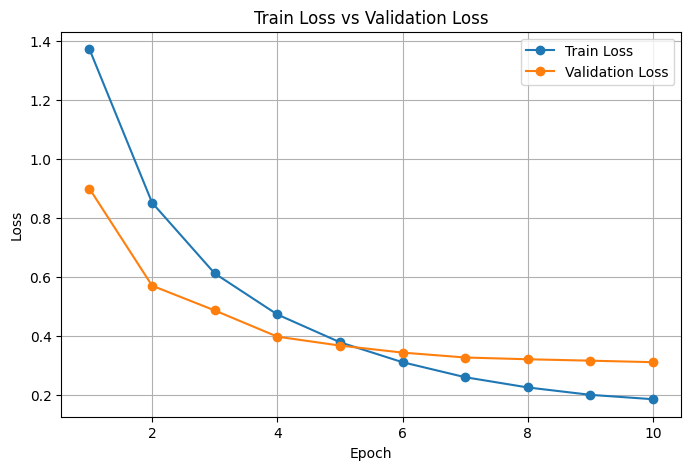

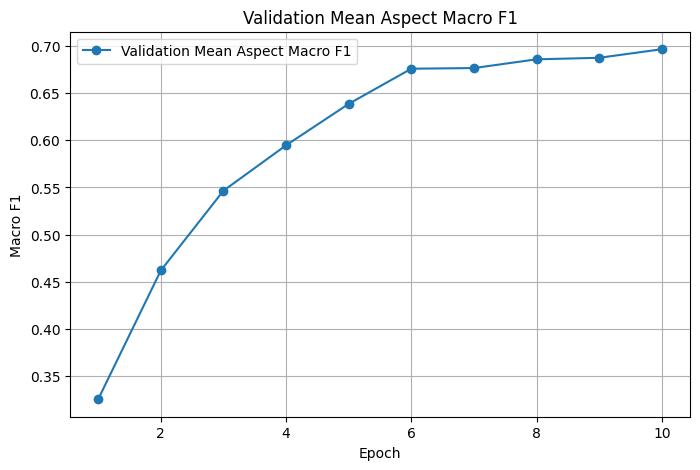

,epoch,validation_loss,validation_mean_macro_f1
0,1.0,0.899209,0.325693
1,2.0,0.570325,0.462054
2,3.0,0.486390,0.546528
3,4.0,0.397439,0.594606
4,5.0,0.367143,0.638493
5,6.0,0.343356,0.675728
6,7.0,0.326744,0.676430
7,8.0,0.320762,0.685659
8,9.0,0.316000,0.687285
9,10.0,0.310876,0.696358


In [ ]:
# ============================================================
# CELL 45: VẼ TRAIN LOSS / VALIDATION LOSS
# ============================================================

import matplotlib.pyplot as plt

log_history = final_trainer.state.log_history

train_epochs = []
train_losses = []

val_epochs = []
val_losses = []

val_f1_epochs = []
val_macro_f1s = []

for log in log_history:
    if "loss" in log and "epoch" in log:
        train_epochs.append(log["epoch"])
        train_losses.append(log["loss"])

    if "eval_loss" in log and "epoch" in log:
        val_epochs.append(log["epoch"])
        val_losses.append(log["eval_loss"])

    if "eval_mean_aspect_macro_f1" in log and "epoch" in log:
        val_f1_epochs.append(log["epoch"])
        val_macro_f1s.append(log["eval_mean_aspect_macro_f1"])

# ------------------------------------------------------------
# 1. Loss curve
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(train_epochs, train_losses, marker="o", label="Train Loss")
plt.plot(val_epochs, val_losses, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train Loss vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 2. Validation Macro F1 curve
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    val_f1_epochs,
    val_macro_f1s,
    marker="o",
    label="Validation Mean Aspect Macro F1"
)
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Validation Mean Aspect Macro F1")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 3. Bảng log gọn
# ------------------------------------------------------------
training_curve_df = pd.DataFrame({
    "epoch": val_epochs,
    "validation_loss": val_losses,
    "validation_mean_macro_f1": val_macro_f1s
})

display(training_curve_df)

In [ ]:
# ============================================================
# CELL 46 MỚI: LƯU MODEL LOSS-BALANCED + METRICS + LOG
# ============================================================

FINAL_SAVE_DIR = "/content/drive/MyDrive/DACS/phobert_absa_final_loss_balanced/final_artifacts"
os.makedirs(FINAL_SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------
# 1. Lưu model state
# ------------------------------------------------------------
MODEL_PATH = os.path.join(
    FINAL_SAVE_DIR,
    "phobert_absa_multiaspect_loss_balanced.pt"
)

torch.save(
    {
        "model_state_dict": final_trainer.model.state_dict(),
        "phobert_model_name": PHOBERT_MODEL_NAME,
        "num_aspects": NUM_ASPECTS,
        "num_classes": NUM_CLASSES,
        "aspects": ASPECTS,
        "id2label": ID2LABEL,
        "max_length": MAX_LENGTH,
        "best_hyperparameters": best_params,
        "class_weights": best_class_weights.cpu().numpy().tolist(),
        "selection_policy": {
            "hpo_objective": "macro_f1 - 0.25 * eval_loss",
            "final_checkpoint_metric": "eval_loss"
        }
    },
    MODEL_PATH
)

# ------------------------------------------------------------
# 2. Lưu best hyperparameters
# ------------------------------------------------------------
BEST_PARAMS_PATH = os.path.join(
    FINAL_SAVE_DIR,
    "best_hyperparameters_loss_balanced.json"
)

with open(BEST_PARAMS_PATH, "w", encoding="utf-8") as f:
    json.dump(
        best_params,
        f,
        ensure_ascii=False,
        indent=2
    )

# ------------------------------------------------------------
# 3. Lưu final metrics
# ------------------------------------------------------------
METRICS_PATH = os.path.join(
    FINAL_SAVE_DIR,
    "final_metrics_loss_balanced.json"
)

with open(METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(
        {
            "validation_metrics": validation_metrics,
            "test_metrics": test_metrics
        },
        f,
        ensure_ascii=False,
        indent=2
    )

# ------------------------------------------------------------
# 4. Lưu trainer log history
# ------------------------------------------------------------
LOG_HISTORY_PATH = os.path.join(
    FINAL_SAVE_DIR,
    "trainer_log_history_loss_balanced.json"
)

with open(LOG_HISTORY_PATH, "w", encoding="utf-8") as f:
    json.dump(
        final_trainer.state.log_history,
        f,
        ensure_ascii=False,
        indent=2
    )

print("✅ Đã lưu artifacts của run loss-balanced:")
print(MODEL_PATH)
print(BEST_PARAMS_PATH)
print(METRICS_PATH)
print(LOG_HISTORY_PATH)

✅ Đã lưu artifacts của run loss-balanced:
/content/drive/MyDrive/DACS/phobert_absa_final_loss_balanced/final_artifacts/phobert_absa_multiaspect_loss_balanced.pt
/content/drive/MyDrive/DACS/phobert_absa_final_loss_balanced/final_artifacts/best_hyperparameters_loss_balanced.json
/content/drive/MyDrive/DACS/phobert_absa_final_loss_balanced/final_artifacts/final_metrics_loss_balanced.json
/content/drive/MyDrive/DACS/phobert_absa_final_loss_balanced/final_artifacts/trainer_log_history_loss_balanced.json


# Đánh giá mô hình trên tập test

In [ ]:
# ============================================================
# CELL 47: PREDICT TRÊN TEST SET
# ============================================================

import numpy as np
import pandas as pd

# 1. Chạy dự đoán trên tập test
test_prediction_output = final_trainer.predict(
    tokenized_datasets["test"]
)

# 2. Lấy logits và labels thật
test_logits = test_prediction_output.predictions
test_labels = test_prediction_output.label_ids

# 3. Chuyển logits -> nhãn dự đoán
test_preds = np.argmax(test_logits, axis=-1)

print("✅ Predict test set hoàn tất")
print("test_logits shape:", test_logits.shape)
print("test_labels shape:", test_labels.shape)
print("test_preds shape:", test_preds.shape)

✅ Predict test set hoàn tất
test_logits shape: (768, 6, 5)
test_labels shape: (768, 6)
test_preds shape: (768, 6)


In [ ]:
# ============================================================
# CELL 48: TÍNH METRIC TỔNG QUÁT TRÊN TEST SET
# ============================================================

from sklearn.metrics import f1_score, accuracy_score

ASPECTS = [
    "HOTEL",
    "LOCATION",
    "ROOMS",
    "FACILITIES",
    "FOOD&DRINKS",
    "SERVICE"
]

ID2LABEL = {
    0: "NONE",
    1: "POSITIVE",
    2: "NEGATIVE",
    3: "NEUTRAL",
    4: "CONFLICT"
}

NUM_CLASSES = len(ID2LABEL)

aspect_summary_rows = []

for aspect_idx, aspect in enumerate(ASPECTS):
    y_true = test_labels[:, aspect_idx]
    y_pred = test_preds[:, aspect_idx]

    macro_f1 = f1_score(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        average="weighted",
        zero_division=0
    )

    accuracy = accuracy_score(y_true, y_pred)

    aspect_summary_rows.append({
        "aspect": aspect,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    })

aspect_summary_df = pd.DataFrame(aspect_summary_rows)

mean_aspect_macro_f1 = aspect_summary_df["macro_f1"].mean()
mean_aspect_accuracy = aspect_summary_df["accuracy"].mean()
mean_aspect_weighted_f1 = aspect_summary_df["weighted_f1"].mean()

exact_match = np.mean(
    np.all(test_preds == test_labels, axis=1)
)

print("===== TEST SET OVERALL METRICS =====")
print(f"Mean Aspect Accuracy   : {mean_aspect_accuracy:.4f}")
print(f"Mean Aspect Macro F1   : {mean_aspect_macro_f1:.4f}")
print(f"Mean Aspect Weighted F1: {mean_aspect_weighted_f1:.4f}")
print(f"Exact Match            : {exact_match:.4f}")

print("\n===== TEST METRICS THEO TỪNG ASPECT =====")
display(
    aspect_summary_df.sort_values(
        "macro_f1",
        ascending=False
    ).reset_index(drop=True)
)

===== TEST SET OVERALL METRICS =====
Mean Aspect Accuracy   : 0.9295
Mean Aspect Macro F1   : 0.6517
Mean Aspect Weighted F1: 0.9322
Exact Match            : 0.7096

===== TEST METRICS THEO TỪNG ASPECT =====


,aspect,accuracy,macro_f1,weighted_f1
0,FOOD&DRINKS,0.966146,0.757479,0.968192
1,HOTEL,0.881510,0.728488,0.884237
2,ROOMS,0.895833,0.705068,0.902710
3,SERVICE,0.925781,0.691353,0.928406
4,FACILITIES,0.934896,0.515697,0.938147
5,LOCATION,0.972656,0.512027,0.971765


In [ ]:
# ============================================================
# CELL 49: CLASSIFICATION REPORT CHO TỪNG ASPECT
# ============================================================

from sklearn.metrics import classification_report

classification_reports = {}

for aspect_idx, aspect in enumerate(ASPECTS):
    y_true = test_labels[:, aspect_idx]
    y_pred = test_preds[:, aspect_idx]

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        target_names=[ID2LABEL[i] for i in range(NUM_CLASSES)],
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report_dict).transpose()

    classification_reports[aspect] = report_df

    print("=" * 100)
    print(f"CLASSIFICATION REPORT — {aspect}")
    display(report_df.round(4))

CLASSIFICATION REPORT — HOTEL


,precision,recall,f1-score,support
NONE,0.8851,0.9034,0.8942,290.0000
POSITIVE,0.9484,0.8991,0.9231,327.0000
NEGATIVE,0.8512,0.8729,0.8619,118.0000
NEUTRAL,0.5238,0.5000,0.5116,22.0000
CONFLICT,0.3500,0.6364,0.4516,11.0000
accuracy,0.8815,0.8815,0.8815,0.8815
macro avg,0.7117,0.7624,0.7285,768.0000
weighted avg,0.8888,0.8815,0.8842,768.0000


CLASSIFICATION REPORT — LOCATION


,precision,recall,f1-score,support
NONE,0.9929,0.9873,0.9901,706.0000
POSITIVE,0.8103,0.9216,0.8624,51.0000
NEGATIVE,0.3333,0.2857,0.3077,7.0000
NEUTRAL,0.0000,0.0000,0.0000,1.0000
CONFLICT,0.5000,0.3333,0.4000,3.0000
accuracy,0.9727,0.9727,0.9727,0.9727
macro avg,0.5273,0.5056,0.5120,768.0000
weighted avg,0.9715,0.9727,0.9718,768.0000


CLASSIFICATION REPORT — ROOMS


...

,precision,recall,f1-score,support
NONE,0.9827,0.9592,0.9708,710.0000
POSITIVE,0.4194,0.6500,0.5098,20.0000
NEGATIVE,0.5526,0.7500,0.6364,28.0000
NEUTRAL,0.5000,0.4286,0.4615,7.0000
CONFLICT,0.0000,0.0000,0.0000,3.0000
accuracy,0.9349,0.9349,0.9349,0.9349
macro avg,0.4909,0.5575,0.5157,768.0000
weighted avg,0.9441,0.9349,0.9381,768.0000


CLASSIFICATION REPORT — FOOD&DRINKS


,precision,recall,f1-score,support
NONE,0.9986,0.9815,0.9900,703.0000
POSITIVE,0.7037,0.8636,0.7755,22.0000
NEGATIVE,0.7097,0.8462,0.7719,26.0000
NEUTRAL,0.4545,0.5556,0.5000,9.0000
CONFLICT,0.7500,0.7500,0.7500,8.0000
accuracy,0.9661,0.9661,0.9661,0.9661
macro avg,0.7233,0.7994,0.7575,768.0000
weighted avg,0.9714,0.9661,0.9682,768.0000


CLASSIFICATION REPORT — SERVICE


,precision,recall,f1-score,support
NONE,0.9791,0.9515,0.9651,639.0000
POSITIVE,0.7671,0.9032,0.8296,62.0000
NEGATIVE,0.7018,0.7547,0.7273,53.0000
NEUTRAL,0.3846,0.5000,0.4348,10.0000
CONFLICT,0.5000,0.5000,0.5000,4.0000
accuracy,0.9258,0.9258,0.9258,0.9258
macro avg,0.6665,0.7219,0.6914,768.0000
weighted avg,0.9326,0.9258,0.9284,768.0000


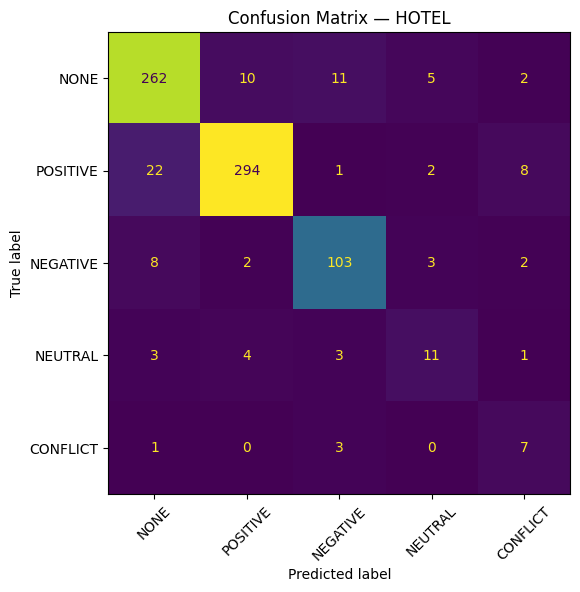

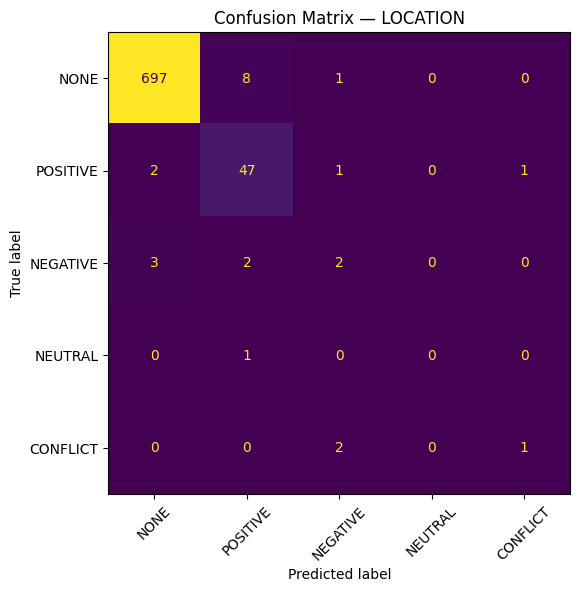

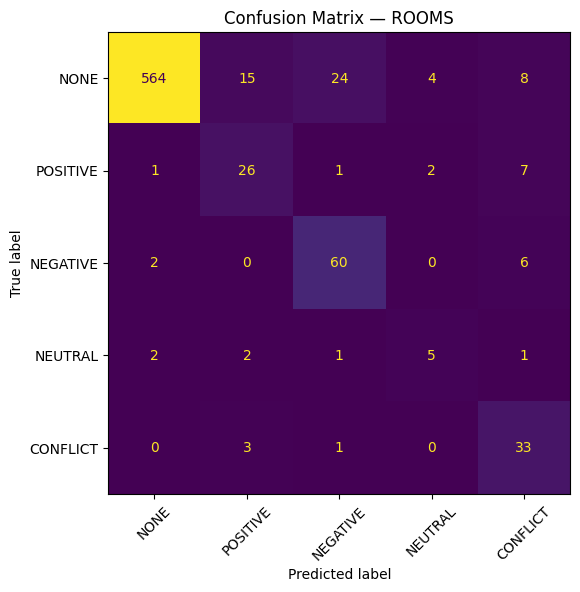

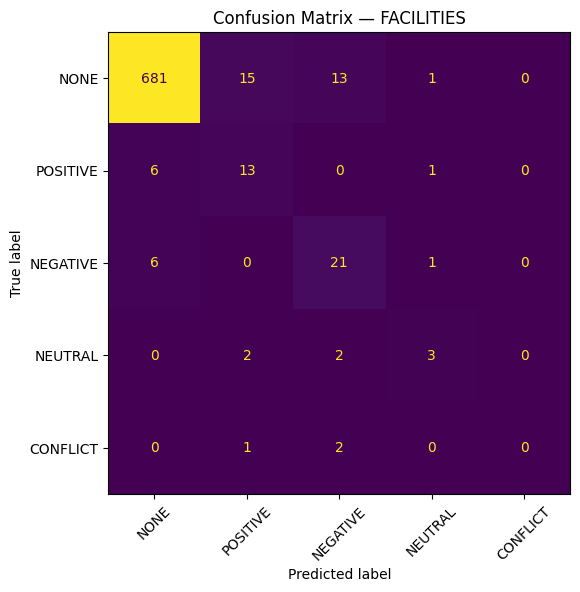

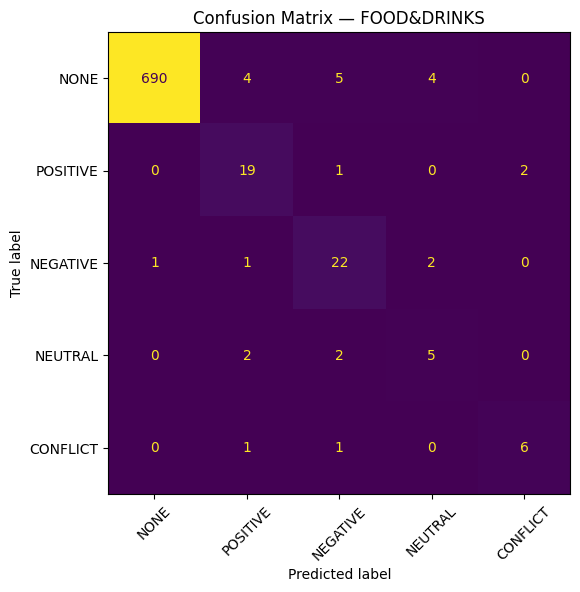

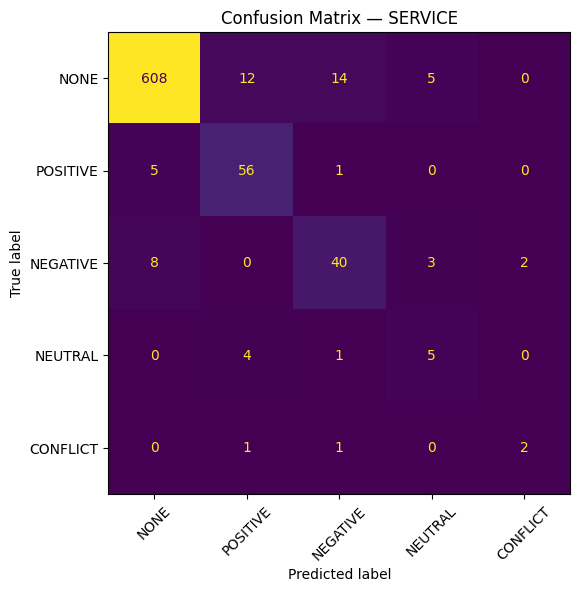

In [ ]:
# ============================================================
# CELL 50: CONFUSION MATRIX CHO TỪNG ASPECT
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

LABEL_NAMES = [ID2LABEL[i] for i in range(NUM_CLASSES)]

for aspect_idx, aspect in enumerate(ASPECTS):
    y_true = test_labels[:, aspect_idx]
    y_pred = test_preds[:, aspect_idx]

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES))
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=LABEL_NAMES
    )

    plt.figure(figsize=(7, 6))
    disp.plot(
        values_format="d",
        cmap=None,
        ax=plt.gca(),
        colorbar=False
    )
    plt.title(f"Confusion Matrix — {aspect}")
    plt.xticks(rotation=45)
    plt.grid(False)
    plt.show()

In [ ]:
# ============================================================
# CELL 51: TẠO BẢNG DỰ ĐOÁN CHI TIẾT TEST SET
# ============================================================

import os

TEST_CSV_PATH = "/content/drive/MyDrive/DACS/absa_splits/test.csv"

test_raw_df = pd.read_csv(TEST_CSV_PATH).reset_index(drop=True)

if len(test_raw_df) != len(test_preds):
    raise ValueError(
        f"Số dòng test.csv ({len(test_raw_df)}) "
        f"khác số prediction ({len(test_preds)})"
    )

def decode_label_row(label_row):
    """
    Chuyển 1 vector [6] thành chuỗi nhãn dễ đọc.
    Bỏ qua các aspect NONE.
    """
    pairs = []

    for aspect_idx, label_id in enumerate(label_row):
        label_name = ID2LABEL[int(label_id)]

        if label_name != "NONE":
            pairs.append(f"{ASPECTS[aspect_idx]}:{label_name}")

    if not pairs:
        return "NONE"

    return "; ".join(pairs)

test_result_df = test_raw_df[
    [
        "review_index",
        "unit_id",
        "unit_text_step2",
        "text_model_input",
        "FINAL_REVIEWED_SENTIMENTS"
    ]
].copy()

test_result_df["ground_truth_decoded"] = [
    decode_label_row(row)
    for row in test_labels
]

test_result_df["prediction_decoded"] = [
    decode_label_row(row)
    for row in test_preds
]

test_result_df["exact_match"] = np.all(
    test_preds == test_labels,
    axis=1
)

test_result_df["num_wrong_aspects"] = (
    test_preds != test_labels
).sum(axis=1)

print("✅ Đã tạo bảng kết quả dự đoán chi tiết")
print("Số dòng test:", len(test_result_df))
print("Exact match:", round(test_result_df["exact_match"].mean(), 4))

display(test_result_df.head(20))

✅ Đã tạo bảng kết quả dự đoán chi tiết
Số dòng test: 768
Exact match: 0.7096


,review_index,unit_id,unit_text_step2,text_model_input,FINAL_REVIEWED_SENTIMENTS,ground_truth_decoded,prediction_decoded,exact_match,num_wrong_aspects
0,861,2,"gym nhỏ, hồ_bơi đẹp nhưng không sạch","gym nhỏ , hồ_bơi đẹp nhưng không sạch",FACILITIES:CONFLICT,FACILITIES:CONFLICT,ROOMS:CONFLICT; FACILITIES:NEGATIVE,False,2
1,4121,1,phòng ốc tiện nghi và rộng sạch nhân viên lịch...,phòng_ốc tiện_nghi và rộng sạch nhân_viên lịch...,FACILITIES:CONFLICT; FOOD&DRINKS:CONFLICT; ROO...,ROOMS:POSITIVE; FACILITIES:CONFLICT; FOOD&DRIN...,ROOMS:POSITIVE; FACILITIES:POSITIVE; FOOD&DRIN...,False,2
2,7496,3,"bữa_sáng ổn, hồ_bơi hơi quá nhỏ, thái độ nhân ...","bữa_sáng ổn , hồ_bơi hơi quá nhỏ , thái_độ nhâ...",FACILITIES:NEGATIVE; FOOD&DRINKS:POSITIVE; ROO...,ROOMS:POSITIVE; FACILITIES:NEGATIVE; FOOD&DRIN...,LOCATION:POSITIVE; ROOMS:CONFLICT; FACILITIES:...,False,2
3,2631,2,"Tuy nhiên, mọi người nên lưu ý, nếu có đi xe v...","Tuy_nhiên , mọi người nên lưu_ý , nếu có đi xe...",FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,FACILITIES:NEUTRAL,False,1
4,3481,3,"thang máy cũng không khá chậm, và cũ","thang_máy cũng không khá chậm , và cũ",FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,True,0
5,5784,2,nhưng về phần bãi đổ xe thì y như lừa đảo,nhưng về phần bãi đổ xe thì y_như lừa_đảo,FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,FACILITIES:NEGATIVE; SERVICE:NEGATIVE,False,1
6,5784,4,khách sạn này ở trong mục đã chọn nhưng không có,khách_sạn này ở trong mục đã chọn nhưng không có,FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,SERVICE:NEGATIVE,False,2
7,8535,4,"muốn bơi phải quay về phòng lấy tiền, chạy xuố...","muốn bơi phải quay về phòng lấy tiền , chạy xu...",FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,True,0
8,9464,1,"Không có chỗ để xe máy, phải trả thêm phí gửi ...","Không có chỗ để xe_máy , phải trả thêm phí gửi...",FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,True,0
9,11395,3,khách phải đi gửi xe hết 150k,khách phải đi gửi xe hết 150k,FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,True,0


In [ ]:
# ============================================================
# CELL 52: XEM DỰ ĐOÁN ĐÚNG / SAI TRÊN TEST SET
# ============================================================

print("===== MẪU DỰ ĐOÁN ĐÚNG HOÀN TOÀN =====")
display(
    test_result_df[
        test_result_df["exact_match"] == True
    ][
        [
            "unit_text_step2",
            "ground_truth_decoded",
            "prediction_decoded"
        ]
    ].sample(
        min(15, int((test_result_df["exact_match"] == True).sum())),
        random_state=42
    )
)

print("\n===== MẪU DỰ ĐOÁN SAI =====")
display(
    test_result_df[
        test_result_df["exact_match"] == False
    ][
        [
            "unit_text_step2",
            "ground_truth_decoded",
            "prediction_decoded",
            "num_wrong_aspects"
        ]
    ].sort_values(
        "num_wrong_aspects",
        ascending=False
    ).head(30)
)

===== MẪU DỰ ĐOÁN ĐÚNG HOÀN TOÀN =====


,unit_text_step2,ground_truth_decoded,prediction_decoded
415,phòng cũng sạch sẽ nhưng hơi cũ,ROOMS:CONFLICT,ROOMS:CONFLICT
132,khách sạn treo đầu dê bán thịt chó,HOTEL:NEGATIVE,HOTEL:NEGATIVE
498,giá cao so với mặt bằng chung nhưng nhũng giá ...,HOTEL:POSITIVE,HOTEL:POSITIVE
149,kỳ nghỉ của chúng tôi kết thúc tốt đẹp tuy nhi...,HOTEL:NEGATIVE,HOTEL:NEGATIVE
673,"Gia đình chúng tôi 7 người, trong đó có 3 trẻ ...",ROOMS:NEGATIVE,ROOMS:NEGATIVE
284,rất đáng để ở nha,HOTEL:POSITIVE,HOTEL:POSITIVE
249,khách sạn thực sự ổn so với giá_tiền,HOTEL:POSITIVE,HOTEL:POSITIVE
327,đã ở khách sạn này nhiều lần và sẽ nghỉ ở đây ...,HOTEL:POSITIVE,HOTEL:POSITIVE
704,chất lượng phòng kém,ROOMS:NEGATIVE,ROOMS:NEGATIVE
580,là sạch sẽ giá thì hợp lý,HOTEL:POSITIVE,HOTEL:POSITIVE



===== MẪU DỰ ĐOÁN SAI =====


,unit_text_step2,ground_truth_decoded,prediction_decoded,num_wrong_aspects
712,nhân viên thân thiện nhưng chuẩn bị phòng còn ...,ROOMS:NEGATIVE; SERVICE:CONFLICT,FACILITIES:NEGATIVE; FOOD&DRINKS:NEGATIVE; SER...,4
734,"khách sạn lâu đời tại quận 1, trang thiết bị t...",ROOMS:POSITIVE,HOTEL:CONFLICT; LOCATION:POSITIVE; ROOMS:CONFL...,4
534,thuạn tiện và rộng rãi,HOTEL:POSITIVE,LOCATION:POSITIVE; ROOMS:POSITIVE; FACILITIES:...,4
688,không co nươc nong,ROOMS:NEGATIVE,HOTEL:NEGATIVE; FACILITIES:NEGATIVE; SERVICE:N...,4
14,"nhà_vệ_sinh tầng_trệt bẩn , thuê 7 phòng 2 đêm...",FACILITIES:NEGATIVE; SERVICE:NEGATIVE,HOTEL:NEGATIVE; ROOMS:NEGATIVE; SERVICE:NEGATIVE,3
34,"thoai mai voi nhung tien ich cua khách sạn, ho...",FACILITIES:POSITIVE; SERVICE:POSITIVE,HOTEL:POSITIVE,3
382,"khách sạn sạch , tầng 1 có siêu thị , phòng ng...",HOTEL:POSITIVE; ROOMS:NEGATIVE; FACILITIES:NEU...,HOTEL:POSITIVE; LOCATION:POSITIVE; ROOMS:CONFL...,3
384,khách sạn mới vận hành vài năm nên cơ sở vật c...,HOTEL:POSITIVE; ROOMS:POSITIVE,ROOMS:POSITIVE; FACILITIES:POSITIVE; SERVICE:P...,3
489,hình như là khách sạn duy nhất ở vn khách tự n...,HOTEL:NEGATIVE,ROOMS:NEGATIVE; SERVICE:NEGATIVE,3
425,"check in lâu , lối vào hẹp , toilet sạch , nội...",LOCATION:NEGATIVE; ROOMS:POSITIVE; SERVICE:CON...,LOCATION:POSITIVE; ROOMS:POSITIVE; FACILITIES:...,3


In [ ]:
# ============================================================
# CELL 53: LƯU KẾT QUẢ ĐÁNH GIÁ TEST SET
# ============================================================

EVALUATION_DIR = "/content/drive/MyDrive/DACS/phobert_absa_final_loss_balanced/test_evaluation"
os.makedirs(EVALUATION_DIR, exist_ok=True)

# 1. Lưu bảng metric theo aspect
ASPECT_METRICS_PATH = os.path.join(
    EVALUATION_DIR,
    "test_aspect_summary_metrics.csv"
)
aspect_summary_df.to_csv(
    ASPECT_METRICS_PATH,
    index=False,
    encoding="utf-8-sig"
)

# 2. Lưu classification report từng aspect
for aspect, report_df in classification_reports.items():
    report_path = os.path.join(
        EVALUATION_DIR,
        f"classification_report_{aspect}.csv"
    )
    report_df.to_csv(
        report_path,
        encoding="utf-8-sig"
    )

# 3. Lưu bảng dự đoán chi tiết
TEST_PREDICTIONS_PATH = os.path.join(
    EVALUATION_DIR,
    "test_predictions_detail.csv"
)
test_result_df.to_csv(
    TEST_PREDICTIONS_PATH,
    index=False,
    encoding="utf-8-sig"
)

# 4. Lưu metric tổng quát
overall_metrics = {
    "mean_aspect_accuracy": float(mean_aspect_accuracy),
    "mean_aspect_macro_f1": float(mean_aspect_macro_f1),
    "mean_aspect_weighted_f1": float(mean_aspect_weighted_f1),
    "exact_match": float(exact_match)
}

OVERALL_METRICS_PATH = os.path.join(
    EVALUATION_DIR,
    "test_overall_metrics.json"
)

with open(OVERALL_METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(
        overall_metrics,
        f,
        ensure_ascii=False,
        indent=2
    )

print("✅ Đã lưu kết quả đánh giá:")
print(ASPECT_METRICS_PATH)
print(TEST_PREDICTIONS_PATH)
print(OVERALL_METRICS_PATH)

✅ Đã lưu kết quả đánh giá:
/content/drive/MyDrive/DACS/phobert_absa_final_loss_balanced/test_evaluation/test_aspect_summary_metrics.csv
/content/drive/MyDrive/DACS/phobert_absa_final_loss_balanced/test_evaluation/test_predictions_detail.csv
/content/drive/MyDrive/DACS/phobert_absa_final_loss_balanced/test_evaluation/test_overall_metrics.json


# Tokenize dataset cho ViSoBERT

In [ ]:
# ============================================================
# CELL 54: LOAD TRAIN/VAL/TEST CHO VISOBERT + TẠO LABEL VECTOR
# ============================================================

import os
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Load dữ liệu đã split
# ------------------------------------------------------------
SPLIT_DIR = "/content/drive/MyDrive/DACS/absa_splits"

TRAIN_PATH = os.path.join(SPLIT_DIR, "train.csv")
VAL_PATH = os.path.join(SPLIT_DIR, "validation.csv")
TEST_PATH = os.path.join(SPLIT_DIR, "test.csv")

for path in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Không tìm thấy file: {path}")

viso_train_df = pd.read_csv(TRAIN_PATH)
viso_val_df = pd.read_csv(VAL_PATH)
viso_test_df = pd.read_csv(TEST_PATH)

# ------------------------------------------------------------
# 2. Khai báo schema label
# ------------------------------------------------------------
ASPECTS = [
    "HOTEL",
    "LOCATION",
    "ROOMS",
    "FACILITIES",
    "FOOD&DRINKS",
    "SERVICE"
]

LABEL_ID_COLUMNS = [f"{aspect}_id" for aspect in ASPECTS]

# ------------------------------------------------------------
# 3. Tạo vector labels = [6 aspect ids]
# ------------------------------------------------------------
for split_name, dataframe in [
    ("train", viso_train_df),
    ("validation", viso_val_df),
    ("test", viso_test_df)
]:
    required_cols = {"text_model_input"} | set(LABEL_ID_COLUMNS)
    missing_cols = required_cols - set(dataframe.columns)

    if missing_cols:
        raise ValueError(f"{split_name} thiếu cột: {missing_cols}")

    dataframe[LABEL_ID_COLUMNS] = dataframe[LABEL_ID_COLUMNS].astype(int)
    dataframe["labels"] = dataframe[LABEL_ID_COLUMNS].values.tolist()

print("✅ Load dữ liệu và tạo labels cho ViSoBERT thành công")
print("Train:", viso_train_df.shape)
print("Validation:", viso_val_df.shape)
print("Test:", viso_test_df.shape)

display(
    viso_train_df[
        ["text_model_input", "FINAL_REVIEWED_SENTIMENTS", "labels"]
    ].head(10)
)

✅ Load dữ liệu và tạo labels cho ViSoBERT thành công
Train: (6060, 22)
Validation: (767, 22)
Test: (768, 22)


,text_model_input,FINAL_REVIEWED_SENTIMENTS,labels
0,10đ cho sự chuyên_nghiệp điểm trừ là phòng nhỏ...,HOTEL:POSITIVE; ROOMS:CONFLICT; SERVICE:POSITIVE,"[1, 0, 4, 0, 0, 1]"
1,nhưng hồ_bơi không sạch lắm được view đẹp,FACILITIES:CONFLICT,"[0, 0, 0, 4, 0, 0]"
2,"có bãi đỗ ô_tô , tuy_nhiên khu_vực bãi đỗ có m...",FACILITIES:CONFLICT,"[0, 0, 0, 4, 0, 0]"
3,có khu_vực giặt và sấy đồ rất rất tiện_dụng đi...,FACILITIES:CONFLICT,"[0, 0, 0, 4, 0, 0]"
4,hồ_bơi view đẹp nhưng khá nhỏ,FACILITIES:CONFLICT,"[0, 0, 0, 4, 0, 0]"
5,"các tiện_ích , thiết_bị khách_sạn tốt nhưng bể...",FACILITIES:CONFLICT,"[0, 0, 0, 4, 0, 0]"
6,tầng 2 và tầng trên cùng khi tổ_chức sự_kiện t...,FACILITIES:CONFLICT,"[0, 0, 0, 4, 0, 0]"
7,tiện_nghi đầy_đủ nhưng hơi cũ,FACILITIES:CONFLICT,"[0, 0, 0, 4, 0, 0]"
8,khách_sạn có thang_máy nên cũng khá tiện dù th...,FACILITIES:CONFLICT,"[0, 0, 0, 4, 0, 0]"
9,"tiện_lợi để đi dạo trung_tâm , thái_độ nhân_vi...",FACILITIES:CONFLICT; FOOD&DRINKS:NEGATIVE; LOC...,"[0, 1, 2, 4, 2, 1]"


In [ ]:
# ============================================================
# CELL 55: LOAD VISOBERT TOKENIZER + ĐO TOKEN LENGTH + CHỌN MAX LENGTH
# ============================================================

!pip install -q transformers datasets

from transformers import AutoTokenizer
from tqdm.auto import tqdm

VISOBERT_MODEL_NAME = "uitnlp/visobert"

visobert_tokenizer = AutoTokenizer.from_pretrained(
    VISOBERT_MODEL_NAME
)

print("✅ Load ViSoBERT tokenizer thành công")
print("Tokenizer class:", visobert_tokenizer.__class__.__name__)
print("Vocab size:", visobert_tokenizer.vocab_size)

# ------------------------------------------------------------
# 1. Gom toàn bộ text train/val/test
# ------------------------------------------------------------
viso_all_texts = pd.concat([
    viso_train_df["text_model_input"],
    viso_val_df["text_model_input"],
    viso_test_df["text_model_input"]
], ignore_index=True).fillna("").astype(str).tolist()

# ------------------------------------------------------------
# 2. Đo độ dài token
# ------------------------------------------------------------
viso_token_lengths = []

for text in tqdm(viso_all_texts, desc="Đang đo token length cho ViSoBERT"):
    encoded = visobert_tokenizer(
        text,
        add_special_tokens=True,
        truncation=False
    )
    viso_token_lengths.append(len(encoded["input_ids"]))

viso_length_series = pd.Series(viso_token_lengths)

print("\nThống kê token length ViSoBERT:")
display(
    viso_length_series.describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    ).to_frame("token_length")
)

# ------------------------------------------------------------
# 3. Đề xuất MAX_LENGTH
# ------------------------------------------------------------
viso_p99 = int(viso_length_series.quantile(0.99))

if viso_p99 <= 64:
    VISOBERT_MAX_LENGTH = 64
elif viso_p99 <= 128:
    VISOBERT_MAX_LENGTH = 128
else:
    VISOBERT_MAX_LENGTH = 256

print("\nĐộ dài vượt ngưỡng:")
print("Số mẫu > 64 :", int((viso_length_series > 64).sum()))
print("Số mẫu > 128:", int((viso_length_series > 128).sum()))
print("Số mẫu > 256:", int((viso_length_series > 256).sum()))

print("\n✅ VISOBERT_MAX_LENGTH được đề xuất:", VISOBERT_MAX_LENGTH)

config.json:   0%|          | 0.00/644 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/471k [00:00<?, ?B/s]

✅ Load ViSoBERT tokenizer thành công
Tokenizer class: XLMRobertaTokenizer
Vocab size: 15002


Đang đo token length cho ViSoBERT:   0%|          | 0/7595 [00:00<?, ?it/s]


Thống kê token length ViSoBERT:


,token_length
count,7595.000000
mean,26.035155
std,18.810190
min,4.000000
50%,21.000000
75%,32.000000
90%,48.000000
95%,61.300000
99%,97.060000
max,214.000000



Độ dài vượt ngưỡng:
Số mẫu > 64 : 332
Số mẫu > 128: 26
Số mẫu > 256: 0

✅ VISOBERT_MAX_LENGTH được đề xuất: 128


In [ ]:
# ============================================================
# CELL 56: TẠO DATASET VISOBERT + TOKENIZE TOÀN BỘ
# ============================================================

from datasets import Dataset, DatasetDict

# ------------------------------------------------------------
# 1. Chỉ giữ cột input và labels
# ------------------------------------------------------------
VISO_KEEP_COLUMNS = [
    "text_model_input",
    "labels"
]

visobert_dataset_dict = DatasetDict({
    "train": Dataset.from_pandas(
        viso_train_df[VISO_KEEP_COLUMNS].reset_index(drop=True)
    ),
    "validation": Dataset.from_pandas(
        viso_val_df[VISO_KEEP_COLUMNS].reset_index(drop=True)
    ),
    "test": Dataset.from_pandas(
        viso_test_df[VISO_KEEP_COLUMNS].reset_index(drop=True)
    )
})

print("Dataset trước tokenize:")
print(visobert_dataset_dict)

# ------------------------------------------------------------
# 2. Hàm tokenize riêng cho ViSoBERT
# ------------------------------------------------------------
def visobert_tokenize_batch(batch):
    return visobert_tokenizer(
        batch["text_model_input"],
        padding="max_length",
        truncation=True,
        max_length=VISOBERT_MAX_LENGTH
    )

# ------------------------------------------------------------
# 3. Tokenize toàn bộ dataset
# ------------------------------------------------------------
tokenized_visobert_datasets = visobert_dataset_dict.map(
    visobert_tokenize_batch,
    batched=True,
    desc="Đang tokenize dữ liệu cho ViSoBERT"
)

print("\n✅ Tokenize ViSoBERT hoàn tất")
print(tokenized_visobert_datasets)

print("\nVí dụ 1 mẫu sau tokenize:")
print(tokenized_visobert_datasets["train"][0])

Dataset trước tokenize:
DatasetDict({
    train: Dataset({
        features: ['text_model_input', 'labels'],
        num_rows: 6060
    })
    validation: Dataset({
        features: ['text_model_input', 'labels'],
        num_rows: 767
    })
    test: Dataset({
        features: ['text_model_input', 'labels'],
        num_rows: 768
    })
})


Đang tokenize dữ liệu cho ViSoBERT:   0%|          | 0/6060 [00:00<?, ? examples/s]

Đang tokenize dữ liệu cho ViSoBERT:   0%|          | 0/767 [00:00<?, ? examples/s]

Đang tokenize dữ liệu cho ViSoBERT:   0%|          | 0/768 [00:00<?, ? examples/s]


✅ Tokenize ViSoBERT hoàn tất
DatasetDict({
    train: Dataset({
        features: ['text_model_input', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 6060
    })
    validation: Dataset({
        features: ['text_model_input', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 767
    })
    test: Dataset({
        features: ['text_model_input', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 768
    })
})

Ví dụ 1 mẫu sau tokenize:
{'text_model_input': '10đ cho sự chuyên_nghiệp điểm trừ là phòng nhỏ quá ai chỉ cần chỗ ngủ nghỉ thì ocela còn có nhu_cầu sinh_hoạt thì nên kiếm phòng to hơn cho thoải_mái', 'labels': [1, 0, 4, 0, 0, 1], 'input_ids': [0, 1573, 14648, 71, 412, 11, 43, 31, 14800, 7766, 698, 761, 1935, 29, 35, 295, 598, 115, 265, 229, 5, 76, 806, 656, 1024, 61, 243, 1965, 2975, 5, 119, 41, 16, 1055, 14800, 13191, 19, 81, 14800, 3009, 454, 61, 16, 31, 17, 870, 35, 295, 270, 13, 124, 71, 535, 99, 14800, 14644, 205, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [ ]:
# ============================================================
# CELL 57: SET FORMAT PYTORCH + KIỂM TRA + LƯU TOKENIZED VISOBERT DATASET
# ============================================================

import os

# ------------------------------------------------------------
# 1. Bỏ text raw khỏi dataset tokenized
# ------------------------------------------------------------
tokenized_visobert_datasets = tokenized_visobert_datasets.remove_columns([
    "text_model_input"
])

# ------------------------------------------------------------
# 2. Chuyển sang PyTorch tensor
# ------------------------------------------------------------
tokenized_visobert_datasets.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels"
    ]
)

# ------------------------------------------------------------
# 3. Kiểm tra 1 sample
# ------------------------------------------------------------
viso_sample = tokenized_visobert_datasets["train"][0]

print("✅ Dataset ViSoBERT đã sẵn sàng cho PyTorch")
print(tokenized_visobert_datasets)

print("\nKiểm tra 1 sample:")
print("input_ids shape:", viso_sample["input_ids"].shape)
print("attention_mask shape:", viso_sample["attention_mask"].shape)
print("labels:", viso_sample["labels"])
print("labels shape:", viso_sample["labels"].shape)

# ------------------------------------------------------------
# 4. Kiểm tra số mẫu có thể bị truncate
# ------------------------------------------------------------
viso_num_truncated_like = int((viso_length_series > VISOBERT_MAX_LENGTH).sum())
viso_ratio_truncated_like = viso_num_truncated_like / len(viso_length_series)

print("\nKiểm tra truncate:")
print("VISOBERT_MAX_LENGTH:", VISOBERT_MAX_LENGTH)
print("Số mẫu dài hơn VISOBERT_MAX_LENGTH:", viso_num_truncated_like)
print("Tỷ lệ có thể bị truncate:", round(viso_ratio_truncated_like * 100, 4), "%")

# ------------------------------------------------------------
# 5. Lưu checkpoint riêng cho ViSoBERT
# ------------------------------------------------------------
VISOBERT_TOKENIZED_SAVE_DIR = (
    "/content/drive/MyDrive/DACS/absa_tokenized_visobert_datasets"
)

tokenized_visobert_datasets.save_to_disk(
    VISOBERT_TOKENIZED_SAVE_DIR
)

print("\n✅ Đã lưu tokenized ViSoBERT dataset:")
print(VISOBERT_TOKENIZED_SAVE_DIR)

✅ Dataset ViSoBERT đã sẵn sàng cho PyTorch
DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 6060
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 767
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 768
    })
})

Kiểm tra 1 sample:
input_ids shape: torch.Size([128])
attention_mask shape: torch.Size([128])
labels: tensor([1, 0, 4, 0, 0, 1])
labels shape: torch.Size([6])

Kiểm tra truncate:
VISOBERT_MAX_LENGTH: 128
Số mẫu dài hơn VISOBERT_MAX_LENGTH: 26
Tỷ lệ có thể bị truncate: 0.3423 %


Saving the dataset (0/1 shards):   0%|          | 0/6060 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/767 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/768 [00:00<?, ? examples/s]


✅ Đã lưu tokenized ViSoBERT dataset:
/content/drive/MyDrive/DACS/absa_tokenized_visobert_datasets


# Huấn luyện ViSoBERT cho bài toán ABSA

In [ ]:
# @title
# ============================================================
# CELL 58: CẤU HÌNH CHUNG CHO VISOBERT + KIỂM TRA GPU
# ============================================================

import os
import json
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from transformers import AutoModel

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    print("✅ GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️ Đang chạy bằng CPU. Train ViSoBERT sẽ rất chậm.")

# ------------------------------------------------------------
# 1. Cấu hình bài toán
# ------------------------------------------------------------
ASPECTS = [
    "HOTEL",
    "LOCATION",
    "ROOMS",
    "FACILITIES",
    "FOOD&DRINKS",
    "SERVICE"
]

ID2LABEL = {
    0: "NONE",
    1: "POSITIVE",
    2: "NEGATIVE",
    3: "NEUTRAL",
    4: "CONFLICT"
}

NUM_ASPECTS = len(ASPECTS)
NUM_CLASSES = len(ID2LABEL)

VISOBERT_MODEL_NAME = "uitnlp/visobert"

# Đã xác nhận ở Tác vụ 8
VISOBERT_MAX_LENGTH = 128

print("NUM_ASPECTS:", NUM_ASPECTS)
print("NUM_CLASSES:", NUM_CLASSES)
print("VISOBERT_MODEL_NAME:", VISOBERT_MODEL_NAME)
print("VISOBERT_MAX_LENGTH:", VISOBERT_MAX_LENGTH)

print("\nDataset ViSoBERT:")
print(tokenized_visobert_datasets)

✅ GPU: Tesla T4
NUM_ASPECTS: 6
NUM_CLASSES: 5
VISOBERT_MODEL_NAME: uitnlp/visobert
VISOBERT_MAX_LENGTH: 128

Dataset ViSoBERT:
DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 6060
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 767
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 768
    })
})


In [ ]:

# ============================================================
# CELL 59: CLASS WEIGHTS + MODEL VISOBERT ABSA + METRICS
# ============================================================

from sklearn.metrics import f1_score, accuracy_score

# ------------------------------------------------------------
# 1. Lấy label train để tính class weights
# ------------------------------------------------------------
viso_train_labels_np = np.array(
    tokenized_visobert_datasets["train"]["labels"]
)

def visobert_build_class_weights(max_class_weight: float = 4.0) -> torch.Tensor:
    """
    Tính class weights riêng cho từng aspect.
    Output shape: [NUM_ASPECTS, NUM_CLASSES]
    """
    all_weights = []

    for aspect_idx in range(NUM_ASPECTS):
        y = viso_train_labels_np[:, aspect_idx]

        counts = np.bincount(y, minlength=NUM_CLASSES)
        total = counts.sum()

        weights = total / (NUM_CLASSES * np.maximum(counts, 1))
        weights = np.clip(weights, 0.0, max_class_weight)

        # Chuẩn hóa để trung bình weight xấp xỉ 1
        weights = weights / weights.mean()

        all_weights.append(weights)

    return torch.tensor(
        np.array(all_weights),
        dtype=torch.float32
    )

# ------------------------------------------------------------
# 2. Model ViSoBERT cho ABSA
# ------------------------------------------------------------
class ViSoBERTMultiAspectClassifier(nn.Module):
    def __init__(
        self,
        pretrained_model_name: str,
        num_aspects: int,
        num_classes: int,
        class_weights: torch.Tensor,
        dropout_prob: float = 0.3
    ):
        super().__init__()

        self.num_aspects = num_aspects
        self.num_classes = num_classes

        self.encoder = AutoModel.from_pretrained(
            pretrained_model_name
        )

        hidden_size = self.encoder.config.hidden_size

        self.dropout = nn.Dropout(dropout_prob)

        self.classifier = nn.Linear(
            hidden_size,
            num_aspects * num_classes
        )

        self.register_buffer(
            "class_weights",
            class_weights
        )

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        labels=None
    ):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Token đầu câu, tương tự CLS representation
        cls_output = outputs.last_hidden_state[:, 0, :]

        cls_output = self.dropout(cls_output)

        logits = self.classifier(cls_output)
        logits = logits.view(
            -1,
            self.num_aspects,
            self.num_classes
        )

        loss = None

        if labels is not None:
            labels = labels.long()
            aspect_losses = []

            for aspect_idx in range(self.num_aspects):
                loss_fn = nn.CrossEntropyLoss(
                    weight=self.class_weights[aspect_idx]
                )

                aspect_loss = loss_fn(
                    logits[:, aspect_idx, :],
                    labels[:, aspect_idx]
                )

                aspect_losses.append(aspect_loss)

            loss = torch.stack(aspect_losses).mean()

        return {
            "loss": loss,
            "logits": logits
        }

# ------------------------------------------------------------
# 3. Metrics dùng chung với PhoBERT
# ------------------------------------------------------------
def visobert_compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    metrics = {}

    aspect_macro_f1_scores = []
    aspect_accuracy_scores = []

    for aspect_idx, aspect in enumerate(ASPECTS):
        y_true = labels[:, aspect_idx]
        y_pred = preds[:, aspect_idx]

        macro_f1 = f1_score(
            y_true,
            y_pred,
            labels=list(range(NUM_CLASSES)),
            average="macro",
            zero_division=0
        )

        accuracy = accuracy_score(
            y_true,
            y_pred
        )

        aspect_macro_f1_scores.append(macro_f1)
        aspect_accuracy_scores.append(accuracy)

        metrics[f"{aspect.lower()}_macro_f1"] = float(macro_f1)
        metrics[f"{aspect.lower()}_accuracy"] = float(accuracy)

    metrics["mean_aspect_macro_f1"] = float(
        np.mean(aspect_macro_f1_scores)
    )

    metrics["mean_aspect_accuracy"] = float(
        np.mean(aspect_accuracy_scores)
    )

    metrics["exact_match"] = float(
        np.mean(np.all(preds == labels, axis=1))
    )

    return metrics

print("✅ Đã khai báo:")
print("- visobert_build_class_weights")
print("- ViSoBERTMultiAspectClassifier")
print("- visobert_compute_metrics")

✅ Đã khai báo:
- visobert_build_class_weights
- ViSoBERTMultiAspectClassifier
- visobert_compute_metrics


In [ ]:

# ============================================================
# CELL 60: HPO VISOBERT — LOSS-BALANCED
# ============================================================

!pip install -q optuna

from transformers import (
    TrainingArguments,
    Trainer,
    default_data_collator
)
import inspect

VISOBERT_HPO_OUTPUT_DIR = (
    "/content/drive/MyDrive/DACS/visobert_absa_hpo_loss_balanced"
)

# ------------------------------------------------------------
# 1. model_init cho từng HPO trial
# ------------------------------------------------------------
def visobert_model_init(trial=None):
    if trial is None:
        dropout_prob = 0.3
        max_class_weight = 4.0
    else:
        dropout_prob = trial.suggest_categorical(
            "dropout_prob",
            [0.2, 0.3, 0.4]
        )

        max_class_weight = trial.suggest_categorical(
            "max_class_weight",
            [3.0, 4.0, 5.0]
        )

    trial_class_weights = visobert_build_class_weights(
        max_class_weight=max_class_weight
    )

    return ViSoBERTMultiAspectClassifier(
        pretrained_model_name=VISOBERT_MODEL_NAME,
        num_aspects=NUM_ASPECTS,
        num_classes=NUM_CLASSES,
        class_weights=trial_class_weights,
        dropout_prob=dropout_prob
    )

# ------------------------------------------------------------
# 2. TrainingArguments nền cho HPO
# ------------------------------------------------------------
hpo_args_kwargs = dict(
    output_dir=VISOBERT_HPO_OUTPUT_DIR,

    learning_rate=1e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=5,

    weight_decay=0.05,
    warmup_ratio=0.1,

    logging_strategy="epoch",
    save_strategy="no",

    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED
)

training_args_signature = inspect.signature(
    TrainingArguments.__init__
).parameters

if "eval_strategy" in training_args_signature:
    hpo_args_kwargs["eval_strategy"] = "epoch"
else:
    hpo_args_kwargs["evaluation_strategy"] = "epoch"

visobert_hpo_training_args = TrainingArguments(
    **hpo_args_kwargs
)

# ------------------------------------------------------------
# 3. Trainer HPO
# ------------------------------------------------------------
visobert_hpo_trainer = Trainer(
    model_init=visobert_model_init,
    args=visobert_hpo_training_args,
    train_dataset=tokenized_visobert_datasets["train"],
    eval_dataset=tokenized_visobert_datasets["validation"],
    data_collator=default_data_collator,
    compute_metrics=visobert_compute_metrics
)

# ------------------------------------------------------------
# 4. Search space
# ------------------------------------------------------------
def visobert_hp_space(trial):
    return {
        "learning_rate": trial.suggest_float(
            "learning_rate",
            5e-6,
            2e-5,
            log=True
        ),

        "per_device_train_batch_size": trial.suggest_categorical(
            "per_device_train_batch_size",
            [8, 16]
        ),

        "weight_decay": trial.suggest_categorical(
            "weight_decay",
            [0.01, 0.05, 0.1]
        ),

        "warmup_ratio": trial.suggest_categorical(
            "warmup_ratio",
            [0.05, 0.1]
        )
    }

# ------------------------------------------------------------
# 5. Objective loss-balanced
# ------------------------------------------------------------
VISOBERT_ALPHA_LOSS = 0.25

def visobert_compute_objective(metrics):
    macro_f1 = metrics["eval_mean_aspect_macro_f1"]
    val_loss = metrics["eval_loss"]

    return macro_f1 - VISOBERT_ALPHA_LOSS * val_loss

# ------------------------------------------------------------
# 6. Số trial
# ------------------------------------------------------------
# Nếu cần tiết kiệm thời gian: để 6
# Nếu GPU ổn và muốn kỹ hơn: đổi thành 8
VISOBERT_N_TRIALS = 6

visobert_best_run = visobert_hpo_trainer.hyperparameter_search(
    direction="maximize",
    backend="optuna",
    hp_space=visobert_hp_space,
    compute_objective=visobert_compute_objective,
    n_trials=VISOBERT_N_TRIALS
)

print("✅ HPO ViSoBERT hoàn tất")

print("\nBest composite objective:")
print(visobert_best_run.objective)

print("\nBest hyperparameters:")
print(visobert_best_run.hyperparameters)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


pytorch_model.bin:   0%|          | 0.00/390M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/390M [00:00<?, ?B/s]

XLMRobertaModel LOAD REPORT from: uitnlp/visobert
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[I 2026-05-18 14:13:23,116] A new study created in memory with name: no-name-d5adf26a-8fe6-4180-b718-3bee4609817b


...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: uitnlp/visobert
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Hotel Macro F1,Hotel Accuracy,Location Macro F1,Location Accuracy,Rooms Macro F1,Rooms Accuracy,Facilities Macro F1,Facilities Accuracy,Food&drinks Macro F1,Food&drinks Accuracy,Service Macro F1,Service Accuracy,Mean Aspect Macro F1,Mean Aspect Accuracy,Exact Match
1,1.179655,0.621780,0.399071,0.697523,0.291625,0.917862,0.470946,0.804433,0.263372,0.895698,0.375703,0.938722,0.344302,0.778357,0.357503,0.838766,0.438070


[I 2026-05-18 14:35:42,624] Trial 5 pruned. 


✅ HPO ViSoBERT hoàn tất

Best composite objective:
0.4734544470330422

Best hyperparameters:
{'learning_rate': 1.775733980493345e-05, 'per_device_train_batch_size': 16, 'weight_decay': 0.1, 'warmup_ratio': 0.05, 'dropout_prob': 0.3, 'max_class_weight': 3.0}


In [ ]:

# ============================================================
# CELL 61: TRAIN FINAL VISOBERT BẰNG BEST HYPERPARAMETERS
# ============================================================

from transformers import EarlyStoppingCallback

visobert_best_params = visobert_best_run.hyperparameters

VISO_BEST_LEARNING_RATE = visobert_best_params["learning_rate"]
VISO_BEST_BATCH_SIZE = visobert_best_params["per_device_train_batch_size"]
VISO_BEST_WEIGHT_DECAY = visobert_best_params["weight_decay"]
VISO_BEST_WARMUP_RATIO = visobert_best_params["warmup_ratio"]
VISO_BEST_DROPOUT = visobert_best_params["dropout_prob"]
VISO_BEST_MAX_CLASS_WEIGHT = visobert_best_params["max_class_weight"]

print("Best params dùng cho final ViSoBERT:")
print(json.dumps(visobert_best_params, indent=2))

# ------------------------------------------------------------
# 1. Tạo class weights final
# ------------------------------------------------------------
visobert_best_class_weights = visobert_build_class_weights(
    max_class_weight=VISO_BEST_MAX_CLASS_WEIGHT
)

visobert_class_weight_df = pd.DataFrame(
    visobert_best_class_weights.numpy(),
    index=ASPECTS,
    columns=[ID2LABEL[i] for i in range(NUM_CLASSES)]
)

print("\nClass weights final ViSoBERT:")
display(visobert_class_weight_df)

# ------------------------------------------------------------
# 2. Khởi tạo final model mới
# ------------------------------------------------------------
visobert_final_model = ViSoBERTMultiAspectClassifier(
    pretrained_model_name=VISOBERT_MODEL_NAME,
    num_aspects=NUM_ASPECTS,
    num_classes=NUM_CLASSES,
    class_weights=visobert_best_class_weights,
    dropout_prob=VISO_BEST_DROPOUT
)

# ------------------------------------------------------------
# 3. TrainingArguments final
# ------------------------------------------------------------
VISOBERT_FINAL_OUTPUT_DIR = (
    "/content/drive/MyDrive/DACS/visobert_absa_final_loss_balanced"
)

final_args_kwargs = dict(
    output_dir=VISOBERT_FINAL_OUTPUT_DIR,

    learning_rate=VISO_BEST_LEARNING_RATE,
    per_device_train_batch_size=VISO_BEST_BATCH_SIZE,
    per_device_eval_batch_size=16,
    num_train_epochs=10,

    weight_decay=VISO_BEST_WEIGHT_DECAY,
    warmup_ratio=VISO_BEST_WARMUP_RATIO,

    logging_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,

    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED
)

if "eval_strategy" in training_args_signature:
    final_args_kwargs["eval_strategy"] = "epoch"
else:
    final_args_kwargs["evaluation_strategy"] = "epoch"

visobert_final_training_args = TrainingArguments(
    **final_args_kwargs
)

# ------------------------------------------------------------
# 4. Trainer final
# ------------------------------------------------------------
visobert_final_trainer = Trainer(
    model=visobert_final_model,
    args=visobert_final_training_args,
    train_dataset=tokenized_visobert_datasets["train"],
    eval_dataset=tokenized_visobert_datasets["validation"],
    data_collator=default_data_collator,
    compute_metrics=visobert_compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

# ------------------------------------------------------------
# 5. Train
# ------------------------------------------------------------
visobert_final_train_result = visobert_final_trainer.train()

print("\n✅ Final training ViSoBERT hoàn tất")

# ------------------------------------------------------------
# 6. Evaluate validation và test
# ------------------------------------------------------------
visobert_validation_metrics = visobert_final_trainer.evaluate(
    tokenized_visobert_datasets["validation"],
    metric_key_prefix="validation"
)

visobert_test_metrics = visobert_final_trainer.evaluate(
    tokenized_visobert_datasets["test"],
    metric_key_prefix="test"
)

print("\nValidation metrics — ViSoBERT:")
for k, v in visobert_validation_metrics.items():
    print(f"{k}: {v}")

print("\nTest metrics — ViSoBERT:")
for k, v in visobert_test_metrics.items():
    print(f"{k}: {v}")

Best params dùng cho final ViSoBERT:
{
  "learning_rate": 1.775733980493345e-05,
  "per_device_train_batch_size": 16,
  "weight_decay": 0.1,
  "warmup_ratio": 0.05,
  "dropout_prob": 0.3,
  "max_class_weight": 3.0
}

Class weights final ViSoBERT:


,NONE,POSITIVE,NEGATIVE,NEUTRAL,CONFLICT
HOTEL,0.331812,0.272928,0.786397,1.804432,1.804432
LOCATION,0.088862,1.227785,1.227785,1.227785,1.227785
ROOMS,0.109867,1.314047,0.947991,1.314047,1.314047
FACILITIES,0.088426,1.227894,1.227894,1.227894,1.227894
FOOD&DRINKS,0.088674,1.227831,1.227831,1.227831,1.227831
SERVICE,0.102610,1.034263,1.287709,1.287709,1.287709


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: uitnlp/visobert
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Hotel Macro F1,Hotel Accuracy,Location Macro F1,Location Accuracy,Rooms Macro F1,Rooms Accuracy,Facilities Macro F1,Facilities Accuracy,Food&drinks Macro F1,Food&drinks Accuracy,Service Macro F1,Service Accuracy,Mean Aspect Macro F1,Mean Aspect Accuracy,Exact Match
1,1.143699,0.576808,0.474205,0.723598,0.292405,0.893090,0.504128,0.766623,0.304557,0.857888,0.301947,0.923077,0.325791,0.727510,0.367172,0.815298,0.439374
2,0.686559,0.451849,0.610486,0.784876,0.329583,0.946545,0.604707,0.809648,0.360973,0.893090,0.536265,0.947849,0.422963,0.860495,0.477496,0.873751,0.544980
3,0.469238,0.410585,0.636400,0.794003,0.355891,0.934811,0.645832,0.822686,0.395679,0.880052,0.604605,0.956975,0.437743,0.873533,0.512692,0.877010,0.560626
4,0.332120,0.403996,0.640424,0.813559,0.363227,0.934811,0.671941,0.844850,0.340015,0.899609,0.629169,0.958279,0.485589,0.876141,0.521728,0.887875,0.578879
5,0.226462,0.396405,0.653577,0.803129,0.382256,0.953064,0.708694,0.889179,0.404480,0.911343,0.602367,0.962190,0.532150,0.897001,0.547254,0.902651,0.606258
6,0.158973,0.410970,0.665035,0.821382,0.380057,0.953064,0.709587,0.889179,0.383985,0.902216,0.596033,0.958279,0.525121,0.920469,0.543303,0.907432,0.617992
7,0.108284,0.419139,0.670941,0.816167,0.385600,0.954368,0.736064,0.899609,0.404675,0.916558,0.580299,0.956975,0.548490,0.916558,0.554345,0.910039,0.632334



✅ Final training ViSoBERT hoàn tất


early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled



Validation metrics — ViSoBERT:
validation_loss: 0.39640548825263977
validation_hotel_macro_f1: 0.6535765216354872
validation_hotel_accuracy: 0.803129074315515
validation_location_macro_f1: 0.38225641292200535
validation_location_accuracy: 0.9530638852672751
validation_rooms_macro_f1: 0.7086941515427649
validation_rooms_accuracy: 0.8891786179921773
validation_facilities_macro_f1: 0.40447972875188654
validation_facilities_accuracy: 0.9113428943937418
validation_food&drinks_macro_f1: 0.6023669844342752
validation_food&drinks_accuracy: 0.9621903520208605
validation_service_macro_f1: 0.532149579262944
validation_service_accuracy: 0.8970013037809648
validation_mean_aspect_macro_f1: 0.5472538964248939
validation_mean_aspect_accuracy: 0.9026510212950889
validation_exact_match: 0.60625814863103
validation_runtime: 1.629
validation_samples_per_second: 470.842
validation_steps_per_second: 29.466
epoch: 7.0

Test metrics — ViSoBERT:
test_loss: 0.4000915586948395
test_hotel_macro_f1: 0.65853212235

In [ ]:
# ============================================================
# KIỂM TRA LOAD BEST MODEL AT END CÓ HOẠT ĐỘNG KHÔNG
# ============================================================

print("load_best_model_at_end:",
      visobert_final_trainer.args.load_best_model_at_end)

print("metric_for_best_model:",
      visobert_final_trainer.args.metric_for_best_model)

print("greater_is_better:",
      visobert_final_trainer.args.greater_is_better)

print("\nBest model checkpoint:")
print(visobert_final_trainer.state.best_model_checkpoint)

print("\nBest metric:")
print(visobert_final_trainer.state.best_metric)

load_best_model_at_end: True
metric_for_best_model: loss
greater_is_better: False

Best model checkpoint:
/content/drive/MyDrive/DACS/visobert_absa_final_loss_balanced/checkpoint-1895

Best metric:
0.39640548825263977


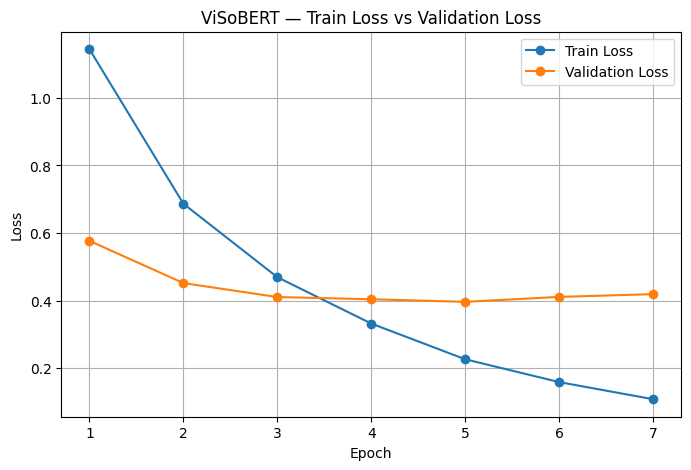

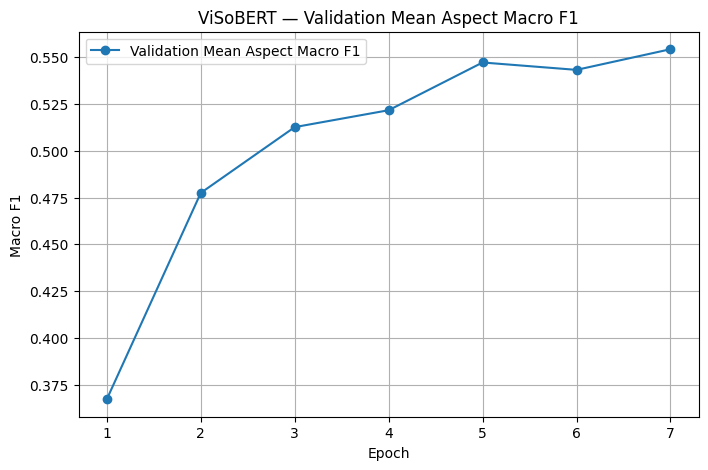

,epoch,validation_loss,validation_mean_macro_f1
0,1.0,0.576808,0.367172
1,2.0,0.451849,0.477496
2,3.0,0.410585,0.512692
3,4.0,0.403996,0.521728
4,5.0,0.396405,0.547254
5,6.0,0.410970,0.543303
6,7.0,0.419139,0.554345


In [ ]:
# ============================================================
# CELL 62: VẼ LOSS CURVE VÀ MACRO F1 CURVE CHO VISOBERT
# ============================================================

import matplotlib.pyplot as plt

viso_log_history = visobert_final_trainer.state.log_history

viso_train_epochs = []
viso_train_losses = []

viso_val_epochs = []
viso_val_losses = []

viso_val_f1_epochs = []
viso_val_macro_f1s = []

for log in viso_log_history:
    if "loss" in log and "epoch" in log:
        viso_train_epochs.append(log["epoch"])
        viso_train_losses.append(log["loss"])

    if "eval_loss" in log and "epoch" in log:
        viso_val_epochs.append(log["epoch"])
        viso_val_losses.append(log["eval_loss"])

    if "eval_mean_aspect_macro_f1" in log and "epoch" in log:
        viso_val_f1_epochs.append(log["epoch"])
        viso_val_macro_f1s.append(
            log["eval_mean_aspect_macro_f1"]
        )

# ------------------------------------------------------------
# 1. Train Loss vs Validation Loss
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    viso_train_epochs,
    viso_train_losses,
    marker="o",
    label="Train Loss"
)
plt.plot(
    viso_val_epochs,
    viso_val_losses,
    marker="o",
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ViSoBERT — Train Loss vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 2. Validation Macro F1
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    viso_val_f1_epochs,
    viso_val_macro_f1s,
    marker="o",
    label="Validation Mean Aspect Macro F1"
)
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("ViSoBERT — Validation Mean Aspect Macro F1")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 3. Bảng theo epoch
# ------------------------------------------------------------
visobert_training_curve_df = pd.DataFrame({
    "epoch": viso_val_epochs,
    "validation_loss": viso_val_losses,
    "validation_mean_macro_f1": viso_val_macro_f1s
})

display(visobert_training_curve_df)

In [ ]:
# ============================================================
# CELL 63: LƯU ARTIFACTS VISOBERT
# ============================================================

VISOBERT_FINAL_SAVE_DIR = (
    "/content/drive/MyDrive/DACS/"
    "visobert_absa_final_loss_balanced/final_artifacts"
)

os.makedirs(VISOBERT_FINAL_SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------
# 1. Lưu model state
# ------------------------------------------------------------
VISOBERT_MODEL_PATH = os.path.join(
    VISOBERT_FINAL_SAVE_DIR,
    "visobert_absa_multiaspect_loss_balanced.pt"
)

torch.save(
    {
        "model_state_dict": visobert_final_trainer.model.state_dict(),
        "model_name": VISOBERT_MODEL_NAME,
        "num_aspects": NUM_ASPECTS,
        "num_classes": NUM_CLASSES,
        "aspects": ASPECTS,
        "id2label": ID2LABEL,
        "max_length": VISOBERT_MAX_LENGTH,
        "best_hyperparameters": visobert_best_params,
        "class_weights": visobert_best_class_weights.cpu().numpy().tolist(),
        "selection_policy": {
            "hpo_objective": "macro_f1 - 0.25 * eval_loss",
            "final_checkpoint_metric": "eval_loss"
        }
    },
    VISOBERT_MODEL_PATH
)

# ------------------------------------------------------------
# 2. Lưu best hyperparameters
# ------------------------------------------------------------
VISOBERT_BEST_PARAMS_PATH = os.path.join(
    VISOBERT_FINAL_SAVE_DIR,
    "visobert_best_hyperparameters_loss_balanced.json"
)

with open(
    VISOBERT_BEST_PARAMS_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        visobert_best_params,
        f,
        ensure_ascii=False,
        indent=2
    )

# ------------------------------------------------------------
# 3. Lưu metrics
# ------------------------------------------------------------
VISOBERT_METRICS_PATH = os.path.join(
    VISOBERT_FINAL_SAVE_DIR,
    "visobert_final_metrics_loss_balanced.json"
)

with open(
    VISOBERT_METRICS_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        {
            "validation_metrics": visobert_validation_metrics,
            "test_metrics": visobert_test_metrics
        },
        f,
        ensure_ascii=False,
        indent=2
    )

# ------------------------------------------------------------
# 4. Lưu trainer log history
# ------------------------------------------------------------
VISOBERT_LOG_HISTORY_PATH = os.path.join(
    VISOBERT_FINAL_SAVE_DIR,
    "visobert_trainer_log_history_loss_balanced.json"
)

with open(
    VISOBERT_LOG_HISTORY_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        visobert_final_trainer.state.log_history,
        f,
        ensure_ascii=False,
        indent=2
    )

print("✅ Đã lưu artifacts ViSoBERT:")
print(VISOBERT_MODEL_PATH)
print(VISOBERT_BEST_PARAMS_PATH)
print(VISOBERT_METRICS_PATH)
print(VISOBERT_LOG_HISTORY_PATH)

✅ Đã lưu artifacts ViSoBERT:
/content/drive/MyDrive/DACS/visobert_absa_final_loss_balanced/final_artifacts/visobert_absa_multiaspect_loss_balanced.pt
/content/drive/MyDrive/DACS/visobert_absa_final_loss_balanced/final_artifacts/visobert_best_hyperparameters_loss_balanced.json
/content/drive/MyDrive/DACS/visobert_absa_final_loss_balanced/final_artifacts/visobert_final_metrics_loss_balanced.json
/content/drive/MyDrive/DACS/visobert_absa_final_loss_balanced/final_artifacts/visobert_trainer_log_history_loss_balanced.json


# Đánh giá ViSoBERT trên tập test

In [ ]:
# ============================================================
# CELL 64: PREDICT VISOBERT TRÊN TEST SET
# ============================================================

import numpy as np
import pandas as pd

# 1. Chạy dự đoán
visobert_test_prediction_output = visobert_final_trainer.predict(
    tokenized_visobert_datasets["test"]
)

# 2. Lấy logits và labels thật
visobert_test_logits = visobert_test_prediction_output.predictions
visobert_test_labels = visobert_test_prediction_output.label_ids

# 3. Logits -> label id dự đoán
visobert_test_preds = np.argmax(
    visobert_test_logits,
    axis=-1
)

print("✅ Predict test set cho ViSoBERT hoàn tất")
print("visobert_test_logits shape:", visobert_test_logits.shape)
print("visobert_test_labels shape:", visobert_test_labels.shape)
print("visobert_test_preds shape:", visobert_test_preds.shape)

✅ Predict test set cho ViSoBERT hoàn tất
visobert_test_logits shape: (768, 6, 5)
visobert_test_labels shape: (768, 6)
visobert_test_preds shape: (768, 6)


In [ ]:
# ============================================================
# CELL 65: TEST METRICS TỔNG QUÁT + THEO ASPECT CHO VISOBERT
# ============================================================

from sklearn.metrics import f1_score, accuracy_score

ASPECTS = [
    "HOTEL",
    "LOCATION",
    "ROOMS",
    "FACILITIES",
    "FOOD&DRINKS",
    "SERVICE"
]

ID2LABEL = {
    0: "NONE",
    1: "POSITIVE",
    2: "NEGATIVE",
    3: "NEUTRAL",
    4: "CONFLICT"
}

NUM_CLASSES = len(ID2LABEL)

visobert_aspect_summary_rows = []

for aspect_idx, aspect in enumerate(ASPECTS):
    y_true = visobert_test_labels[:, aspect_idx]
    y_pred = visobert_test_preds[:, aspect_idx]

    macro_f1 = f1_score(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        average="weighted",
        zero_division=0
    )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    visobert_aspect_summary_rows.append({
        "aspect": aspect,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    })

visobert_aspect_summary_df = pd.DataFrame(
    visobert_aspect_summary_rows
)

visobert_mean_aspect_macro_f1 = (
    visobert_aspect_summary_df["macro_f1"].mean()
)

visobert_mean_aspect_accuracy = (
    visobert_aspect_summary_df["accuracy"].mean()
)

visobert_mean_aspect_weighted_f1 = (
    visobert_aspect_summary_df["weighted_f1"].mean()
)

visobert_exact_match = np.mean(
    np.all(
        visobert_test_preds == visobert_test_labels,
        axis=1
    )
)

print("===== VISOBERT — TEST SET OVERALL METRICS =====")
print(f"Mean Aspect Accuracy   : {visobert_mean_aspect_accuracy:.4f}")
print(f"Mean Aspect Macro F1   : {visobert_mean_aspect_macro_f1:.4f}")
print(f"Mean Aspect Weighted F1: {visobert_mean_aspect_weighted_f1:.4f}")
print(f"Exact Match            : {visobert_exact_match:.4f}")

print("\n===== VISOBERT — TEST METRICS THEO TỪNG ASPECT =====")
display(
    visobert_aspect_summary_df
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

===== VISOBERT — TEST SET OVERALL METRICS =====
Mean Aspect Accuracy   : 0.9086
Mean Aspect Macro F1   : 0.5911
Mean Aspect Weighted F1: 0.9106
Exact Match            : 0.6289

===== VISOBERT — TEST METRICS THEO TỪNG ASPECT =====


,aspect,accuracy,macro_f1,weighted_f1
0,FOOD&DRINKS,0.955729,0.663246,0.955723
1,HOTEL,0.830729,0.658532,0.836383
2,SERVICE,0.893229,0.643089,0.898480
3,ROOMS,0.884115,0.637995,0.887261
4,LOCATION,0.966146,0.533888,0.964723
5,FACILITIES,0.921875,0.409553,0.920759


In [ ]:
# ============================================================
# CELL 66: CLASSIFICATION REPORT TỪNG ASPECT — VISOBERT
# ============================================================

from sklearn.metrics import classification_report

visobert_classification_reports = {}

LABEL_NAMES = [ID2LABEL[i] for i in range(NUM_CLASSES)]

for aspect_idx, aspect in enumerate(ASPECTS):
    y_true = visobert_test_labels[:, aspect_idx]
    y_pred = visobert_test_preds[:, aspect_idx]

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        target_names=LABEL_NAMES,
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report_dict).transpose()

    visobert_classification_reports[aspect] = report_df

    print("=" * 100)
    print(f"VISOBERT — CLASSIFICATION REPORT — {aspect}")
    display(report_df.round(4))

VISOBERT — CLASSIFICATION REPORT — HOTEL


,precision,recall,f1-score,support
NONE,0.8848,0.8207,0.8515,290.0000
POSITIVE,0.9167,0.8746,0.8951,327.0000
NEGATIVE,0.7021,0.8390,0.7645,118.0000
NEUTRAL,0.3103,0.4091,0.3529,22.0000
CONFLICT,0.3529,0.5455,0.4286,11.0000
accuracy,0.8307,0.8307,0.8307,0.8307
macro avg,0.6334,0.6978,0.6585,768.0000
weighted avg,0.8462,0.8307,0.8364,768.0000


VISOBERT — CLASSIFICATION REPORT — LOCATION


,precision,recall,f1-score,support
NONE,0.9872,0.9816,0.9844,706.0000
POSITIVE,0.7541,0.9020,0.8214,51.0000
NEGATIVE,0.5000,0.2857,0.3636,7.0000
NEUTRAL,0.0000,0.0000,0.0000,1.0000
CONFLICT,1.0000,0.3333,0.5000,3.0000
accuracy,0.9661,0.9661,0.9661,0.9661
macro avg,0.6483,0.5005,0.5339,768.0000
weighted avg,0.9660,0.9661,0.9647,768.0000


VISOBERT — CLASSIFICATION REPORT — ROOMS


...

,precision,recall,f1-score,support
NONE,0.9632,0.9592,0.9612,710.0000
POSITIVE,0.2273,0.2500,0.2381,20.0000
NEGATIVE,0.6000,0.7500,0.6667,28.0000
NEUTRAL,0.2500,0.1429,0.1818,7.0000
CONFLICT,0.0000,0.0000,0.0000,3.0000
accuracy,0.9219,0.9219,0.9219,0.9219
macro avg,0.4081,0.4204,0.4096,768.0000
weighted avg,0.9206,0.9219,0.9208,768.0000


VISOBERT — CLASSIFICATION REPORT — FOOD&DRINKS


,precision,recall,f1-score,support
NONE,0.9886,0.9858,0.9872,703.0000
POSITIVE,0.5161,0.7273,0.6038,22.0000
NEGATIVE,0.6923,0.6923,0.6923,26.0000
NEUTRAL,0.7500,0.3333,0.4615,9.0000
CONFLICT,0.6667,0.5000,0.5714,8.0000
accuracy,0.9557,0.9557,0.9557,0.9557
macro avg,0.7227,0.6477,0.6632,768.0000
weighted avg,0.9589,0.9557,0.9557,768.0000


VISOBERT — CLASSIFICATION REPORT — SERVICE


,precision,recall,f1-score,support
NONE,0.9705,0.9264,0.9480,639.0000
POSITIVE,0.6757,0.8065,0.7353,62.0000
NEGATIVE,0.5217,0.6792,0.5902,53.0000
NEUTRAL,0.5385,0.7000,0.6087,10.0000
CONFLICT,0.5000,0.2500,0.3333,4.0000
accuracy,0.8932,0.8932,0.8932,0.8932
macro avg,0.6413,0.6724,0.6431,768.0000
weighted avg,0.9076,0.8932,0.8985,768.0000


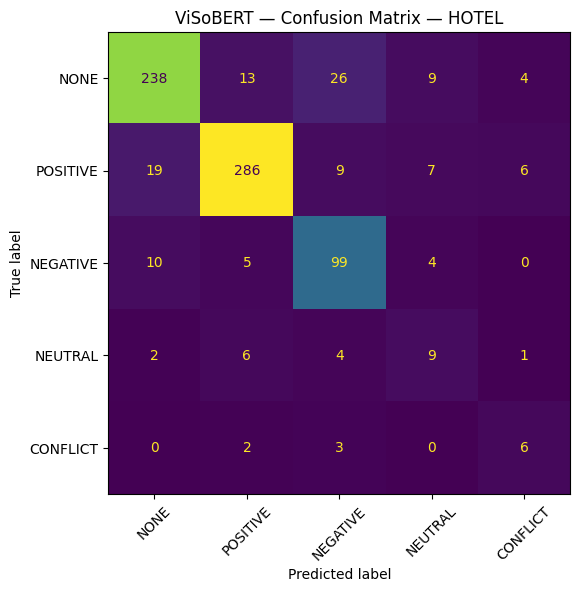

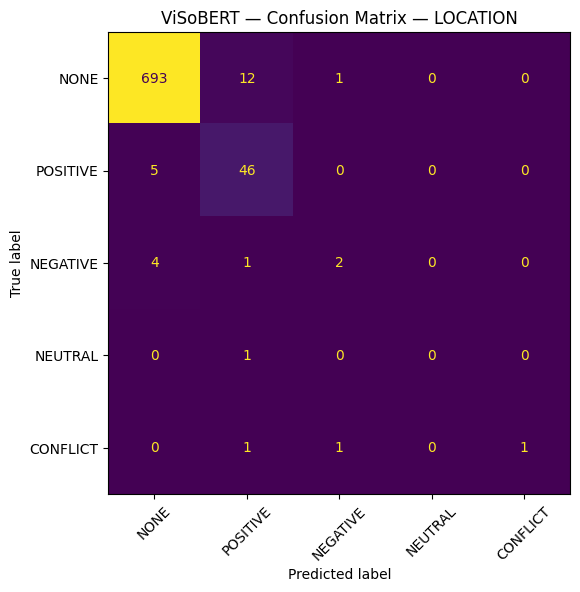

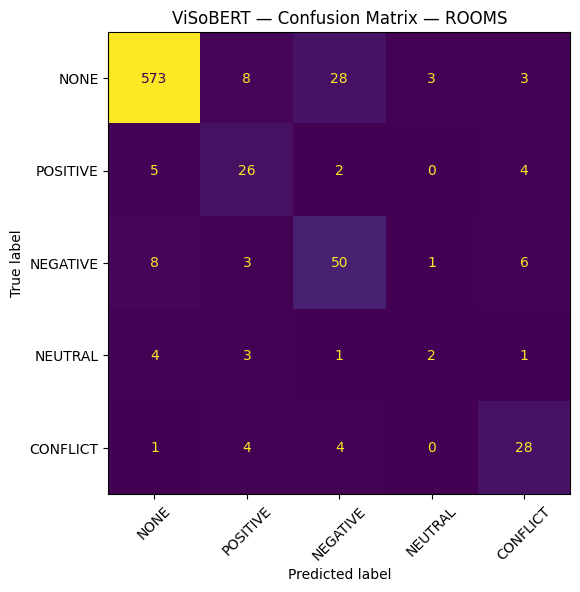

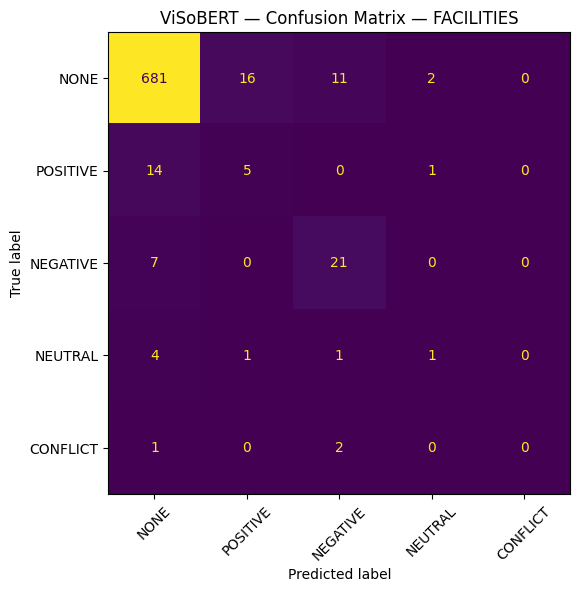

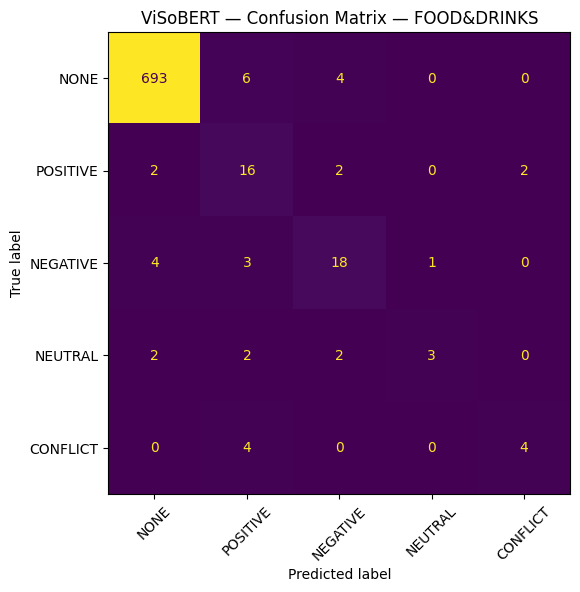

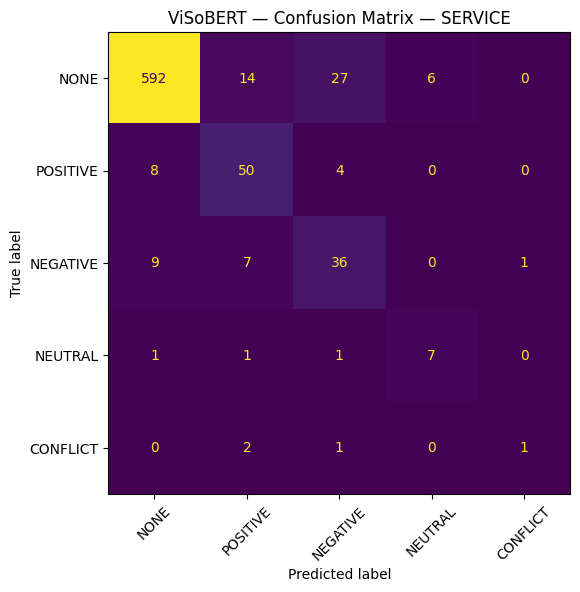

In [ ]:
# ============================================================
# CELL 67: CONFUSION MATRIX TỪNG ASPECT — VISOBERT
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for aspect_idx, aspect in enumerate(ASPECTS):
    y_true = visobert_test_labels[:, aspect_idx]
    y_pred = visobert_test_preds[:, aspect_idx]

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES))
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=LABEL_NAMES
    )

    plt.figure(figsize=(7, 6))
    disp.plot(
        values_format="d",
        ax=plt.gca(),
        colorbar=False
    )
    plt.title(f"ViSoBERT — Confusion Matrix — {aspect}")
    plt.xticks(rotation=45)
    plt.grid(False)
    plt.show()

In [ ]:
# ============================================================
# CELL 68: TẠO BẢNG PREDICTION DETAIL + LƯU EVALUATION VISOBERT
# ============================================================

import os
import json

# ------------------------------------------------------------
# 1. Load lại test.csv để lấy text gốc
# ------------------------------------------------------------
TEST_CSV_PATH = "/content/drive/MyDrive/DACS/absa_splits/test.csv"

visobert_test_raw_df = pd.read_csv(
    TEST_CSV_PATH
).reset_index(drop=True)

if len(visobert_test_raw_df) != len(visobert_test_preds):
    raise ValueError(
        f"Số dòng test.csv ({len(visobert_test_raw_df)}) "
        f"khác số prediction ({len(visobert_test_preds)})"
    )

# ------------------------------------------------------------
# 2. Hàm decode vector label -> chuỗi dễ đọc
# ------------------------------------------------------------
def decode_label_row_for_visobert(label_row):
    pairs = []

    for aspect_idx, label_id in enumerate(label_row):
        label_name = ID2LABEL[int(label_id)]

        if label_name != "NONE":
            pairs.append(
                f"{ASPECTS[aspect_idx]}:{label_name}"
            )

    return "; ".join(pairs) if pairs else "NONE"

# ------------------------------------------------------------
# 3. Tạo bảng kết quả chi tiết
# ------------------------------------------------------------
visobert_test_result_df = visobert_test_raw_df[
    [
        "review_index",
        "unit_id",
        "unit_text_step2",
        "text_model_input",
        "FINAL_REVIEWED_SENTIMENTS"
    ]
].copy()

visobert_test_result_df["ground_truth_decoded"] = [
    decode_label_row_for_visobert(row)
    for row in visobert_test_labels
]

visobert_test_result_df["prediction_decoded"] = [
    decode_label_row_for_visobert(row)
    for row in visobert_test_preds
]

visobert_test_result_df["exact_match"] = np.all(
    visobert_test_preds == visobert_test_labels,
    axis=1
)

visobert_test_result_df["num_wrong_aspects"] = (
    visobert_test_preds != visobert_test_labels
).sum(axis=1)

print("✅ Đã tạo bảng prediction detail cho ViSoBERT")
print("Số dòng test:", len(visobert_test_result_df))
print("Exact match:", round(
    visobert_test_result_df["exact_match"].mean(),
    4
))

display(
    visobert_test_result_df.head(20)
)

# ------------------------------------------------------------
# 4. Xem nhanh các lỗi nặng nhất
# ------------------------------------------------------------
print("\n===== VISOBERT — MẪU DỰ ĐOÁN SAI NHIỀU NHẤT =====")
display(
    visobert_test_result_df[
        visobert_test_result_df["exact_match"] == False
    ][
        [
            "unit_text_step2",
            "ground_truth_decoded",
            "prediction_decoded",
            "num_wrong_aspects"
        ]
    ]
    .sort_values("num_wrong_aspects", ascending=False)
    .head(30)
)

# ------------------------------------------------------------
# 5. Lưu kết quả evaluation
# ------------------------------------------------------------
VISOBERT_EVAL_DIR = (
    "/content/drive/MyDrive/DACS/"
    "visobert_absa_final_loss_balanced/test_evaluation"
)

os.makedirs(VISOBERT_EVAL_DIR, exist_ok=True)

# Metric theo aspect
visobert_aspect_summary_df.to_csv(
    os.path.join(
        VISOBERT_EVAL_DIR,
        "visobert_test_aspect_summary_metrics.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

# Classification reports
for aspect, report_df in visobert_classification_reports.items():
    report_df.to_csv(
        os.path.join(
            VISOBERT_EVAL_DIR,
            f"visobert_classification_report_{aspect}.csv"
        ),
        encoding="utf-8-sig"
    )

# Prediction detail
visobert_test_result_df.to_csv(
    os.path.join(
        VISOBERT_EVAL_DIR,
        "visobert_test_predictions_detail.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

# Overall metrics
visobert_overall_metrics = {
    "mean_aspect_accuracy": float(
        visobert_mean_aspect_accuracy
    ),
    "mean_aspect_macro_f1": float(
        visobert_mean_aspect_macro_f1
    ),
    "mean_aspect_weighted_f1": float(
        visobert_mean_aspect_weighted_f1
    ),
    "exact_match": float(
        visobert_exact_match
    )
}

with open(
    os.path.join(
        VISOBERT_EVAL_DIR,
        "visobert_test_overall_metrics.json"
    ),
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        visobert_overall_metrics,
        f,
        ensure_ascii=False,
        indent=2
    )

print("\n✅ Đã lưu toàn bộ kết quả đánh giá ViSoBERT tại:")
print(VISOBERT_EVAL_DIR)

✅ Đã tạo bảng prediction detail cho ViSoBERT
Số dòng test: 768
Exact match: 0.6289


,review_index,unit_id,unit_text_step2,text_model_input,FINAL_REVIEWED_SENTIMENTS,ground_truth_decoded,prediction_decoded,exact_match,num_wrong_aspects
0,861,2,"gym nhỏ, hồ_bơi đẹp nhưng không sạch","gym nhỏ , hồ_bơi đẹp nhưng không sạch",FACILITIES:CONFLICT,FACILITIES:CONFLICT,ROOMS:CONFLICT; FACILITIES:NEGATIVE,False,2
1,4121,1,phòng ốc tiện nghi và rộng sạch nhân viên lịch...,phòng_ốc tiện_nghi và rộng sạch nhân_viên lịch...,FACILITIES:CONFLICT; FOOD&DRINKS:CONFLICT; ROO...,ROOMS:POSITIVE; FACILITIES:CONFLICT; FOOD&DRIN...,ROOMS:POSITIVE; FOOD&DRINKS:CONFLICT; SERVICE:...,False,1
2,7496,3,"bữa_sáng ổn, hồ_bơi hơi quá nhỏ, thái độ nhân ...","bữa_sáng ổn , hồ_bơi hơi quá nhỏ , thái_độ nhâ...",FACILITIES:NEGATIVE; FOOD&DRINKS:POSITIVE; ROO...,ROOMS:POSITIVE; FACILITIES:NEGATIVE; FOOD&DRIN...,ROOMS:CONFLICT; FACILITIES:NEGATIVE; FOOD&DRIN...,False,1
3,2631,2,"Tuy nhiên, mọi người nên lưu ý, nếu có đi xe v...","Tuy_nhiên , mọi người nên lưu_ý , nếu có đi xe...",FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,SERVICE:NEGATIVE,False,2
4,3481,3,"thang máy cũng không khá chậm, và cũ","thang_máy cũng không khá chậm , và cũ",FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,True,0
5,5784,2,nhưng về phần bãi đổ xe thì y như lừa đảo,nhưng về phần bãi đổ xe thì y_như lừa_đảo,FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,HOTEL:NEGATIVE; FACILITIES:NEGATIVE,False,1
6,5784,4,khách sạn này ở trong mục đã chọn nhưng không có,khách_sạn này ở trong mục đã chọn nhưng không có,FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,HOTEL:NEGATIVE; ROOMS:NEGATIVE,False,3
7,8535,4,"muốn bơi phải quay về phòng lấy tiền, chạy xuố...","muốn bơi phải quay về phòng lấy tiền , chạy xu...",FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,True,0
8,9464,1,"Không có chỗ để xe máy, phải trả thêm phí gửi ...","Không có chỗ để xe_máy , phải trả thêm phí gửi...",FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,FACILITIES:NEGATIVE; SERVICE:NEGATIVE,False,1
9,11395,3,khách phải đi gửi xe hết 150k,khách phải đi gửi xe hết 150k,FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,True,0



===== VISOBERT — MẪU DỰ ĐOÁN SAI NHIỀU NHẤT =====


,unit_text_step2,ground_truth_decoded,prediction_decoded,num_wrong_aspects
382,"khách sạn sạch , tầng 1 có siêu thị , phòng ng...",HOTEL:POSITIVE; ROOMS:NEGATIVE; FACILITIES:NEU...,LOCATION:POSITIVE; ROOMS:CONFLICT,4
741,nếu không phải sạch sẽ và bữa_sáng chỉn chu th...,HOTEL:NEGATIVE; ROOMS:POSITIVE; FOOD&DRINKS:PO...,FOOD&DRINKS:NEGATIVE; SERVICE:NEGATIVE,4
425,"check in lâu , lối vào hẹp , toilet sạch , nội...",LOCATION:NEGATIVE; ROOMS:POSITIVE; SERVICE:CON...,ROOMS:POSITIVE; FACILITIES:POSITIVE; FOOD&DRIN...,4
24,"ngay trung tâm, đi bộ ra phố đi bộ nguyễn huệ ...",HOTEL:POSITIVE; LOCATION:POSITIVE; ROOMS:CONFL...,HOTEL:POSITIVE; LOCATION:POSITIVE; ROOMS:POSIT...,4
722,"Trong khi đó, đi chung đoàn, có bạn đặt phòng ...",ROOMS:NEUTRAL,FACILITIES:NEUTRAL; SERVICE:NEUTRAL,3
449,"nhân viên khu lễ tân, khu phục vụ bữa_sáng và ...",SERVICE:POSITIVE,LOCATION:POSITIVE; FACILITIES:POSITIVE; FOOD&D...,3
712,nhân viên thân thiện nhưng chuẩn bị phòng còn ...,ROOMS:NEGATIVE; SERVICE:CONFLICT,FOOD&DRINKS:NEGATIVE; SERVICE:NEGATIVE,3
734,"khách sạn lâu đời tại quận 1, trang thiết bị t...",ROOMS:POSITIVE,HOTEL:POSITIVE; LOCATION:POSITIVE,3
640,"địa điểm trung tâm, khách sạn sạch, thủ tục nh...",HOTEL:POSITIVE; LOCATION:POSITIVE; FOOD&DRINKS...,LOCATION:POSITIVE; FOOD&DRINKS:NEUTRAL,3
440,mỗi tối khách sạn đều gửi socola cho từng phòng,SERVICE:POSITIVE,HOTEL:NEGATIVE; ROOMS:NEGATIVE; SERVICE:NEGATIVE,3



✅ Đã lưu toàn bộ kết quả đánh giá ViSoBERT tại:
/content/drive/MyDrive/DACS/visobert_absa_final_loss_balanced/test_evaluation


# Trực quan hóa và so sánh PhoBERT vs ViSoBERT

In [ ]:
# ============================================================
# CELL 68.5: LOAD LẠI KẾT QUẢ ĐÁNH GIÁ PHOBERT TỪ DRIVE
# ============================================================

import os
import json
import pandas as pd

# ------------------------------------------------------------
# 1. Khai báo thư mục evaluation PhoBERT đã lưu trước đó
# ------------------------------------------------------------
PHOBERT_EVAL_DIR = (
    "/content/drive/MyDrive/DACS/"
    "phobert_absa_final_loss_balanced/test_evaluation"
)

PHOBERT_OVERALL_METRICS_PATH = os.path.join(
    PHOBERT_EVAL_DIR,
    "test_overall_metrics.json"
)

PHOBERT_ASPECT_METRICS_PATH = os.path.join(
    PHOBERT_EVAL_DIR,
    "test_aspect_summary_metrics.csv"
)

PHOBERT_PREDICTIONS_PATH = os.path.join(
    PHOBERT_EVAL_DIR,
    "test_predictions_detail.csv"
)

# ------------------------------------------------------------
# 2. Kiểm tra file tồn tại
# ------------------------------------------------------------
required_paths = [
    PHOBERT_OVERALL_METRICS_PATH,
    PHOBERT_ASPECT_METRICS_PATH,
    PHOBERT_PREDICTIONS_PATH
]

for path in required_paths:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Không tìm thấy file PhoBERT: {path}")

# ------------------------------------------------------------
# 3. Load overall metrics PhoBERT
# ------------------------------------------------------------
with open(
    PHOBERT_OVERALL_METRICS_PATH,
    "r",
    encoding="utf-8"
) as f:
    phobert_overall_metrics = json.load(f)

# ------------------------------------------------------------
# 4. Load bảng metric theo aspect PhoBERT
#    Đặt đúng tên biến cũ để Cell 71 chạy lại được
# ------------------------------------------------------------
aspect_summary_df = pd.read_csv(
    PHOBERT_ASPECT_METRICS_PATH
)

# ------------------------------------------------------------
# 5. Load bảng prediction detail PhoBERT
#    Đặt đúng tên biến cũ để Cell 73 chạy lại được
# ------------------------------------------------------------
test_result_df = pd.read_csv(
    PHOBERT_PREDICTIONS_PATH
)

# ------------------------------------------------------------
# 6. Gán lại các biến metric chính của PhoBERT
# ------------------------------------------------------------
phobert_mean_aspect_accuracy = phobert_overall_metrics[
    "mean_aspect_accuracy"
]

phobert_mean_aspect_macro_f1 = phobert_overall_metrics[
    "mean_aspect_macro_f1"
]

phobert_mean_aspect_weighted_f1 = phobert_overall_metrics[
    "mean_aspect_weighted_f1"
]

phobert_exact_match = phobert_overall_metrics[
    "exact_match"
]

# ------------------------------------------------------------
# 7. Hiển thị để kiểm tra
# ------------------------------------------------------------
print("✅ Đã load lại kết quả PhoBERT từ Drive")

print("\nPhoBERT overall metrics:")
print(f"Mean Aspect Accuracy   : {phobert_mean_aspect_accuracy:.4f}")
print(f"Mean Aspect Macro F1   : {phobert_mean_aspect_macro_f1:.4f}")
print(f"Mean Aspect Weighted F1: {phobert_mean_aspect_weighted_f1:.4f}")
print(f"Exact Match            : {phobert_exact_match:.4f}")

print("\nPhoBERT aspect summary:")
display(aspect_summary_df)

print("\nPhoBERT prediction detail:")
display(test_result_df.head(10))

✅ Đã load lại kết quả PhoBERT từ Drive

PhoBERT overall metrics:
Mean Aspect Accuracy   : 0.9295
Mean Aspect Macro F1   : 0.6517
Mean Aspect Weighted F1: 0.9322
Exact Match            : 0.7096

PhoBERT aspect summary:


,aspect,accuracy,macro_f1,weighted_f1
0,HOTEL,0.881510,0.728488,0.884237
1,LOCATION,0.972656,0.512027,0.971765
2,ROOMS,0.895833,0.705068,0.902710
3,FACILITIES,0.934896,0.515697,0.938147
4,FOOD&DRINKS,0.966146,0.757479,0.968192
5,SERVICE,0.925781,0.691353,0.928406



PhoBERT prediction detail:


,review_index,unit_id,unit_text_step2,text_model_input,FINAL_REVIEWED_SENTIMENTS,ground_truth_decoded,prediction_decoded,exact_match,num_wrong_aspects
0,861,2,"gym nhỏ, hồ_bơi đẹp nhưng không sạch","gym nhỏ , hồ_bơi đẹp nhưng không sạch",FACILITIES:CONFLICT,FACILITIES:CONFLICT,ROOMS:CONFLICT; FACILITIES:NEGATIVE,False,2
1,4121,1,phòng ốc tiện nghi và rộng sạch nhân viên lịch...,phòng_ốc tiện_nghi và rộng sạch nhân_viên lịch...,FACILITIES:CONFLICT; FOOD&DRINKS:CONFLICT; ROO...,ROOMS:POSITIVE; FACILITIES:CONFLICT; FOOD&DRIN...,ROOMS:POSITIVE; FACILITIES:POSITIVE; FOOD&DRIN...,False,2
2,7496,3,"bữa_sáng ổn, hồ_bơi hơi quá nhỏ, thái độ nhân ...","bữa_sáng ổn , hồ_bơi hơi quá nhỏ , thái_độ nhâ...",FACILITIES:NEGATIVE; FOOD&DRINKS:POSITIVE; ROO...,ROOMS:POSITIVE; FACILITIES:NEGATIVE; FOOD&DRIN...,LOCATION:POSITIVE; ROOMS:CONFLICT; FACILITIES:...,False,2
3,2631,2,"Tuy nhiên, mọi người nên lưu ý, nếu có đi xe v...","Tuy_nhiên , mọi người nên lưu_ý , nếu có đi xe...",FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,FACILITIES:NEUTRAL,False,1
4,3481,3,"thang máy cũng không khá chậm, và cũ","thang_máy cũng không khá chậm , và cũ",FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,True,0
5,5784,2,nhưng về phần bãi đổ xe thì y như lừa đảo,nhưng về phần bãi đổ xe thì y_như lừa_đảo,FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,FACILITIES:NEGATIVE; SERVICE:NEGATIVE,False,1
6,5784,4,khách sạn này ở trong mục đã chọn nhưng không có,khách_sạn này ở trong mục đã chọn nhưng không có,FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,SERVICE:NEGATIVE,False,2
7,8535,4,"muốn bơi phải quay về phòng lấy tiền, chạy xuố...","muốn bơi phải quay về phòng lấy tiền , chạy xu...",FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,True,0
8,9464,1,"Không có chỗ để xe máy, phải trả thêm phí gửi ...","Không có chỗ để xe_máy , phải trả thêm phí gửi...",FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,True,0
9,11395,3,khách phải đi gửi xe hết 150k,khách phải đi gửi xe hết 150k,FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,True,0


In [ ]:
# ============================================================
# CELL 69: BẢNG SO SÁNH METRIC TỔNG PHOBERT VS VISOBERT
# ============================================================

comparison_overall_df = pd.DataFrame([
    {
        "model": "PhoBERT",
        "mean_aspect_accuracy": phobert_mean_aspect_accuracy,
        "mean_aspect_macro_f1": phobert_mean_aspect_macro_f1,
        "mean_aspect_weighted_f1": phobert_mean_aspect_weighted_f1,
        "exact_match": phobert_exact_match
    },
    {
        "model": "ViSoBERT",
        "mean_aspect_accuracy": visobert_mean_aspect_accuracy,
        "mean_aspect_macro_f1": visobert_mean_aspect_macro_f1,
        "mean_aspect_weighted_f1": visobert_mean_aspect_weighted_f1,
        "exact_match": visobert_exact_match
    }
])

display(comparison_overall_df.round(4))

,model,mean_aspect_accuracy,mean_aspect_macro_f1,mean_aspect_weighted_f1,exact_match
0,PhoBERT,0.9295,0.6517,0.9322,0.7096
1,ViSoBERT,0.9086,0.5911,0.9106,0.6289


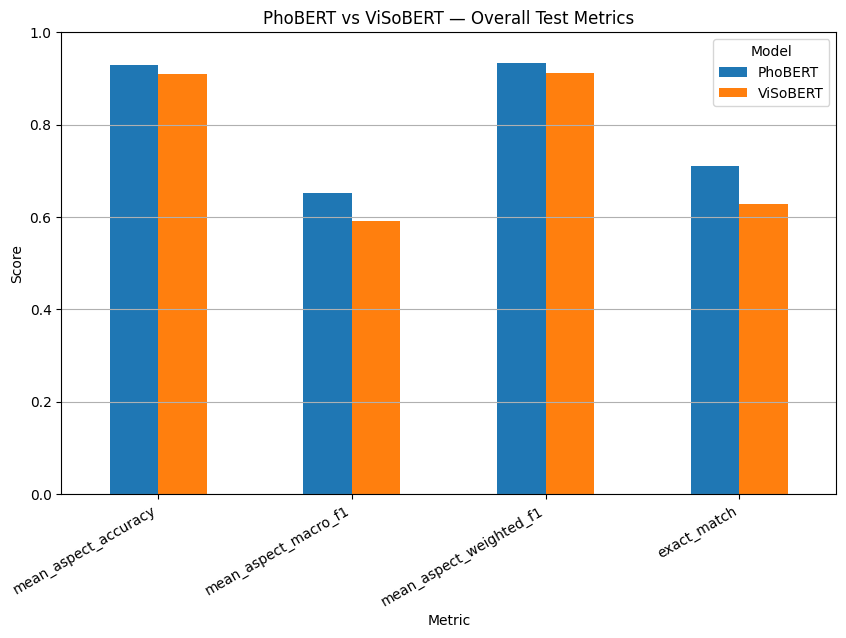

In [ ]:
# ============================================================
# CELL 70: BIỂU ĐỒ SO SÁNH METRIC TỔNG
# ============================================================

import matplotlib.pyplot as plt

metrics_to_plot = [
    "mean_aspect_accuracy",
    "mean_aspect_macro_f1",
    "mean_aspect_weighted_f1",
    "exact_match"
]

plot_df = comparison_overall_df.set_index("model")[metrics_to_plot].T

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("PhoBERT vs ViSoBERT — Overall Test Metrics")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.legend(title="Model")
plt.show()

In [ ]:
# ============================================================
# CELL 71: SO SÁNH MACRO F1 THEO TỪNG ASPECT
# ============================================================

phobert_aspect_compare_df = aspect_summary_df[
    ["aspect", "macro_f1"]
].rename(
    columns={"macro_f1": "PhoBERT_macro_f1"}
)

visobert_aspect_compare_df = visobert_aspect_summary_df[
    ["aspect", "macro_f1"]
].rename(
    columns={"macro_f1": "ViSoBERT_macro_f1"}
)

comparison_aspect_f1_df = phobert_aspect_compare_df.merge(
    visobert_aspect_compare_df,
    on="aspect",
    how="inner"
)

comparison_aspect_f1_df["difference_phobert_minus_visobert"] = (
    comparison_aspect_f1_df["PhoBERT_macro_f1"]
    - comparison_aspect_f1_df["ViSoBERT_macro_f1"]
)

display(
    comparison_aspect_f1_df
    .sort_values("difference_phobert_minus_visobert", ascending=False)
    .reset_index(drop=True)
    .round(4)
)

,aspect,PhoBERT_macro_f1,ViSoBERT_macro_f1,difference_phobert_minus_visobert
0,FACILITIES,0.5157,0.4096,0.1061
1,FOOD&DRINKS,0.7575,0.6632,0.0942
2,HOTEL,0.7285,0.6585,0.0700
3,ROOMS,0.7051,0.6380,0.0671
4,SERVICE,0.6914,0.6431,0.0483
5,LOCATION,0.5120,0.5339,-0.0219


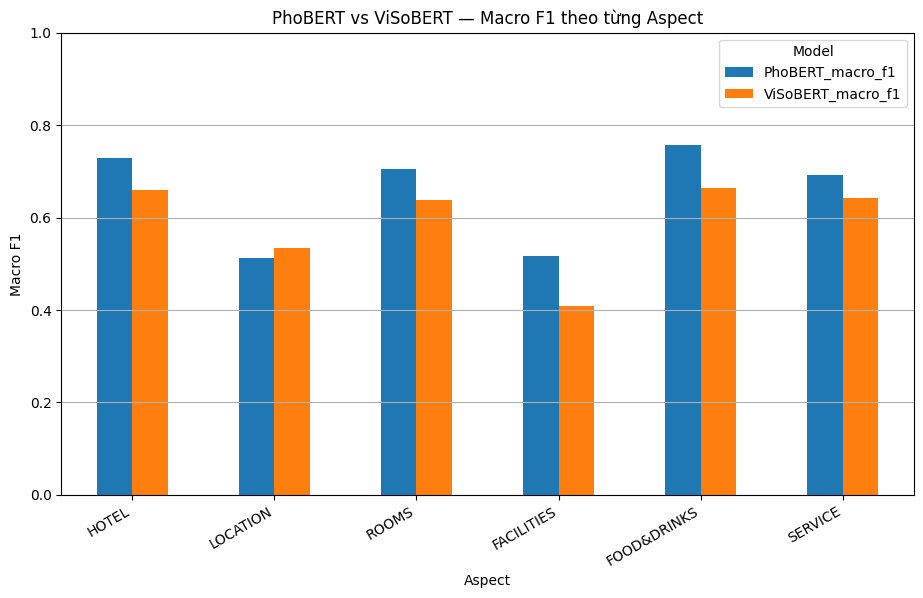

In [ ]:
# ============================================================
# CELL 72: BIỂU ĐỒ SO SÁNH MACRO F1 THEO ASPECT
# ============================================================

aspect_plot_df = comparison_aspect_f1_df.set_index("aspect")[
    ["PhoBERT_macro_f1", "ViSoBERT_macro_f1"]
]

ax = aspect_plot_df.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("PhoBERT vs ViSoBERT — Macro F1 theo từng Aspect")
plt.ylabel("Macro F1")
plt.xlabel("Aspect")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.legend(title="Model")
plt.show()

In [ ]:
# ============================================================
# CELL 73: SO SÁNH CASE STUDY PREDICTION PHOBERT VS VISOBERT
# ============================================================

phobert_compare_cases = test_result_df[
    [
        "review_index",
        "unit_id",
        "unit_text_step2",
        "ground_truth_decoded",
        "prediction_decoded",
        "exact_match"
    ]
].rename(
    columns={
        "prediction_decoded": "phobert_prediction",
        "exact_match": "phobert_exact_match"
    }
)

visobert_compare_cases = visobert_test_result_df[
    [
        "review_index",
        "unit_id",
        "prediction_decoded",
        "exact_match"
    ]
].rename(
    columns={
        "prediction_decoded": "visobert_prediction",
        "exact_match": "visobert_exact_match"
    }
)

model_case_compare_df = phobert_compare_cases.merge(
    visobert_compare_cases,
    on=["review_index", "unit_id"],
    how="inner"
)

# ------------------------------------------------------------
# 1. PhoBERT đúng, ViSoBERT sai
# ------------------------------------------------------------
print("===== PhoBERT đúng, ViSoBERT sai =====")
display(
    model_case_compare_df[
        (model_case_compare_df["phobert_exact_match"] == True)
        & (model_case_compare_df["visobert_exact_match"] == False)
    ][
        [
            "unit_text_step2",
            "ground_truth_decoded",
            "phobert_prediction",
            "visobert_prediction"
        ]
    ].head(20)
)

# ------------------------------------------------------------
# 2. ViSoBERT đúng, PhoBERT sai
# ------------------------------------------------------------
print("\n===== ViSoBERT đúng, PhoBERT sai =====")
display(
    model_case_compare_df[
        (model_case_compare_df["phobert_exact_match"] == False)
        & (model_case_compare_df["visobert_exact_match"] == True)
    ][
        [
            "unit_text_step2",
            "ground_truth_decoded",
            "phobert_prediction",
            "visobert_prediction"
        ]
    ].head(20)
)

# ------------------------------------------------------------
# 3. Cả hai cùng sai
# ------------------------------------------------------------
print("\n===== Cả PhoBERT và ViSoBERT cùng sai =====")
display(
    model_case_compare_df[
        (model_case_compare_df["phobert_exact_match"] == False)
        & (model_case_compare_df["visobert_exact_match"] == False)
    ][
        [
            "unit_text_step2",
            "ground_truth_decoded",
            "phobert_prediction",
            "visobert_prediction"
        ]
    ].head(20)
)

===== PhoBERT đúng, ViSoBERT sai =====


,unit_text_step2,ground_truth_decoded,phobert_prediction,visobert_prediction
8,"Không có chỗ để xe máy, phải trả thêm phí gửi ...",FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,FACILITIES:NEGATIVE; SERVICE:NEGATIVE
10,gửi xe ra vào hơi bất tiện,FACILITIES:NEGATIVE,FACILITIES:NEGATIVE,LOCATION:NEGATIVE; FACILITIES:NEGATIVE
12,tuy nhiên tiện nghi và phục vụ chưa tốt,FACILITIES:NEGATIVE; SERVICE:NEGATIVE,FACILITIES:NEGATIVE; SERVICE:NEGATIVE,ROOMS:NEGATIVE; FACILITIES:NEGATIVE; SERVICE:N...
16,sau đó tôi đi dạo quanh khách sạn và đi bơi ở ...,FACILITIES:NEUTRAL,FACILITIES:NEUTRAL,NONE
25,là 1 trong những khách sạn có hồ_bơi vô cực đẹ...,FACILITIES:POSITIVE; FOOD&DRINKS:NEGATIVE,FACILITIES:POSITIVE; FOOD&DRINKS:NEGATIVE,FACILITIES:POSITIVE; FOOD&DRINKS:POSITIVE
31,"khách sạn có phòng tiện nghi và sạch sẽ, gần t...",LOCATION:POSITIVE; ROOMS:POSITIVE; FACILITIES:...,LOCATION:POSITIVE; ROOMS:POSITIVE; FACILITIES:...,LOCATION:POSITIVE; ROOMS:POSITIVE; SERVICE:POS...
36,"bữa_sáng và đồ_uống khá ngon , tuy không nhiều...",FOOD&DRINKS:CONFLICT,FOOD&DRINKS:CONFLICT,FOOD&DRINKS:POSITIVE
42,bữa_sáng hơi mắc,FOOD&DRINKS:NEGATIVE,FOOD&DRINKS:NEGATIVE,FACILITIES:NEGATIVE; FOOD&DRINKS:NEGATIVE
43,có thể mướn đầu bếp cho các món ăn khá hơn một...,FOOD&DRINKS:NEGATIVE,FOOD&DRINKS:NEGATIVE,ROOMS:POSITIVE; FACILITIES:POSITIVE; FOOD&DRIN...
46,tôi là người đầu tiên đến tiệc trà và là người...,FOOD&DRINKS:NEGATIVE,FOOD&DRINKS:NEGATIVE,SERVICE:NEGATIVE



===== ViSoBERT đúng, PhoBERT sai =====


,unit_text_step2,ground_truth_decoded,phobert_prediction,visobert_prediction
13,"không dùng được hồ_bơi và gym, mặc dù bạn ở ho...",FACILITIES:NEGATIVE; SERVICE:NEGATIVE,FACILITIES:NEGATIVE,FACILITIES:NEGATIVE; SERVICE:NEGATIVE
18,"bể_bơi 1m2, trẻ em dưới 12 tuổi cần có người l...",FACILITIES:NEUTRAL,FACILITIES:NEGATIVE,FACILITIES:NEUTRAL
60,đồ bữa_sáng nhanh hết nhân viên lễ tân không n...,FOOD&DRINKS:NEGATIVE; SERVICE:NEGATIVE,FOOD&DRINKS:NEGATIVE; SERVICE:CONFLICT,FOOD&DRINKS:NEGATIVE; SERVICE:NEGATIVE
77,khách sạn sạch đẹp vị trí đắc địa bữa_sáng ngo...,HOTEL:POSITIVE; LOCATION:POSITIVE; FOOD&DRINKS...,LOCATION:POSITIVE; ROOMS:POSITIVE; FOOD&DRINKS...,HOTEL:POSITIVE; LOCATION:POSITIVE; FOOD&DRINKS...
86,cũng ổn nhưng mà ồn,HOTEL:CONFLICT,HOTEL:CONFLICT; ROOMS:CONFLICT,HOTEL:CONFLICT
97,không tương xứng vs 5 sao 3: tìm nhà ăn như 1 ...,HOTEL:NEGATIVE,HOTEL:NEGATIVE; SERVICE:NEGATIVE,HOTEL:NEGATIVE
103,khách sạn đèn rất tối,HOTEL:NEGATIVE,HOTEL:NEGATIVE; ROOMS:NEGATIVE,HOTEL:NEGATIVE
148,không gian bố trí hơi xấu,HOTEL:NEGATIVE,HOTEL:NEGATIVE; ROOMS:NEGATIVE,HOTEL:NEGATIVE
170,không như trên hình,HOTEL:NEGATIVE,HOTEL:NEGATIVE; ROOMS:NEGATIVE,HOTEL:NEGATIVE
190,nói chung thì khách sạn ở cũng được,HOTEL:NEUTRAL,HOTEL:POSITIVE,HOTEL:NEUTRAL



===== Cả PhoBERT và ViSoBERT cùng sai =====


,unit_text_step2,ground_truth_decoded,phobert_prediction,visobert_prediction
0,"gym nhỏ, hồ_bơi đẹp nhưng không sạch",FACILITIES:CONFLICT,ROOMS:CONFLICT; FACILITIES:NEGATIVE,ROOMS:CONFLICT; FACILITIES:NEGATIVE
1,phòng ốc tiện nghi và rộng sạch nhân viên lịch...,ROOMS:POSITIVE; FACILITIES:CONFLICT; FOOD&DRIN...,ROOMS:POSITIVE; FACILITIES:POSITIVE; FOOD&DRIN...,ROOMS:POSITIVE; FOOD&DRINKS:CONFLICT; SERVICE:...
2,"bữa_sáng ổn, hồ_bơi hơi quá nhỏ, thái độ nhân ...",ROOMS:POSITIVE; FACILITIES:NEGATIVE; FOOD&DRIN...,LOCATION:POSITIVE; ROOMS:CONFLICT; FACILITIES:...,ROOMS:CONFLICT; FACILITIES:NEGATIVE; FOOD&DRIN...
3,"Tuy nhiên, mọi người nên lưu ý, nếu có đi xe v...",FACILITIES:NEGATIVE,FACILITIES:NEUTRAL,SERVICE:NEGATIVE
5,nhưng về phần bãi đổ xe thì y như lừa đảo,FACILITIES:NEGATIVE,FACILITIES:NEGATIVE; SERVICE:NEGATIVE,HOTEL:NEGATIVE; FACILITIES:NEGATIVE
6,khách sạn này ở trong mục đã chọn nhưng không có,FACILITIES:NEGATIVE,SERVICE:NEGATIVE,HOTEL:NEGATIVE; ROOMS:NEGATIVE
11,"vị trí tốt, khách sạn tiện nghi khá cũ",LOCATION:POSITIVE; FACILITIES:NEGATIVE,HOTEL:CONFLICT; LOCATION:POSITIVE; ROOMS:NEGAT...,HOTEL:CONFLICT; LOCATION:POSITIVE; FACILITIES:...
14,"nhà_vệ_sinh tầng_trệt bẩn , thuê 7 phòng 2 đêm...",FACILITIES:NEGATIVE; SERVICE:NEGATIVE,HOTEL:NEGATIVE; ROOMS:NEGATIVE; SERVICE:NEGATIVE,ROOMS:NEGATIVE; FACILITIES:NEGATIVE; SERVICE:N...
15,mặc dù vận dụng loại hình selfin-out nhưng lúc...,FACILITIES:NEGATIVE; SERVICE:NEGATIVE,ROOMS:NEGATIVE; SERVICE:NEGATIVE,ROOMS:NEGATIVE; SERVICE:NEGATIVE
17,nhưng lần này gửi xe 3 ngày đi côn đảo ( có ph...,FACILITIES:NEUTRAL,ROOMS:NEUTRAL; FACILITIES:NEUTRAL,FACILITIES:NEGATIVE; SERVICE:NEGATIVE


In [ ]:
# ============================================================
# CELL 74: LƯU KẾT QUẢ SO SÁNH PHOBERT VS VISOBERT
# ============================================================

COMPARISON_DIR = "/content/drive/MyDrive/DACS/model_comparison"
os.makedirs(COMPARISON_DIR, exist_ok=True)

comparison_overall_df.to_csv(
    os.path.join(COMPARISON_DIR, "overall_metric_comparison.csv"),
    index=False,
    encoding="utf-8-sig"
)

comparison_aspect_f1_df.to_csv(
    os.path.join(COMPARISON_DIR, "aspect_macro_f1_comparison.csv"),
    index=False,
    encoding="utf-8-sig"
)

model_case_compare_df.to_csv(
    os.path.join(COMPARISON_DIR, "prediction_case_comparison.csv"),
    index=False,
    encoding="utf-8-sig"
)

print("✅ Đã lưu kết quả so sánh tại:")
print(COMPARISON_DIR)

✅ Đã lưu kết quả so sánh tại:
/content/drive/MyDrive/DACS/model_comparison
